In [3]:
# ============================================================
# Cell 0 — Empirical TSC benchmark: Hospital contact network
#
# Dataset:
#   SocioPatterns hospital-ward temporal contact network
#
# Raw record format:
#
#   timestamp    node_i    node_j    role_i    role_j
#
# The raw temporal ordering is preserved exactly at this stage.
# No coarse-graining or dynamical model is introduced yet.
# ============================================================

from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# Reproducibility / experiment seeds
#
# These will be used later for:
#   - controlled pairwise coupling weights
#   - initial conditions
#   - shuffled temporal nulls
# ------------------------------------------------------------

SEED_WEIGHTS = 2026081401
SEED_DATA = 2026081402
SEED_SHUFFLE = 2026081403


# ------------------------------------------------------------
# TSC dynamical parameters
#
# Keep the same nonlinear pairwise family used in the
# synthetic benchmarks:
#
#     phi(x) = x + lambda x^2
# ------------------------------------------------------------

LAMBDA_NONLINEAR = 0.5

EPS_VALUES = np.array([
    .005, .0075, .01, .015,
    .02, .03, .04,
    .06, .08, .10, .12
], dtype=float)

RK4_MAX_STEP = 1e-3

In [4]:
# ------------------------------------------------------------
# Data path
#
# Adjust DATA_DIR only if the .dat file is stored elsewhere.
# ------------------------------------------------------------

DATA_DIR = Path(r"C:\Users\liu.xuanc\Desktop\Papers\Dataset\hospital_lyon_contacts")

CONTACT_FILE = (
    DATA_DIR
    / "detailed_list_of_contacts_Hospital.dat"
)

if not CONTACT_FILE.exists():

    # Convenience fallback if the data file is placed next to
    # the notebook rather than inside ./data/
    fallback = Path(
        "./detailed_list_of_contacts_Hospital.dat"
    )

    if fallback.exists():
        CONTACT_FILE = fallback
    else:
        raise FileNotFoundError(
            "Hospital contact file not found. "
            "Expected either:\n"
            "  ./data/detailed_list_of_contacts_Hospital.dat\n"
            "or\n"
            "  ./detailed_list_of_contacts_Hospital.dat"
        )


# ------------------------------------------------------------
# Load raw temporal contacts
# ------------------------------------------------------------

raw_contacts = pd.read_csv(
    CONTACT_FILE,
    sep="\t",
    header=None,
    names=[
        "timestamp",
        "node_i",
        "node_j",
        "role_i",
        "role_j",
    ],
)


# ------------------------------------------------------------
# Type normalization
# ------------------------------------------------------------

raw_contacts["timestamp"] = (
    raw_contacts["timestamp"]
    .astype(np.int64)
)

raw_contacts["node_i"] = (
    raw_contacts["node_i"]
    .astype(np.int64)
)

raw_contacts["node_j"] = (
    raw_contacts["node_j"]
    .astype(np.int64)
)

raw_contacts["role_i"] = (
    raw_contacts["role_i"]
    .astype(str)
)

raw_contacts["role_j"] = (
    raw_contacts["role_j"]
    .astype(str)
)


# ------------------------------------------------------------
# Canonical undirected edge representation
#
# The empirical contacts are dyadic and undirected.
# Store every edge canonically as:
#
#     node_u < node_v
# ------------------------------------------------------------

raw_contacts["node_u"] = np.minimum(
    raw_contacts["node_i"],
    raw_contacts["node_j"],
)

raw_contacts["node_v"] = np.maximum(
    raw_contacts["node_i"],
    raw_contacts["node_j"],
)


# ------------------------------------------------------------
# Basic consistency checks
# ------------------------------------------------------------

assert len(raw_contacts) > 0

assert not raw_contacts[
    [
        "timestamp",
        "node_i",
        "node_j",
        "role_i",
        "role_j",
    ]
].isnull().any().any()

assert np.all(
    raw_contacts["node_i"]
    !=
    raw_contacts["node_j"]
)

assert np.all(
    raw_contacts["node_u"]
    <
    raw_contacts["node_v"]
)


# ------------------------------------------------------------
# Node set and role map
#
# Do not relabel nodes yet.
# Preserve original empirical IDs at the raw-data layer.
# ------------------------------------------------------------

nodes = sorted(
    set(
        raw_contacts["node_i"]
    )
    |
    set(
        raw_contacts["node_j"]
    )
)

node_roles = {}

for row in raw_contacts.itertuples(
    index=False
):

    for node, role in (
        (row.node_i, row.role_i),
        (row.node_j, row.role_j),
    ):

        if node in node_roles:

            assert (
                node_roles[node]
                ==
                role
            ), (
                f"Inconsistent role label "
                f"for node {node}: "
                f"{node_roles[node]} vs {role}"
            )

        else:

            node_roles[node] = role


# ------------------------------------------------------------
# Raw temporal summary
# ------------------------------------------------------------

timestamps = np.sort(
    raw_contacts[
        "timestamp"
    ].unique()
)

raw_edges = set(
    zip(
        raw_contacts["node_u"],
        raw_contacts["node_v"],
    )
)

role_counts = Counter(
    node_roles.values()
)


print(
    "Hospital temporal contact dataset loaded."
)

print(
    "  file =",
    CONTACT_FILE.resolve()
)

print(
    "  contact records =",
    len(raw_contacts)
)

print(
    "  nodes =",
    len(nodes)
)

print(
    "  unique aggregated edges =",
    len(raw_edges)
)

print(
    "  unique timestamps =",
    len(timestamps)
)

print(
    "  first timestamp =",
    int(timestamps[0])
)

print(
    "  last timestamp =",
    int(timestamps[-1])
)

print(
    "  raw time span [s] =",
    int(
        timestamps[-1]
        -
        timestamps[0]
    )
)

print(
    "  node roles =",
    dict(
        sorted(
            role_counts.items()
        )
    )
)

print()

print(
    "Raw contact table:"
)

display(
    raw_contacts.head(10)
)

Hospital temporal contact dataset loaded.
  file = C:\Users\liu.xuanc\Desktop\Papers\Dataset\hospital_lyon_contacts\detailed_list_of_contacts_Hospital.dat
  contact records = 32424
  nodes = 75
  unique aggregated edges = 1139
  unique timestamps = 9453
  first timestamp = 140
  last timestamp = 347640
  raw time span [s] = 347500
  node roles = {'ADM': 8, 'MED': 11, 'NUR': 27, 'PAT': 29}

Raw contact table:


,timestamp,node_i,node_j,role_i,role_j,node_u,node_v
0,140,1157,1232,MED,ADM,1157,1232
1,160,1157,1191,MED,MED,1157,1191
2,500,1157,1159,MED,MED,1157,1159
3,520,1157,1159,MED,MED,1157,1159
4,560,1159,1191,MED,MED,1159,1191
5,580,1159,1191,MED,MED,1159,1191
6,600,1159,1191,MED,MED,1159,1191
7,620,1159,1191,MED,MED,1159,1191
8,680,1159,1191,MED,MED,1159,1191
9,680,1144,1159,MED,MED,1144,1159


Aggregated hospital network
---------------------------
N = 75
|E| = 1139
connected = True
mean degree = 30.373333333333335
degree range = (np.int64(6), np.int64(61))
density = 0.4104504504504505
average clustering = 0.6402796539914468
average shortest path length = 1.597837837837838

Raw temporal activity
---------------------
observed non-empty timestamps = 9453
full 20-s bins over data span = 17376
empty 20-s bins = 7923
fraction non-empty = 0.5440262430939227

edges / observed snapshot:
count    9453.000000
mean        3.430022
std         2.427993
min         1.000000
25%         1.000000
50%         3.000000
75%         5.000000
max        20.000000
Name: n_edges, dtype: float64

active nodes / observed snapshot:
count    9453.000000
mean        5.357558
std         3.108141
min         2.000000
25%         2.000000
50%         5.000000
75%         7.000000
max        20.000000
Name: n_active_nodes, dtype: float64

internal edge overlaps / observed snapshot:
count    9453.000000


,ADM,MED,NUR,PAT
ADM,279,459,2596,441
MED,459,5660,1769,1471
NUR,2596,1769,12695,6845
PAT,441,1471,6845,209


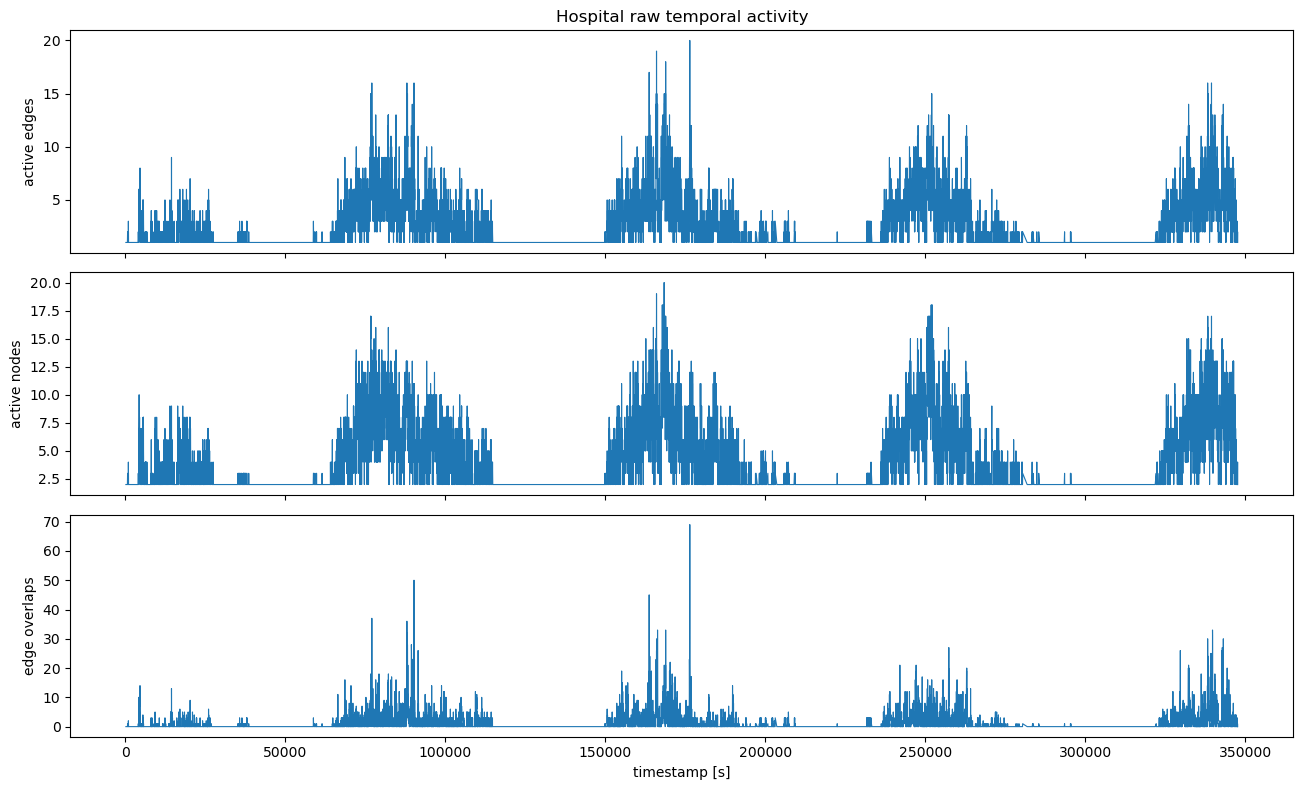

In [5]:
# ============================================================
# Cell 1 — Raw hospital temporal-network audit
#
# Goal:
#   Characterize the empirical temporal network before choosing
#   any coarse-graining or dynamical protocol.
#
# No dynamical model is used here.
# ============================================================

from itertools import combinations


# ============================================================
# 1. Aggregated empirical graph
# ============================================================

G_agg = nx.Graph()

G_agg.add_nodes_from(
    nodes
)

G_agg.add_edges_from(
    raw_edges
)

assert (
    G_agg.number_of_nodes()
    ==
    len(nodes)
)

assert (
    G_agg.number_of_edges()
    ==
    len(raw_edges)
)


aggregated_degrees = np.array([
    G_agg.degree(node)
    for node in nodes
])

print("Aggregated hospital network")
print("---------------------------")

print(
    "N =",
    G_agg.number_of_nodes()
)

print(
    "|E| =",
    G_agg.number_of_edges()
)

print(
    "connected =",
    nx.is_connected(G_agg)
)

print(
    "mean degree =",
    aggregated_degrees.mean()
)

print(
    "degree range =",
    (
        aggregated_degrees.min(),
        aggregated_degrees.max(),
    )
)

print(
    "density =",
    nx.density(G_agg)
)

print(
    "average clustering =",
    nx.average_clustering(G_agg)
)

if nx.is_connected(G_agg):

    print(
        "average shortest path length =",
        nx.average_shortest_path_length(
            G_agg
        )
    )


# ============================================================
# 2. Exact raw snapshot representation
#
# One raw snapshot = all empirical contacts recorded at one
# observed timestamp.
#
# Empty 20-second bins are NOT inserted yet.
# ============================================================

raw_snapshot_edges = {}

for timestamp, frame in raw_contacts.groupby(
    "timestamp",
    sort=True,
):

    raw_snapshot_edges[
        int(timestamp)
    ] = tuple(
        sorted(
            set(
                zip(
                    frame["node_u"],
                    frame["node_v"],
                )
            )
        )
    )


assert (
    len(raw_snapshot_edges)
    ==
    len(timestamps)
)


# ============================================================
# 3. Snapshot-level activity
# ============================================================

snapshot_rows = []

for timestamp in timestamps:

    timestamp = int(timestamp)

    snapshot = raw_snapshot_edges[
        timestamp
    ]

    active_nodes = set()

    for edge in snapshot:
        active_nodes.update(edge)

    # Number of edge pairs sharing at least one node
    overlap_count = 0

    for e1, e2 in combinations(
        snapshot,
        2,
    ):

        if set(e1) & set(e2):
            overlap_count += 1

    snapshot_rows.append({

        "timestamp":
            timestamp,

        "n_edges":
            len(snapshot),

        "n_active_nodes":
            len(active_nodes),

        "internal_edge_overlaps":
            overlap_count,
    })


raw_snapshot_ledger = pd.DataFrame(
    snapshot_rows
)


# ============================================================
# 4. Timestamp-gap statistics
#
# Original sensing resolution is 20 s.
# Large gaps correspond to periods with no recorded contacts.
# ============================================================

timestamp_gaps = np.diff(
    timestamps
)

assert np.all(
    timestamp_gaps % 20 == 0
)

missing_20s_bins_between_observations = (
    timestamp_gaps // 20
    - 1
)


# Full temporal grid including empty bins
full_timestamp_grid = np.arange(
    timestamps[0],
    timestamps[-1] + 20,
    20,
    dtype=np.int64,
)

n_full_bins = len(
    full_timestamp_grid
)

n_empty_bins = (
    n_full_bins
    -
    len(timestamps)
)


# ============================================================
# 5. Empirical edge persistence / contact frequency
# ============================================================

edge_contact_counts = (
    raw_contacts
    .groupby(
        ["node_u", "node_v"]
    )
    .size()
    .rename(
        "n_20s_contacts"
    )
    .reset_index()
)

edge_contact_counts[
    "contact_duration_s"
] = (
    20
    *
    edge_contact_counts[
        "n_20s_contacts"
    ]
)


# ============================================================
# 6. Consecutive observed-snapshot overlap
#
# This is NOT yet the final temporal-overlap quantity used for
# TSC. It simply characterizes persistence between neighboring
# observed contact snapshots.
# ============================================================

consecutive_rows = []

for a in range(
    len(timestamps) - 1
):

    t1 = int(
        timestamps[a]
    )

    t2 = int(
        timestamps[a + 1]
    )

    E1 = set(
        raw_snapshot_edges[t1]
    )

    E2 = set(
        raw_snapshot_edges[t2]
    )

    common_edges = (
        E1 & E2
    )

    nodes1 = set(
        node
        for edge in E1
        for node in edge
    )

    nodes2 = set(
        node
        for edge in E2
        for node in edge
    )

    common_nodes = (
        nodes1 & nodes2
    )

    consecutive_rows.append({

        "t1":
            t1,

        "t2":
            t2,

        "gap_s":
            t2 - t1,

        "edges_t1":
            len(E1),

        "edges_t2":
            len(E2),

        "shared_edges":
            len(common_edges),

        "shared_active_nodes":
            len(common_nodes),
    })


consecutive_ledger = pd.DataFrame(
    consecutive_rows
)


# ============================================================
# 7. Role-mixing matrix
#
# Count contact records, not just unique aggregated edges.
# ============================================================

ROLES = [
    "ADM",
    "MED",
    "NUR",
    "PAT",
]

role_to_index = {
    role: i
    for i, role in enumerate(
        ROLES
    )
}

role_contact_matrix = np.zeros(
    (
        len(ROLES),
        len(ROLES),
    ),
    dtype=int,
)


for row in raw_contacts.itertuples(
    index=False
):

    a = role_to_index[
        row.role_i
    ]

    b = role_to_index[
        row.role_j
    ]

    role_contact_matrix[
        a,
        b
    ] += 1

    if a != b:

        role_contact_matrix[
            b,
            a
        ] += 1


role_contact_df = pd.DataFrame(
    role_contact_matrix,
    index=ROLES,
    columns=ROLES,
)


# ============================================================
# 8. Summary
# ============================================================

print()
print(
    "Raw temporal activity"
)
print(
    "---------------------"
)

print(
    "observed non-empty timestamps =",
    len(timestamps)
)

print(
    "full 20-s bins over data span =",
    n_full_bins
)

print(
    "empty 20-s bins =",
    n_empty_bins
)

print(
    "fraction non-empty =",
    len(timestamps)
    /
    n_full_bins
)

print()

print(
    "edges / observed snapshot:"
)

print(
    raw_snapshot_ledger[
        "n_edges"
    ].describe()
)

print()

print(
    "active nodes / observed snapshot:"
)

print(
    raw_snapshot_ledger[
        "n_active_nodes"
    ].describe()
)

print()

print(
    "internal edge overlaps / observed snapshot:"
)

print(
    raw_snapshot_ledger[
        "internal_edge_overlaps"
    ].describe()
)

print()

print(
    "timestamp gap [s]:"
)

print(
    pd.Series(
        timestamp_gaps
    ).describe()
)

print()

print(
    "maximum timestamp gap [s] =",
    int(
        timestamp_gaps.max()
    )
)

print()

print(
    "empirical edge contact-count distribution:"
)

print(
    edge_contact_counts[
        "n_20s_contacts"
    ].describe()
)

print()

print(
    "consecutive observed snapshots:"
)

print(
    consecutive_ledger[
        [
            "shared_edges",
            "shared_active_nodes",
        ]
    ].describe()
)

print()

print(
    "role-contact matrix:"
)

display(
    role_contact_df
)


# ============================================================
# 9. Quick temporal plots
# ============================================================

fig, axes = plt.subplots(
    3,
    1,
    figsize=(13, 8),
    sharex=True,
)

axes[0].plot(
    raw_snapshot_ledger[
        "timestamp"
    ],
    raw_snapshot_ledger[
        "n_edges"
    ],
    linewidth=0.8,
)

axes[0].set_ylabel(
    "active edges"
)

axes[0].set_title(
    "Hospital raw temporal activity"
)


axes[1].plot(
    raw_snapshot_ledger[
        "timestamp"
    ],
    raw_snapshot_ledger[
        "n_active_nodes"
    ],
    linewidth=0.8,
)

axes[1].set_ylabel(
    "active nodes"
)


axes[2].plot(
    raw_snapshot_ledger[
        "timestamp"
    ],
    raw_snapshot_ledger[
        "internal_edge_overlaps"
    ],
    linewidth=0.8,
)

axes[2].set_ylabel(
    "edge overlaps"
)

axes[2].set_xlabel(
    "timestamp [s]"
)


plt.tight_layout()
plt.show()

Allen-style hospital preaggregation complete.
---------------------------------------------
raw empirical nodes = 75
Allen start time = 140
Allen total time [s] = 347500



,M,interval_s,interval_min,covered_duration_s,omitted_tail_s,empty_snapshots,mean_edges_per_snapshot,median_edges_per_snapshot,max_edges_per_snapshot,mean_active_nodes,union_edges,edge_snapshot_exposure
0,200,1737,28.950000,347400,100,31,27.34000,18.5,117,13.1750,1139,5468
1,1000,347,5.783333,347000,500,281,9.27800,5.0,66,7.9370,1139,9278
2,4000,86,1.433333,344000,3500,1458,4.00425,2.0,35,4.9655,1128,16017


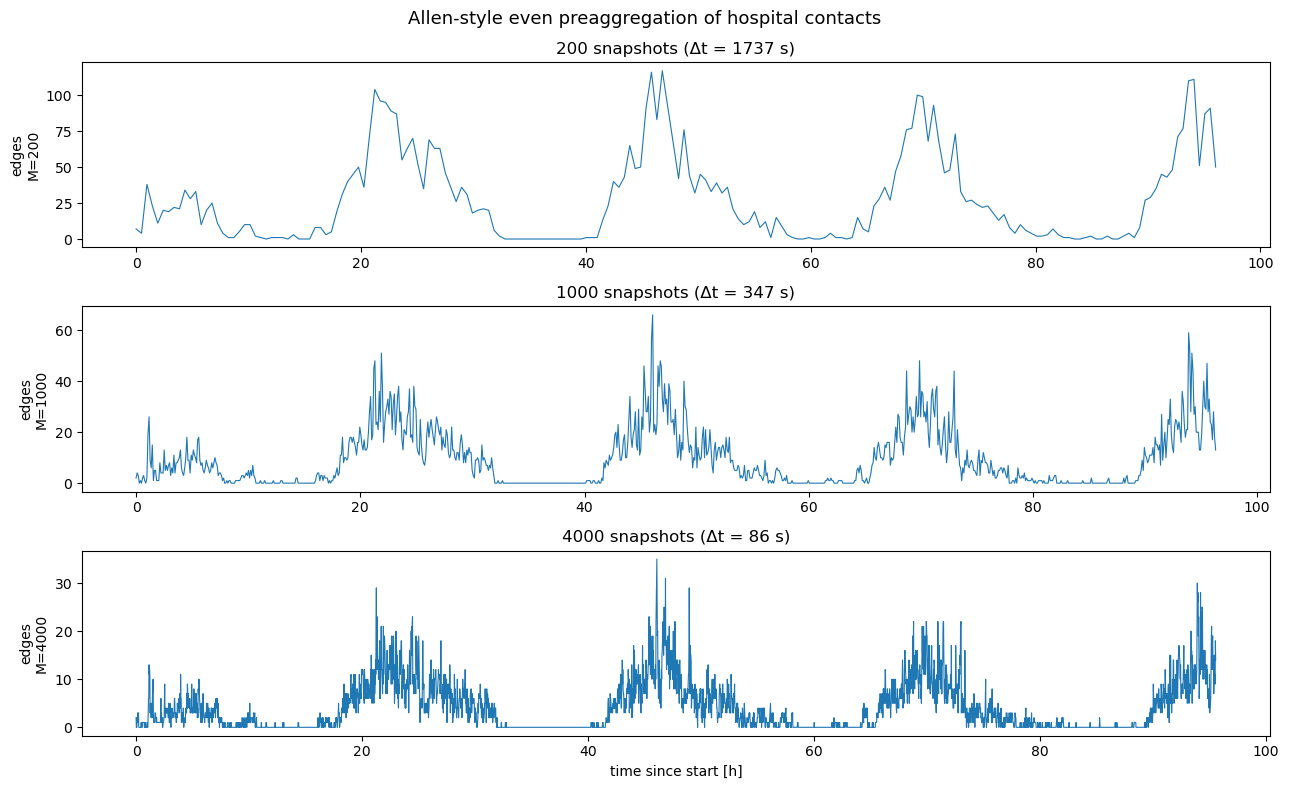

In [6]:
# ============================================================
# Cell 2 — Allen-style even temporal preaggregation
#
# Replicates the preprocessing used in:
#
#   Allen, Moore & Hébert-Dufresne, PRL 132, 077402 (2024)
#
# For target resolution M:
#
#     interval = floor(total_time / M)
#
# The physical time axis is split into M consecutive
# equal-width windows.
#
# A dyadic contact is present in coarse snapshot r iff
# it appears at least once inside that time window.
#
# Thus each coarse snapshot is a binary empirical graph.
#
# No TSC dynamics are introduced yet.
# ============================================================


# ------------------------------------------------------------
# Allen et al. hospital temporal constants
#
# Their code uses:
#
#     HOSP_START_TIME = 140
#     HOSP_TOTAL_TIME = 347640 - 140 = 347500
#
# Note:
#   this follows their implementation exactly and therefore
#   does NOT include the extra final 20-s bin duration.
# ------------------------------------------------------------

ALLEN_START_TIME = 140

ALLEN_TOTAL_TIME = (
    347640
    -
    140
)

ALLEN_RESOLUTIONS = (
    200,
    1000,
    4000,
)


assert (
    int(timestamps[0])
    ==
    ALLEN_START_TIME
)

assert (
    int(timestamps[-1])
    ==
    347640
)


# ============================================================
# 1. Stable empirical node relabeling
#
# Raw hospital IDs are retained separately.
#
# TSC convention:
#
#     empirical IDs
#         ->
#     1, 2, ..., N
#
# ============================================================

empirical_nodes = tuple(
    sorted(nodes)
)

N_EMPIRICAL = len(
    empirical_nodes
)

assert N_EMPIRICAL == 75


empirical_to_tsc = {
    node_id: index + 1
    for index, node_id
    in enumerate(empirical_nodes)
}

tsc_to_empirical = {
    tsc_id: empirical_id
    for empirical_id, tsc_id
    in empirical_to_tsc.items()
}


# Role map in TSC labels
tsc_node_roles = {
    empirical_to_tsc[node]:
        node_roles[node]

    for node in empirical_nodes
}


# ============================================================
# 2. Allen-style preaggregation
# ============================================================

def allen_preaggregate(
    contacts,
    n_snapshots,
):
    """
    Evenly coarse-grain the hospital temporal contact data
    following the Allen et al. implementation.

    Parameters
    ----------
    contacts : DataFrame
        raw_contacts from Cell 0.

    n_snapshots : int
        Target number of coarse temporal snapshots.

    Returns
    -------
    result : dict

        interval_seconds
        covered_duration_seconds
        omitted_tail_seconds

        raw_edge_snapshots
            Tuple of binary edge sets using original
            empirical node IDs.

        tsc_edge_snapshots
            Same snapshots relabeled to TSC 1,...,N nodes.

        ledger
            Snapshot-level activity diagnostics.
    """

    n_snapshots = int(
        n_snapshots
    )

    # --------------------------------------------------------
    # Exact Allen implementation:
    #
    #     int(total_time / n_snapshots)
    #
    # Python int truncates downward here because values
    # are positive.
    # --------------------------------------------------------

    interval = int(
        ALLEN_TOTAL_TIME
        /
        n_snapshots
    )

    if interval <= 0:
        raise ValueError(
            "Preaggregation interval must be positive."
        )


    raw_edge_snapshots = []
    tsc_edge_snapshots = []

    rows = []


    for r in range(
        n_snapshots
    ):

        t_start = (
            ALLEN_START_TIME
            +
            r * interval
        )

        t_end = (
            t_start
            +
            interval
        )


        # ----------------------------------------------------
        # Contacts falling inside:
        #
        #     [t_start, t_end)
        #
        # exactly as in produce_snapshots().
        # ----------------------------------------------------

        frame = contacts.loc[
            (
                contacts["timestamp"]
                >=
                t_start
            )
            &
            (
                contacts["timestamp"]
                <
                t_end
            )
        ]


        # ----------------------------------------------------
        # Binary coarse snapshot:
        #
        # repeated contacts inside the same coarse window
        # collapse to a single undirected edge.
        # ----------------------------------------------------

        empirical_edges = tuple(
            sorted(
                set(
                    zip(
                        frame["node_u"],
                        frame["node_v"],
                    )
                )
            )
        )


        tsc_edges = tuple(
            sorted(
                (
                    empirical_to_tsc[u],
                    empirical_to_tsc[v],
                )

                for u, v
                in empirical_edges
            )
        )


        raw_edge_snapshots.append(
            empirical_edges
        )

        tsc_edge_snapshots.append(
            tsc_edges
        )


        active_nodes = {
            node

            for edge in empirical_edges
            for node in edge
        }


        rows.append({

            "snapshot":
                r + 1,

            "t_start":
                int(t_start),

            "t_end":
                int(t_end),

            "duration_s":
                int(interval),

            "n_edges":
                len(empirical_edges),

            "n_active_nodes":
                len(active_nodes),

            "n_contact_records":
                len(frame),

            "is_empty":
                len(empirical_edges) == 0,
        })


    covered_duration = (
        interval
        *
        n_snapshots
    )

    omitted_tail = (
        ALLEN_TOTAL_TIME
        -
        covered_duration
    )


    return {

        "n_snapshots":
            n_snapshots,

        "interval_seconds":
            interval,

        "covered_duration_seconds":
            covered_duration,

        "omitted_tail_seconds":
            omitted_tail,

        "raw_edge_snapshots":
            tuple(
                raw_edge_snapshots
            ),

        "tsc_edge_snapshots":
            tuple(
                tsc_edge_snapshots
            ),

        "ledger":
            pd.DataFrame(
                rows
            ),
    }


# ============================================================
# 3. Construct the three Fig.-4 preprocessing resolutions
# ============================================================

allen_preaggregated = {

    M: allen_preaggregate(
        raw_contacts,
        M,
    )

    for M in ALLEN_RESOLUTIONS
}


# Convenience aliases
hospital_200 = (
    allen_preaggregated[200]
)

hospital_1000 = (
    allen_preaggregated[1000]
)

hospital_4000 = (
    allen_preaggregated[4000]
)


# ============================================================
# 4. Exposure / structural diagnostics
# ============================================================

resolution_rows = []


for M in ALLEN_RESOLUTIONS:

    data = (
        allen_preaggregated[M]
    )

    ledger = (
        data["ledger"]
    )

    snapshots_M = (
        data[
            "raw_edge_snapshots"
        ]
    )


    # --------------------------------------------------------
    # Aggregated union graph over the covered period
    # --------------------------------------------------------

    union_edges = set()

    for snapshot in snapshots_M:
        union_edges.update(
            snapshot
        )


    # --------------------------------------------------------
    # Temporal edge-snapshot exposure
    #
    # Number of coarse snapshots in which each edge appears.
    # --------------------------------------------------------

    total_edge_snapshot_exposure = sum(
        len(snapshot)
        for snapshot
        in snapshots_M
    )


    resolution_rows.append({

        "M":
            M,

        "interval_s":
            data[
                "interval_seconds"
            ],

        "interval_min":
            data[
                "interval_seconds"
            ]
            /
            60.0,

        "covered_duration_s":
            data[
                "covered_duration_seconds"
            ],

        "omitted_tail_s":
            data[
                "omitted_tail_seconds"
            ],

        "empty_snapshots":
            int(
                ledger[
                    "is_empty"
                ].sum()
            ),

        "mean_edges_per_snapshot":
            float(
                ledger[
                    "n_edges"
                ].mean()
            ),

        "median_edges_per_snapshot":
            float(
                ledger[
                    "n_edges"
                ].median()
            ),

        "max_edges_per_snapshot":
            int(
                ledger[
                    "n_edges"
                ].max()
            ),

        "mean_active_nodes":
            float(
                ledger[
                    "n_active_nodes"
                ].mean()
            ),

        "union_edges":
            len(
                union_edges
            ),

        "edge_snapshot_exposure":
            int(
                total_edge_snapshot_exposure
            ),
    })


allen_resolution_summary = pd.DataFrame(
    resolution_rows
)


# ============================================================
# 5. Consistency audit
# ============================================================

for M in ALLEN_RESOLUTIONS:

    data = (
        allen_preaggregated[M]
    )

    assert (
        len(
            data[
                "raw_edge_snapshots"
            ]
        )
        ==
        M
    )

    assert (
        len(
            data[
                "tsc_edge_snapshots"
            ]
        )
        ==
        M
    )

    assert (
        len(
            data[
                "ledger"
            ]
        )
        ==
        M
    )

    assert all(
        (
            1 <= u <= N_EMPIRICAL
            and
            1 <= v <= N_EMPIRICAL
            and
            u < v
        )

        for snapshot
        in data[
            "tsc_edge_snapshots"
        ]

        for u, v
        in snapshot
    )


# Allen-code-specific expected intervals
assert (
    hospital_200[
        "interval_seconds"
    ]
    ==
    1737
)

assert (
    hospital_1000[
        "interval_seconds"
    ]
    ==
    347
)

assert (
    hospital_4000[
        "interval_seconds"
    ]
    ==
    86
)


# ============================================================
# 6. Summary
# ============================================================

print(
    "Allen-style hospital preaggregation complete."
)

print(
    "---------------------------------------------"
)

print(
    "raw empirical nodes =",
    N_EMPIRICAL
)

print(
    "Allen start time =",
    ALLEN_START_TIME
)

print(
    "Allen total time [s] =",
    ALLEN_TOTAL_TIME
)

print()

display(
    allen_resolution_summary
)


# ============================================================
# 7. Snapshot activity across the three resolutions
# ============================================================

fig, axes = plt.subplots(
    3,
    1,
    figsize=(13, 8),
    sharex=False,
)


for ax, M in zip(
    axes,
    ALLEN_RESOLUTIONS,
):

    ledger = (
        allen_preaggregated[M][
            "ledger"
        ]
    )

    time_hours = (
        ledger[
            "t_start"
        ]
        -
        ALLEN_START_TIME
    ) / 3600.0


    ax.plot(
        time_hours,
        ledger[
            "n_edges"
        ],
        linewidth=0.8,
    )

    ax.set_ylabel(
        f"edges\nM={M}"
    )

    ax.set_title(
        (
            f"{M} snapshots "
            f"(Δt = "
            f"{allen_preaggregated[M]['interval_seconds']} s)"
        )
    )


axes[-1].set_xlabel(
    "time since start [h]"
)

fig.suptitle(
    "Allen-style even preaggregation of hospital contacts",
    fontsize=13,
)

plt.tight_layout()
plt.show()

Auditing M=200 ...
Auditing M=1000 ...
Auditing M=4000 ...

Temporal structural audit across resolutions
--------------------------------------------


,M,interval_s,aggregated_edges,aggregated_wedges,accessible_wedges,accessible_fraction,chronology_active_wedges,active_fraction_of_all,active_fraction_of_accessible,unique_accessible_triads,unique_active_triads,mean_abs_order_imbalance,mean_abs_normalized_imbalance,median_abs_normalized_imbalance,mean_consecutive_shared_edges,mean_consecutive_cross_wedges,mean_consecutive_unique_triads
0,200,1737,1139,41913,41761,0.996373,39600,0.944814,0.948253,25427,24511,15.225896,0.662563,0.777778,11.005025,278.251256,175.728643
1,1000,347,1139,41913,41870,0.998974,40216,0.959511,0.960497,25475,24745,48.491709,0.672238,0.785714,3.895896,39.110110,26.330330
2,4000,86,1128,41188,41180,0.999806,40090,0.973342,0.973531,25174,24701,164.824124,0.692000,0.833333,2.038260,8.266317,5.170293



M=200 chronology controls
-------------------------
reverse sign-check max error = 0



,protocol,aggregated_edges,aggregated_wedges,accessible_wedges,chronology_active_wedges,unique_active_triads,signature_L2,cosine_with_original
0,original,1139,41913,41761,39600,24511,7598.535451,1.000000
1,reverse,1139,41913,41761,39600,24511,7598.535451,-1.000000
2,shuffle_001,1139,41913,41761,37960,23532,3055.273637,0.054113


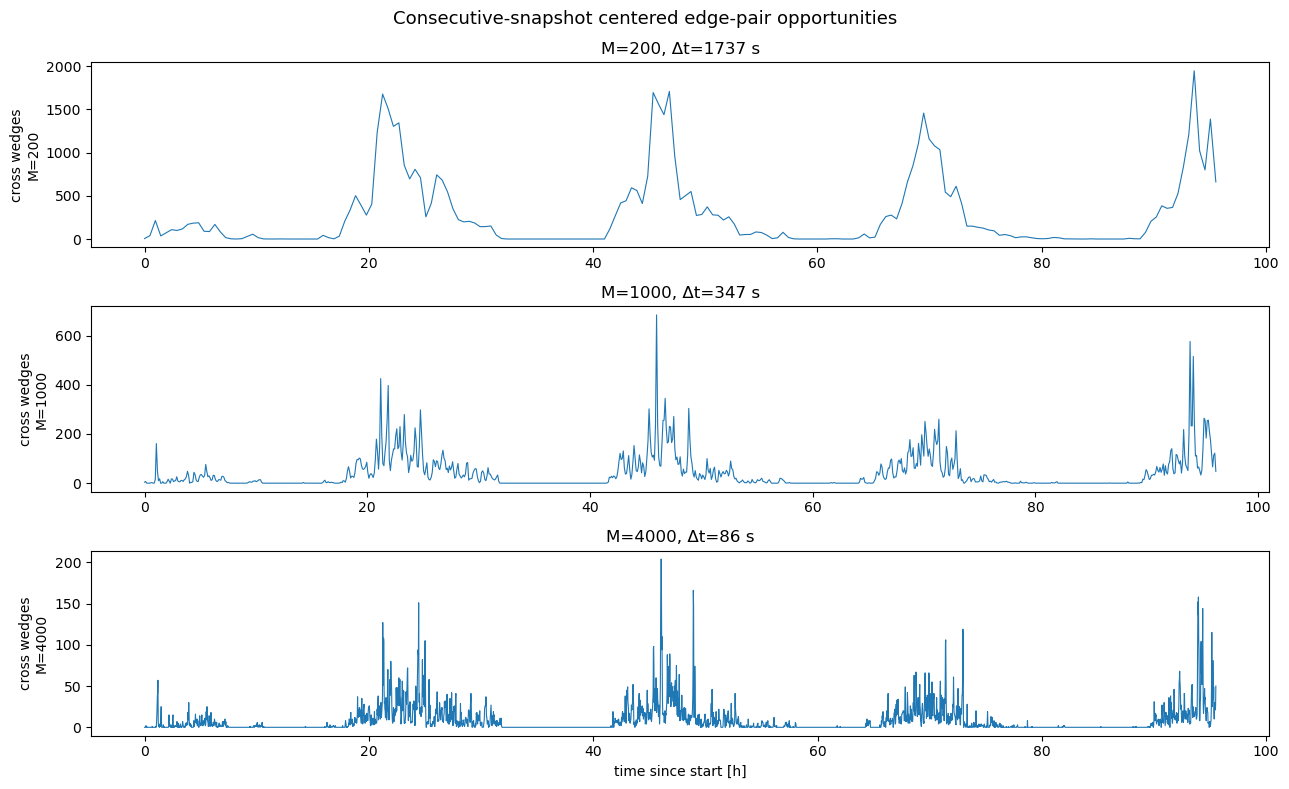


Cell 3 structural audit: PASS


In [7]:
# ============================================================
# Cell 3 — Temporal structural audit across resolutions
#
# Goals:
#
#   1. Quantify snapshot-to-snapshot persistence.
#
#   2. Identify cross-time centered edge pairs ("wedges"):
#
#          (i,j)   and   (j,k)
#
#      which are the microscopic opportunities for nonlinear
#      pairwise dynamics to generate effective triadic terms.
#
#   3. Compute the temporal ordering imbalance
#
#          C_ef = N(e before f) - N(f before e)
#
#      for every aggregated wedge.
#
#   4. Compare M = 200, 1000, 4000.
#
#   5. At the primary M=200 resolution, construct:
#
#          original chronology
#          reversed chronology
#          one deterministic shuffled chronology
#
#      and verify the expected structural invariants.
#
# No dynamical model is introduced yet.
# ============================================================

from collections import defaultdict
from itertools import combinations


# ============================================================
# 1. Basic helpers
# ============================================================

def canonical_edge(u, v):
    """Canonical undirected edge."""
    return (
        (u, v)
        if u < v
        else (v, u)
    )


def build_edge_occurrences(
    snapshots,
):
    """
    For every edge, record the coarse-snapshot indices
    in which that edge is active.
    """

    occurrences = defaultdict(list)

    for r, snapshot in enumerate(
        snapshots
    ):

        for u, v in snapshot:

            edge = canonical_edge(
                u,
                v,
            )

            occurrences[
                edge
            ].append(
                r
            )

    return {
        edge:
            np.asarray(
                times,
                dtype=np.int32,
            )

        for edge, times
        in occurrences.items()
    }


def build_aggregated_graph(
    snapshots,
):
    """Union graph of a temporal protocol."""

    G = nx.Graph()

    G.add_nodes_from(
        range(
            1,
            N_EMPIRICAL + 1,
        )
    )

    for snapshot in snapshots:

        G.add_edges_from(
            snapshot
        )

    return G


# ============================================================
# 2. Temporal order counts for one edge pair
# ============================================================

def edge_pair_order_counts(
    times_e,
    times_f,
):
    """
    Count:

        e_before_f
        f_before_e
        simultaneous

    across the complete coarse-snapshot chronology.

    Simultaneous means both edges occur in the same snapshot.

    Since each edge appears at most once per binary coarse
    snapshot:

        cross_pairs
            =
        len(times_e) * len(times_f)
            -
        simultaneous
    """

    times_e = np.asarray(
        times_e,
        dtype=np.int32,
    )

    times_f = np.asarray(
        times_f,
        dtype=np.int32,
    )


    # --------------------------------------------------------
    # Number of f-occurrences strictly after each e-occurrence
    # --------------------------------------------------------

    f_after_e = (
        len(times_f)
        -
        np.searchsorted(
            times_f,
            times_e,
            side="right",
        )
    )

    e_before_f = int(
        np.sum(
            f_after_e
        )
    )


    # --------------------------------------------------------
    # Number of e-occurrences strictly after each f-occurrence
    # --------------------------------------------------------

    e_after_f = (
        len(times_e)
        -
        np.searchsorted(
            times_e,
            times_f,
            side="right",
        )
    )

    f_before_e = int(
        np.sum(
            e_after_f
        )
    )


    simultaneous = int(
        np.intersect1d(
            times_e,
            times_f,
            assume_unique=True,
        ).size
    )


    cross_pairs = (
        len(times_e)
        *
        len(times_f)
        -
        simultaneous
    )


    assert (
        e_before_f
        +
        f_before_e
        ==
        cross_pairs
    )


    imbalance = (
        e_before_f
        -
        f_before_e
    )


    normalized_imbalance = (
        imbalance
        /
        cross_pairs
        if cross_pairs > 0
        else 0.0
    )


    return {
        "e_before_f":
            e_before_f,

        "f_before_e":
            f_before_e,

        "simultaneous":
            simultaneous,

        "cross_pairs":
            int(cross_pairs),

        "order_imbalance":
            int(imbalance),

        "normalized_imbalance":
            float(
                normalized_imbalance
            ),
    }


# ============================================================
# 3. Full wedge audit for one temporal protocol
# ============================================================

def temporal_wedge_audit(
    snapshots,
):
    """
    Enumerate every pair of distinct aggregated edges sharing
    exactly one node.

    For each wedge:

        e = (i,j)
        f = (j,k)

    compute its cross-time accessibility and ordering
    imbalance.

    The lexicographic ordering of (e,f) fixes the sign
    convention for order_imbalance.
    """

    edge_occurrences = (
        build_edge_occurrences(
            snapshots
        )
    )

    G = build_aggregated_graph(
        snapshots
    )


    rows = []


    # --------------------------------------------------------
    # Every pair of incident edges at a center node gives one
    # structural wedge.
    #
    # Two distinct simple edges share at most one node, so
    # there is no double counting across centers.
    # --------------------------------------------------------

    for center in sorted(
        G.nodes()
    ):

        incident_edges = sorted(
            canonical_edge(
                center,
                nbr,
            )

            for nbr
            in G.neighbors(
                center
            )
        )


        for e, f in combinations(
            incident_edges,
            2,
        ):

            # Fix a global sign convention
            if f < e:
                e, f = f, e


            union_nodes = tuple(
                sorted(
                    set(e)
                    |
                    set(f)
                )
            )

            assert (
                len(union_nodes)
                ==
                3
            )


            order = (
                edge_pair_order_counts(
                    edge_occurrences[e],
                    edge_occurrences[f],
                )
            )


            cross_time_accessible = (
                order[
                    "cross_pairs"
                ]
                >
                0
            )

            chronology_active = (
                order[
                    "order_imbalance"
                ]
                !=
                0
            )


            rows.append({

                "center":
                    center,

                "edge_e":
                    e,

                "edge_f":
                    f,

                "wedge":
                    (e, f),

                "triad_support":
                    union_nodes,

                "n_e_snapshots":
                    len(
                        edge_occurrences[e]
                    ),

                "n_f_snapshots":
                    len(
                        edge_occurrences[f]
                    ),

                **order,

                "cross_time_accessible":
                    cross_time_accessible,

                "chronology_active":
                    chronology_active,
            })


    wedge_ledger = pd.DataFrame(
        rows
    )


    return {

        "graph":
            G,

        "edge_occurrences":
            edge_occurrences,

        "wedge_ledger":
            wedge_ledger,
    }


# ============================================================
# 4. Consecutive-snapshot audit
# ============================================================

def consecutive_snapshot_audit(
    snapshots,
):
    """
    Local temporal persistence between r and r+1.

    cross_wedge_pairs:
        edge in snapshot r and a different edge in snapshot
        r+1 share exactly one node.

    cross_unique_triads:
        unique 3-node supports generated by those local wedges.
    """

    rows = []


    for r in range(
        len(snapshots) - 1
    ):

        E1 = set(
            snapshots[r]
        )

        E2 = set(
            snapshots[r + 1]
        )


        nodes1 = {
            node
            for edge in E1
            for node in edge
        }

        nodes2 = {
            node
            for edge in E2
            for node in edge
        }


        shared_edges = (
            E1
            &
            E2
        )


        cross_wedge_pairs = 0
        cross_triads = set()


        for e in E1:

            set_e = set(e)

            for f in E2:

                # Same edge has support size 2, not a wedge
                if e == f:
                    continue

                if len(
                    set_e
                    &
                    set(f)
                ) == 1:

                    cross_wedge_pairs += 1

                    triad = tuple(
                        sorted(
                            set_e
                            |
                            set(f)
                        )
                    )

                    assert (
                        len(triad)
                        ==
                        3
                    )

                    cross_triads.add(
                        triad
                    )


        edge_union = (
            E1
            |
            E2
        )

        node_union = (
            nodes1
            |
            nodes2
        )


        rows.append({

            "r":
                r,

            "edges_r":
                len(E1),

            "edges_r1":
                len(E2),

            "shared_edges":
                len(
                    shared_edges
                ),

            "edge_jaccard":
                (
                    len(shared_edges)
                    /
                    len(edge_union)
                    if edge_union
                    else 0.0
                ),

            "shared_active_nodes":
                len(
                    nodes1
                    &
                    nodes2
                ),

            "node_jaccard":
                (
                    len(
                        nodes1
                        &
                        nodes2
                    )
                    /
                    len(
                        node_union
                    )
                    if node_union
                    else 0.0
                ),

            "cross_wedge_pairs":
                cross_wedge_pairs,

            "cross_unique_triads":
                len(
                    cross_triads
                ),
        })


    return pd.DataFrame(
        rows
    )


# ============================================================
# 5. Audit all three Allen resolutions
# ============================================================

temporal_audits = {}

resolution_structural_rows = []


for M in ALLEN_RESOLUTIONS:

    print(
        f"Auditing M={M} ..."
    )


    snapshots = (
        allen_preaggregated[M][
            "tsc_edge_snapshots"
        ]
    )


    wedge_result = (
        temporal_wedge_audit(
            snapshots
        )
    )

    wedge_ledger = (
        wedge_result[
            "wedge_ledger"
        ]
    )


    consecutive_ledger_M = (
        consecutive_snapshot_audit(
            snapshots
        )
    )


    accessible = (
        wedge_ledger[
            "cross_time_accessible"
        ]
    )

    active = (
        wedge_ledger[
            "chronology_active"
        ]
    )


    accessible_triads = set(
        wedge_ledger.loc[
            accessible,
            "triad_support",
        ]
    )

    active_triads = set(
        wedge_ledger.loc[
            active,
            "triad_support",
        ]
    )


    temporal_audits[M] = {

        **wedge_result,

        "consecutive_ledger":
            consecutive_ledger_M,

        "accessible_triads":
            accessible_triads,

        "active_triads":
            active_triads,
    }


    accessible_eta = (
        wedge_ledger.loc[
            accessible,
            "normalized_imbalance",
        ]
        .abs()
        .to_numpy(
            dtype=float
        )
    )


    resolution_structural_rows.append({

        "M":
            M,

        "interval_s":
            allen_preaggregated[M][
                "interval_seconds"
            ],

        "aggregated_edges":
            wedge_result[
                "graph"
            ].number_of_edges(),

        "aggregated_wedges":
            len(
                wedge_ledger
            ),

        "accessible_wedges":
            int(
                accessible.sum()
            ),

        "accessible_fraction":
            float(
                accessible.mean()
            ),

        "chronology_active_wedges":
            int(
                active.sum()
            ),

        "active_fraction_of_all":
            float(
                active.mean()
            ),

        "active_fraction_of_accessible":
            (
                float(
                    active.sum()
                    /
                    accessible.sum()
                )
                if accessible.sum() > 0
                else 0.0
            ),

        "unique_accessible_triads":
            len(
                accessible_triads
            ),

        "unique_active_triads":
            len(
                active_triads
            ),

        "mean_abs_order_imbalance":
            float(
                wedge_ledger[
                    "order_imbalance"
                ]
                .abs()
                .mean()
            ),

        "mean_abs_normalized_imbalance":
            (
                float(
                    accessible_eta.mean()
                )
                if len(accessible_eta)
                else 0.0
            ),

        "median_abs_normalized_imbalance":
            (
                float(
                    np.median(
                        accessible_eta
                    )
                )
                if len(accessible_eta)
                else 0.0
            ),

        "mean_consecutive_shared_edges":
            float(
                consecutive_ledger_M[
                    "shared_edges"
                ].mean()
            ),

        "mean_consecutive_cross_wedges":
            float(
                consecutive_ledger_M[
                    "cross_wedge_pairs"
                ].mean()
            ),

        "mean_consecutive_unique_triads":
            float(
                consecutive_ledger_M[
                    "cross_unique_triads"
                ].mean()
            ),
    })


resolution_structural_summary = (
    pd.DataFrame(
        resolution_structural_rows
    )
)


print()
print(
    "Temporal structural audit across resolutions"
)
print(
    "--------------------------------------------"
)

display(
    resolution_structural_summary
)


# ============================================================
# 6. Primary-resolution chronology controls
#
# M = 200
#
# Original:
#
#     G1, G2, ..., GM
#
# Reverse:
#
#     GM, ..., G2, G1
#
# Shuffle:
#
#     G_pi(1), ..., G_pi(M)
#
# Every protocol contains exactly the same snapshot multiset.
# ============================================================

PRIMARY_M = 200

primary_original = tuple(
    allen_preaggregated[
        PRIMARY_M
    ][
        "tsc_edge_snapshots"
    ]
)


# Exact reversal
primary_reverse = tuple(
    reversed(
        primary_original
    )
)


# Deterministic random permutation
rng_shuffle = np.random.default_rng(
    SEED_SHUFFLE
)

primary_shuffle_permutation = (
    rng_shuffle.permutation(
        PRIMARY_M
    )
)

primary_shuffle = tuple(
    primary_original[i]
    for i
    in primary_shuffle_permutation
)


hospital_200_protocols = {

    "original":
        primary_original,

    "reverse":
        primary_reverse,

    "shuffle_001":
        primary_shuffle,
}


# ============================================================
# 7. Persistent-structure invariant:
#
# Count how many snapshots contain each edge.
#
# This MUST be unchanged by any permutation of chronology.
# ============================================================

def edge_presence_signature(
    snapshots,
):

    counts = defaultdict(int)

    for snapshot in snapshots:

        for edge in snapshot:

            counts[
                canonical_edge(
                    *edge
                )
            ] += 1

    return dict(
        counts
    )


presence_original = (
    edge_presence_signature(
        primary_original
    )
)

presence_reverse = (
    edge_presence_signature(
        primary_reverse
    )
)

presence_shuffle = (
    edge_presence_signature(
        primary_shuffle
    )
)


assert (
    presence_original
    ==
    presence_reverse
)

assert (
    presence_original
    ==
    presence_shuffle
)


# ============================================================
# 8. Compute temporal wedge signatures
# ============================================================

audit_original = (
    temporal_audits[
        PRIMARY_M
    ]
)

audit_reverse = (
    temporal_wedge_audit(
        primary_reverse
    )
)

audit_shuffle = (
    temporal_wedge_audit(
        primary_shuffle
    )
)


def wedge_signature_dict(
    audit,
):
    ledger = (
        audit[
            "wedge_ledger"
        ]
    )

    return {

        row.wedge:
            int(
                row.order_imbalance
            )

        for row in ledger.itertuples(
            index=False
        )
    }


def wedge_crosspair_dict(
    audit,
):
    ledger = (
        audit[
            "wedge_ledger"
        ]
    )

    return {

        row.wedge:
            int(
                row.cross_pairs
            )

        for row in ledger.itertuples(
            index=False
        )
    }


sig_original = (
    wedge_signature_dict(
        audit_original
    )
)

sig_reverse = (
    wedge_signature_dict(
        audit_reverse
    )
)

sig_shuffle = (
    wedge_signature_dict(
        audit_shuffle
    )
)


cross_original = (
    wedge_crosspair_dict(
        audit_original
    )
)

cross_reverse = (
    wedge_crosspair_dict(
        audit_reverse
    )
)

cross_shuffle = (
    wedge_crosspair_dict(
        audit_shuffle
    )
)


# Snapshot permutation preserves all cross-time availability
assert (
    cross_original
    ==
    cross_reverse
)

assert (
    cross_original
    ==
    cross_shuffle
)


# Exact reverse-order prediction:
#
#     C_ef(reverse) = - C_ef(original)
#
max_reverse_sign_error = max(

    abs(
        sig_reverse[wedge]
        +
        sig_original[wedge]
    )

    for wedge
    in sig_original
)

assert (
    max_reverse_sign_error
    ==
    0
)


# ============================================================
# 9. Signature comparison
# ============================================================

signature_keys = sorted(
    sig_original
)


vec_original = np.asarray(
    [
        sig_original[key]
        for key in signature_keys
    ],
    dtype=float,
)

vec_reverse = np.asarray(
    [
        sig_reverse[key]
        for key in signature_keys
    ],
    dtype=float,
)

vec_shuffle = np.asarray(
    [
        sig_shuffle[key]
        for key in signature_keys
    ],
    dtype=float,
)


def cosine_similarity(
    x,
    y,
):

    nx_ = np.linalg.norm(
        x
    )

    ny_ = np.linalg.norm(
        y
    )

    if (
        nx_ == 0
        or
        ny_ == 0
    ):
        return np.nan

    return float(
        np.dot(
            x,
            y,
        )
        /
        (
            nx_
            *
            ny_
        )
    )


control_rows = []


for name, audit, vector in (

    (
        "original",
        audit_original,
        vec_original,
    ),

    (
        "reverse",
        audit_reverse,
        vec_reverse,
    ),

    (
        "shuffle_001",
        audit_shuffle,
        vec_shuffle,
    ),
):

    ledger = (
        audit[
            "wedge_ledger"
        ]
    )

    accessible = (
        ledger[
            "cross_time_accessible"
        ]
    )

    active = (
        ledger[
            "chronology_active"
        ]
    )


    active_triads = set(
        ledger.loc[
            active,
            "triad_support",
        ]
    )


    control_rows.append({

        "protocol":
            name,

        "aggregated_edges":
            audit[
                "graph"
            ].number_of_edges(),

        "aggregated_wedges":
            len(
                ledger
            ),

        "accessible_wedges":
            int(
                accessible.sum()
            ),

        "chronology_active_wedges":
            int(
                active.sum()
            ),

        "unique_active_triads":
            len(
                active_triads
            ),

        "signature_L2":
            float(
                np.linalg.norm(
                    vector
                )
            ),

        "cosine_with_original":
            cosine_similarity(
                vec_original,
                vector,
            ),
    })


chronology_control_summary = (
    pd.DataFrame(
        control_rows
    )
)


print()
print(
    "M=200 chronology controls"
)
print(
    "-------------------------"
)

print(
    "reverse sign-check max error =",
    max_reverse_sign_error
)

print()

display(
    chronology_control_summary
)


# ============================================================
# 10. Plot local cross-time wedge opportunities
#     across resolutions
# ============================================================

fig, axes = plt.subplots(
    3,
    1,
    figsize=(13, 8),
    sharex=False,
)


for ax, M in zip(
    axes,
    ALLEN_RESOLUTIONS,
):

    ledger = (
        temporal_audits[M][
            "consecutive_ledger"
        ]
    )

    interval_s = (
        allen_preaggregated[M][
            "interval_seconds"
        ]
    )

    time_hours = (
        np.arange(
            len(ledger)
        )
        *
        interval_s
        /
        3600.0
    )


    ax.plot(
        time_hours,
        ledger[
            "cross_wedge_pairs"
        ],
        linewidth=0.8,
    )

    ax.set_ylabel(
        f"cross wedges\nM={M}"
    )

    ax.set_title(
        (
            f"M={M}, "
            f"Δt={interval_s} s"
        )
    )


axes[-1].set_xlabel(
    "time since start [h]"
)

fig.suptitle(
    (
        "Consecutive-snapshot centered edge-pair "
        "opportunities"
    ),
    fontsize=13,
)

plt.tight_layout()
plt.show()


print()
print(
    "Cell 3 structural audit: PASS"
)

In [8]:
# ============================================================
# Cell 4 — Controlled epidemic dynamics on hospital chronology
#
# Primary empirical dynamics:
#
#     Full nonlinear SI
#
#         dp_i/dt = (1 - p_i) sum_j A_ij(t) p_j
#
# Linear boundary control:
#
#         dp_i/dt = sum_j A_ij(t) p_j
#
#
# Important normalization:
#
#     SI_RATE = 1
#
# The overall dynamical scale will be controlled later by
# epsilon. For a protocol with M snapshots, each snapshot
# acts for duration:
#
#         epsilon / M
#
# Hence beta is absorbed into epsilon.
#
# This keeps the empirical benchmark consistent with the
# synthetic TSC convention:
#
#         U_epsilon =
#             exp[(epsilon/M) G_M]
#             ...
#             exp[(epsilon/M) G_1]
#
# No native higher-order interactions are introduced.
# ============================================================


# ============================================================
# 1. Freeze primary empirical protocol
# ============================================================

PRIMARY_M = 200
SI_RATE = 1.0


primary_snapshots = tuple(
    allen_preaggregated[
        PRIMARY_M
    ][
        "tsc_edge_snapshots"
    ]
)

assert (
    len(primary_snapshots)
    ==
    PRIMARY_M
)

assert (
    N_EMPIRICAL
    ==
    75
)


print(
    "Primary empirical protocol:"
)

print(
    "  M =",
    PRIMARY_M
)

print(
    "  empirical coarse interval [s] =",
    allen_preaggregated[
        PRIMARY_M
    ][
        "interval_seconds"
    ]
)

print(
    "  SI_RATE =",
    SI_RATE
)


# ============================================================
# 2. Dense binary adjacency representation
#
# Shape:
#
#     (M, N, N)
#
# At N=75 and M=200 this is small enough to keep explicitly
# and is convenient for exact generator checks.
# ============================================================

A_primary = np.zeros(
    (
        PRIMARY_M,
        N_EMPIRICAL,
        N_EMPIRICAL,
    ),
    dtype=np.float64,
)


for r, snapshot in enumerate(
    primary_snapshots
):

    for u, v in snapshot:

        # TSC labels are 1,...,N
        i = u - 1
        j = v - 1

        A_primary[
            r,
            i,
            j
        ] = 1.0

        A_primary[
            r,
            j,
            i
        ] = 1.0


# ------------------------------------------------------------
# Basic adjacency checks
# ------------------------------------------------------------

assert np.all(
    A_primary
    ==
    np.swapaxes(
        A_primary,
        1,
        2,
    )
)

assert np.all(
    np.diagonal(
        A_primary,
        axis1=1,
        axis2=2,
    )
    ==
    0.0
)

assert set(
    np.unique(
        A_primary
    )
).issubset(
    {0.0, 1.0}
)


# Each undirected edge contributes two matrix entries
matrix_edge_counts = (
    A_primary.sum(
        axis=(1, 2)
    )
    /
    2.0
)

ledger_edge_counts = (
    hospital_200[
        "ledger"
    ][
        "n_edges"
    ]
    .to_numpy(
        dtype=float
    )
)

assert np.allclose(
    matrix_edge_counts,
    ledger_edge_counts,
)


# ============================================================
# 3. Snapshot generators
# ============================================================

def _neighbor_pressure(
    X,
    A,
):
    """
    Compute A p.

    Supports:

        X.shape == (N,)
        X.shape == (B, N)
    """

    X = np.asarray(
        X,
        dtype=float,
    )

    if X.ndim == 1:

        return (
            A
            @
            X
        )

    elif X.ndim == 2:

        return (
            X
            @
            A.T
        )

    else:

        raise ValueError(
            "X must have shape (N,) or (B,N)."
        )


def full_si_generator(
    X,
    A,
    rate=SI_RATE,
):
    """
    Full nonlinear SI vector field:

        F_i =
            rate
            * (1 - p_i)
            * sum_j A_ij p_j

    Polynomial degree = 2.
    """

    X = np.asarray(
        X,
        dtype=float,
    )

    pressure = (
        _neighbor_pressure(
            X,
            A,
        )
    )

    return (
        rate
        *
        (1.0 - X)
        *
        pressure
    )


def linear_si_generator(
    X,
    A,
    rate=SI_RATE,
):
    """
    Early-time linearized SI:

        F = rate * A p

    Polynomial degree = 1.
    """

    X = np.asarray(
        X,
        dtype=float,
    )

    return (
        rate
        *
        _neighbor_pressure(
            X,
            A,
        )
    )


def full_si_snapshot(
    X,
    r,
):
    """
    Full SI generator for snapshot r.
    """

    return full_si_generator(
        X,
        A_primary[r],
    )


def linear_si_snapshot(
    X,
    r,
):
    """
    Linearized SI generator for snapshot r.
    """

    return linear_si_generator(
        X,
        A_primary[r],
    )


# ============================================================
# 4. Explicit single-edge generators
#
# Useful later for algebraic interpretation:
#
# For edge (i,j):
#
#     F_i = (1-p_i)p_j
#     F_j = (1-p_j)p_i
#
# and all other components are zero.
# ============================================================

def full_si_edge_generator(
    X,
    u,
    v,
    rate=SI_RATE,
):
    """
    Pairwise SI field supported only on empirical edge (u,v).

    u,v use TSC labels 1,...,N.
    """

    X = np.asarray(
        X,
        dtype=float,
    )

    i = u - 1
    j = v - 1


    Y = np.zeros_like(
        X,
        dtype=float,
    )


    if X.ndim == 1:

        Y[i] += (
            rate
            *
            (1.0 - X[i])
            *
            X[j]
        )

        Y[j] += (
            rate
            *
            (1.0 - X[j])
            *
            X[i]
        )


    elif X.ndim == 2:

        Y[:, i] += (
            rate
            *
            (1.0 - X[:, i])
            *
            X[:, j]
        )

        Y[:, j] += (
            rate
            *
            (1.0 - X[:, j])
            *
            X[:, i]
        )


    else:

        raise ValueError(
            "X must have shape (N,) or (B,N)."
        )


    return Y


# ============================================================
# 5. Verify exact edge decomposition of snapshot generators
# ============================================================

rng_dynamics_check = np.random.default_rng(
    SEED_DATA
)

X_probe_small = (
    rng_dynamics_check.uniform(
        0.0,
        0.5,
        size=(
            8,
            N_EMPIRICAL,
        ),
    )
)


# Pick a non-empty empirical snapshot
nonempty_indices = np.flatnonzero(
    matrix_edge_counts
    >
    0
)

r_check = int(
    nonempty_indices[
        len(nonempty_indices)
        //
        2
    ]
)


F_matrix = (
    full_si_snapshot(
        X_probe_small,
        r_check,
    )
)


F_edge_sum = np.zeros_like(
    F_matrix
)


for u, v in primary_snapshots[
    r_check
]:

    F_edge_sum += (
        full_si_edge_generator(
            X_probe_small,
            u,
            v,
        )
    )


edge_decomposition_error = float(
    np.max(
        np.abs(
            F_matrix
            -
            F_edge_sum
        )
    )
)


assert (
    edge_decomposition_error
    <
    1e-12
)


# ============================================================
# 6. Persistent / zeroth-order generator
#
# Because all M snapshots have equal protocol duration:
#
#       F^(0) = (1/M) sum_r G_r
#
# Define:
#
#       A_bar = (1/M) sum_r A_r
#
# Then exactly:
#
# full SI:
#
#       F0(p) = (1-p) .* (A_bar p)
#
# linear SI:
#
#       F0_lin(p) = A_bar p
#
# A_bar therefore stores persistent empirical edge exposure.
# ============================================================

A_bar = (
    A_primary.mean(
        axis=0
    )
)


assert np.allclose(
    A_bar,
    A_bar.T,
)

assert np.allclose(
    np.diag(
        A_bar
    ),
    0.0,
)


def F0_full_si(
    X,
):

    return full_si_generator(
        X,
        A_bar,
    )


def F0_linear_si(
    X,
):

    return linear_si_generator(
        X,
        A_bar,
    )


# ============================================================
# 7. Direct averaging identity
# ============================================================

X_probe = (
    rng_dynamics_check.uniform(
        0.0,
        0.5,
        size=(
            256,
            N_EMPIRICAL,
        ),
    )
)


F0_full_direct = np.zeros_like(
    X_probe
)

F0_linear_direct = np.zeros_like(
    X_probe
)


for r in range(
    PRIMARY_M
):

    F0_full_direct += (
        full_si_snapshot(
            X_probe,
            r,
        )
    )

    F0_linear_direct += (
        linear_si_snapshot(
            X_probe,
            r,
        )
    )


F0_full_direct /= (
    PRIMARY_M
)

F0_linear_direct /= (
    PRIMARY_M
)


F0_full_identity_error = float(
    np.max(
        np.abs(
            F0_full_direct
            -
            F0_full_si(
                X_probe
            )
        )
    )
)


F0_linear_identity_error = float(
    np.max(
        np.abs(
            F0_linear_direct
            -
            F0_linear_si(
                X_probe
            )
        )
    )
)


assert (
    F0_full_identity_error
    <
    1e-12
)

assert (
    F0_linear_identity_error
    <
    1e-12
)


# ============================================================
# 8. Chronology-permutation invariance of F^(0)
#
# Reverse and shuffled protocols contain exactly the same
# snapshot multiset, hence A_bar and F^(0) MUST be identical.
# ============================================================

reverse_indices = np.arange(
    PRIMARY_M - 1,
    -1,
    -1,
    dtype=int,
)


shuffle_indices = np.asarray(
    primary_shuffle_permutation,
    dtype=int,
)


A_bar_reverse = (
    A_primary[
        reverse_indices
    ]
    .mean(
        axis=0
    )
)


A_bar_shuffle = (
    A_primary[
        shuffle_indices
    ]
    .mean(
        axis=0
    )
)


F0_reverse_matrix_error = float(
    np.max(
        np.abs(
            A_bar_reverse
            -
            A_bar
        )
    )
)


F0_shuffle_matrix_error = float(
    np.max(
        np.abs(
            A_bar_shuffle
            -
            A_bar
        )
    )
)


assert (
    F0_reverse_matrix_error
    <
    1e-15
)

assert (
    F0_shuffle_matrix_error
    <
    1e-15
)


# ============================================================
# 9. SI state-space sanity checks
#
# Full SI should preserve the probability hypercube:
#
#     0 <= p_i <= 1
#
# Boundary properties:
#
#     p_i = 1  => F_i = 0
#     p_i = 0  => F_i >= 0
#
# Zero infection and fully infected states are fixed points.
# ============================================================

zero_state = np.zeros(
    N_EMPIRICAL
)

one_state = np.ones(
    N_EMPIRICAL
)


max_zero_state_error = 0.0
max_one_state_error = 0.0


for r in nonempty_indices[:20]:

    max_zero_state_error = max(
        max_zero_state_error,
        float(
            np.max(
                np.abs(
                    full_si_snapshot(
                        zero_state,
                        int(r),
                    )
                )
            )
        ),
    )

    max_one_state_error = max(
        max_one_state_error,
        float(
            np.max(
                np.abs(
                    full_si_snapshot(
                        one_state,
                        int(r),
                    )
                )
            )
        ),
    )


assert (
    max_zero_state_error
    <
    1e-15
)

assert (
    max_one_state_error
    <
    1e-15
)


# Random boundary test
X_boundary = (
    rng_dynamics_check.uniform(
        0.0,
        1.0,
        size=(
            32,
            N_EMPIRICAL,
        ),
    )
)


boundary_nodes = (
    rng_dynamics_check.integers(
        0,
        N_EMPIRICAL,
        size=len(
            X_boundary
        ),
    )
)


X_at_zero = (
    X_boundary.copy()
)

X_at_one = (
    X_boundary.copy()
)


for b, i in enumerate(
    boundary_nodes
):

    X_at_zero[
        b,
        i
    ] = 0.0

    X_at_one[
        b,
        i
    ] = 1.0


r_boundary = int(
    nonempty_indices[
        0
    ]
)


F_at_zero = (
    full_si_snapshot(
        X_at_zero,
        r_boundary,
    )
)

F_at_one = (
    full_si_snapshot(
        X_at_one,
        r_boundary,
    )
)


zero_boundary_values = np.asarray([
    F_at_zero[
        b,
        i
    ]

    for b, i in enumerate(
        boundary_nodes
    )
])


one_boundary_values = np.asarray([
    F_at_one[
        b,
        i
    ]

    for b, i in enumerate(
        boundary_nodes
    )
])


assert np.all(
    zero_boundary_values
    >=
    -1e-14
)

assert np.max(
    np.abs(
        one_boundary_values
    )
) < 1e-14


# ============================================================
# 10. Nonlinear-vs-linear decomposition
#
# Exactly:
#
#     F_full
#         =
#     F_linear
#         -
#     p .* (A p)
#
# Therefore the difference is purely quadratic.
# ============================================================

r_nonlinear = int(
    nonempty_indices[
        np.argmax(
            matrix_edge_counts[
                nonempty_indices
            ]
        )
    ]
)


A_check = (
    A_primary[
        r_nonlinear
    ]
)


F_full_check = (
    full_si_generator(
        X_probe,
        A_check,
    )
)


F_linear_check = (
    linear_si_generator(
        X_probe,
        A_check,
    )
)


pressure_check = (
    _neighbor_pressure(
        X_probe,
        A_check,
    )
)


quadratic_correction = (
    -
    X_probe
    *
    pressure_check
)


nonlinear_decomposition_error = float(
    np.max(
        np.abs(
            (
                F_full_check
                -
                F_linear_check
            )
            -
            quadratic_correction
        )
    )
)


assert (
    nonlinear_decomposition_error
    <
    1e-12
)


# ============================================================
# 11. Field-scale diagnostics
# ============================================================

def rms_field(
    F,
):
    return float(
        np.sqrt(
            np.mean(
                np.asarray(
                    F,
                    dtype=float,
                )
                **
                2
            )
        )
    )


snapshot_full_rms = np.asarray([

    rms_field(
        full_si_snapshot(
            X_probe,
            r,
        )
    )

    for r
    in range(
        PRIMARY_M
    )

])


snapshot_linear_rms = np.asarray([

    rms_field(
        linear_si_snapshot(
            X_probe,
            r,
        )
    )

    for r
    in range(
        PRIMARY_M
    )

])


F0_full_rms = (
    rms_field(
        F0_full_si(
            X_probe
        )
    )
)


F0_linear_rms = (
    rms_field(
        F0_linear_si(
            X_probe
        )
    )
)


F0_nonlinear_correction_rms = (
    rms_field(
        F0_full_si(
            X_probe
        )
        -
        F0_linear_si(
            X_probe
        )
    )
)


# ============================================================
# 12. Persistent-edge exposure diagnostics
#
# A_bar[i,j] =
#
#     fraction of M=200 snapshots containing edge (i,j)
#
# This is invariant under chronology permutation.
# ============================================================

upper = np.triu_indices(
    N_EMPIRICAL,
    k=1,
)


persistent_edge_weights = (
    A_bar[
        upper
    ]
)


persistent_edge_weights_nonzero = (
    persistent_edge_weights[
        persistent_edge_weights
        >
        0
    ]
)


n_persistent_edges = (
    len(
        persistent_edge_weights_nonzero
    )
)


assert (
    n_persistent_edges
    ==
    1139
)


# ============================================================
# 13. Summary
# ============================================================

print()
print(
    "Controlled hospital dynamics audit"
)

print(
    "----------------------------------"
)

print(
    "primary dynamics = full nonlinear SI"
)

print(
    "linear control = early-time linearized SI"
)

print(
    "native higher-order interactions = none"
)

print()

print(
    "snapshot adjacency tensor shape =",
    A_primary.shape
)

print(
    "non-empty snapshots =",
    len(
        nonempty_indices
    ),
)

print(
    "persistent empirical edges =",
    n_persistent_edges
)

print()

print(
    "edge-decomposition error =",
    f"{edge_decomposition_error:.3e}",
)

print(
    "F0 full-SI averaging identity error =",
    f"{F0_full_identity_error:.3e}",
)

print(
    "F0 linear-SI averaging identity error =",
    f"{F0_linear_identity_error:.3e}",
)

print()

print(
    "F0 reverse invariance error =",
    f"{F0_reverse_matrix_error:.3e}",
)

print(
    "F0 shuffle invariance error =",
    f"{F0_shuffle_matrix_error:.3e}",
)

print()

print(
    "zero-state fixed-point error =",
    f"{max_zero_state_error:.3e}",
)

print(
    "one-state fixed-point error =",
    f"{max_one_state_error:.3e}",
)

print()

print(
    "nonlinear decomposition error =",
    f"{nonlinear_decomposition_error:.3e}",
)

print()

print(
    "full-SI snapshot RMS range =",
    (
        float(
            snapshot_full_rms.min()
        ),
        float(
            snapshot_full_rms.max()
        ),
    ),
)

print(
    "linear-SI snapshot RMS range =",
    (
        float(
            snapshot_linear_rms.min()
        ),
        float(
            snapshot_linear_rms.max()
        ),
    ),
)

print(
    "F0 full-SI RMS =",
    F0_full_rms,
)

print(
    "F0 linear-SI RMS =",
    F0_linear_rms,
)

print(
    "F0 nonlinear correction RMS =",
    F0_nonlinear_correction_rms,
)

print()

print(
    "persistent edge-weight distribution:"
)

display(
    pd.Series(
        persistent_edge_weights_nonzero,
        name="snapshot_presence_fraction",
    ).describe()
)


print()
print(
    "Cell 4 controlled dynamics: PASS"
)

Primary empirical protocol:
  M = 200
  empirical coarse interval [s] = 1737
  SI_RATE = 1.0

Controlled hospital dynamics audit
----------------------------------
primary dynamics = full nonlinear SI
linear control = early-time linearized SI
native higher-order interactions = none

snapshot adjacency tensor shape = (200, 75, 75)
non-empty snapshots = 169
persistent empirical edges = 1139

edge-decomposition error = 4.441e-16
F0 full-SI averaging identity error = 5.551e-16
F0 linear-SI averaging identity error = 7.772e-16

F0 reverse invariance error = 0.000e+00
F0 shuffle invariance error = 0.000e+00

zero-state fixed-point error = 0.000e+00
one-state fixed-point error = 0.000e+00

nonlinear decomposition error = 7.772e-16

full-SI snapshot RMS range = (0.0, 1.1266718088650316)
linear-SI snapshot RMS range = (0.0, 1.4779090407654363)
F0 full-SI RMS = 0.1922801849166908
F0 linear-SI RMS = 0.25161921995205067
F0 nonlinear correction RMS = 0.07224817859385785

persistent edge-weight dist

count    1139.000000
mean        0.024004
std         0.029531
min         0.005000
25%         0.005000
50%         0.015000
75%         0.025000
max         0.245000
Name: snapshot_presence_fraction, dtype: float64


Cell 4 controlled dynamics: PASS


In [9]:
# ============================================================
# Cell 5 — Exact sparse F^(0) / F^(1) oracle for hospital SI
#
# Primary protocol:
#
#     M = 200 Allen-style empirical snapshots
#
# Primary dynamics:
#
#     full nonlinear SI
#
#         F_i = (1-p_i) sum_j A_ij p_j
#
# Boundary control:
#
#     linearized SI
#
#         F_i = sum_j A_ij p_j
#
#
# Exact first temporal correction:
#
#     F^(1)
#       =
#     1 / (2 M^2)
#     sum_{s>r} [G_r, G_s]
#
# with vector-field Lie bracket convention
#
#     [F,G] = J_G F - J_F G.
#
#
# For two microscopic SI edges forming a wedge
#
#     e = (a,b),  f = (b,c),
#
# the full-SI bracket is
#
#     [F_e,F_f]_a
#       = -p_a p_b p_c
#         +p_a p_c
#         +p_b p_c
#         -p_c
#
#     [F_e,F_f]_b = 0
#
#     [F_e,F_f]_c
#       = +p_a p_b p_c
#         -p_a p_b
#         -p_a p_c
#         +p_a
#
# No symbolic 75-dimensional Jacobian is required.
# ============================================================

from collections import Counter, defaultdict


# ------------------------------------------------------------
# Frozen assumptions
# ------------------------------------------------------------

assert PRIMARY_M == 200
assert SI_RATE == 1.0

M_ORACLE = PRIMARY_M

F0_DENOMINATOR = M_ORACLE
F1_DENOMINATOR = 2 * M_ORACLE**2


# ============================================================
# 1. Sparse polynomial representation
#
# key:
#
#     (output_node, monomial)
#
# Example:
#
#     (3, (1,2,3))
#
# means a coefficient multiplying
#
#     p1 * p2 * p3
#
# in output component F_3.
#
# All node labels are 1-based.
#
# Integer numerators are stored exactly.
# ============================================================

def _add_integer_term(
    terms,
    output,
    monomial,
    coefficient,
):
    coefficient = int(coefficient)

    if coefficient == 0:
        return

    key = (
        int(output),
        tuple(
            sorted(
                int(i)
                for i in monomial
            )
        ),
    )

    terms[key] += coefficient

    # Exact algebraic cancellation
    if terms[key] == 0:
        del terms[key]


def _term_support(
    output,
    monomial,
):
    """
    Minimal structural support:
        output node
        union
        variables appearing in monomial.
    """

    return tuple(
        sorted(
            set(monomial)
            |
            {int(output)}
        )
    )


# ============================================================
# 2. Exact F^(0) oracle
#
# For edge (u,v) present in n_uv snapshots:
#
# full SI:
#
#   output u:
#       +(n_uv/M) p_v
#       -(n_uv/M) p_u p_v
#
#   output v:
#       +(n_uv/M) p_u
#       -(n_uv/M) p_u p_v
#
# linear SI:
#
#   only the linear terms remain.
# ============================================================

def build_F0_integer_oracle(
    snapshots,
    *,
    nonlinear=True,
):

    edge_counts = Counter(
        edge
        for snapshot in snapshots
        for edge in snapshot
    )

    terms = defaultdict(int)

    for (u, v), count in edge_counts.items():

        # Linear infection terms
        _add_integer_term(
            terms,
            u,
            (v,),
            +count,
        )

        _add_integer_term(
            terms,
            v,
            (u,),
            +count,
        )


        if nonlinear:

            # Susceptible-depletion terms
            _add_integer_term(
                terms,
                u,
                (u, v),
                -count,
            )

            _add_integer_term(
                terms,
                v,
                (u, v),
                -count,
            )


    return dict(terms)


F0_full_num = build_F0_integer_oracle(
    primary_snapshots,
    nonlinear=True,
)

F0_linear_num = build_F0_integer_oracle(
    primary_snapshots,
    nonlinear=False,
)


# ============================================================
# 3. Exact F^(1) oracle from temporal wedges
#
# Cell 3 fixed a canonical ordering:
#
#     edge_e < edge_f
#
# and computed:
#
#     C_ef
#       =
#     N(e before f)
#       -
#     N(f before e).
#
# Therefore:
#
#     F1
#       =
#     1/(2M^2)
#     sum C_ef [F_e,F_f].
# ============================================================

def build_F1_integer_oracle(
    wedge_audit,
    *,
    nonlinear=True,
):

    ledger = wedge_audit[
        "wedge_ledger"
    ]

    terms = defaultdict(int)


    for row in ledger.itertuples(
        index=False
    ):

        C = int(
            row.order_imbalance
        )

        if C == 0:
            continue


        e = tuple(
            row.edge_e
        )

        f = tuple(
            row.edge_f
        )


        # ----------------------------------------------------
        # Identify:
        #
        #     e = (a,b)
        #     f = (b,c)
        #
        # where b is the shared center.
        #
        # edge_e / edge_f ordering fixes the bracket sign.
        # ----------------------------------------------------

        shared = (
            set(e)
            &
            set(f)
        )

        assert len(shared) == 1

        b = next(
            iter(shared)
        )


        a = (
            e[0]
            if e[1] == b
            else e[1]
        )

        c = (
            f[0]
            if f[1] == b
            else f[1]
        )


        assert len(
            {a, b, c}
        ) == 3


        # ----------------------------------------------------
        # Linearized SI:
        #
        #     [F_e,F_f]_a = -p_c
        #     [F_e,F_f]_c = +p_a
        # ----------------------------------------------------

        _add_integer_term(
            terms,
            a,
            (c,),
            -C,
        )

        _add_integer_term(
            terms,
            c,
            (a,),
            +C,
        )


        if nonlinear:

            # ------------------------------------------------
            # Full SI additional terms
            #
            # output a:
            #
            #   -abc + ac + bc - c
            #
            # The -c term was already added above.
            # ------------------------------------------------

            _add_integer_term(
                terms,
                a,
                (a, b, c),
                -C,
            )

            _add_integer_term(
                terms,
                a,
                (a, c),
                +C,
            )

            _add_integer_term(
                terms,
                a,
                (b, c),
                +C,
            )


            # ------------------------------------------------
            # output c:
            #
            #   +abc - ab - ac + a
            #
            # The +a term was already added above.
            # ------------------------------------------------

            _add_integer_term(
                terms,
                c,
                (a, b, c),
                +C,
            )

            _add_integer_term(
                terms,
                c,
                (a, b),
                -C,
            )

            _add_integer_term(
                terms,
                c,
                (a, c),
                -C,
            )


    return dict(terms)


F1_full_original_num = (
    build_F1_integer_oracle(
        audit_original,
        nonlinear=True,
    )
)

F1_linear_original_num = (
    build_F1_integer_oracle(
        audit_original,
        nonlinear=False,
    )
)


# ============================================================
# 4. Reverse and shuffled exact temporal oracles
# ============================================================

F1_full_reverse_num = (
    build_F1_integer_oracle(
        audit_reverse,
        nonlinear=True,
    )
)

F1_linear_reverse_num = (
    build_F1_integer_oracle(
        audit_reverse,
        nonlinear=False,
    )
)


F1_full_shuffle_num = (
    build_F1_integer_oracle(
        audit_shuffle,
        nonlinear=True,
    )
)

F1_linear_shuffle_num = (
    build_F1_integer_oracle(
        audit_shuffle,
        nonlinear=False,
    )
)


# ============================================================
# 5. Exact reverse-chronology identity
#
# Must hold coefficient by coefficient:
#
#     F1_reverse = -F1_original
# ============================================================

def max_reverse_integer_error(
    original,
    reverse,
):

    keys = (
        set(original)
        |
        set(reverse)
    )

    if not keys:
        return 0

    return max(
        abs(
            original.get(
                key,
                0,
            )
            +
            reverse.get(
                key,
                0,
            )
        )
        for key in keys
    )


reverse_full_error = (
    max_reverse_integer_error(
        F1_full_original_num,
        F1_full_reverse_num,
    )
)

reverse_linear_error = (
    max_reverse_integer_error(
        F1_linear_original_num,
        F1_linear_reverse_num,
    )
)


assert reverse_full_error == 0
assert reverse_linear_error == 0


# ============================================================
# 6. Structural summaries
# ============================================================

def summarize_sparse_oracle(
    terms,
):

    support_to_terms = defaultdict(
        list
    )

    degree_counts = Counter()


    for (
        output,
        monomial,
    ), coefficient in terms.items():

        assert coefficient != 0

        support = (
            _term_support(
                output,
                monomial,
            )
        )

        support_to_terms[
            support
        ].append(
            (
                output,
                monomial,
                coefficient,
            )
        )

        degree_counts[
            len(monomial)
        ] += 1


    support_counts = Counter(
        len(support)
        for support
        in support_to_terms
    )


    max_order = max(
        (
            len(s)
            for s in support_to_terms
        ),
        default=0,
    )

    max_degree = max(
        degree_counts.keys(),
        default=0,
    )


    return {

        "n_terms":
            len(terms),

        "n_supports":
            len(
                support_to_terms
            ),

        "support_counts":
            dict(
                sorted(
                    support_counts.items()
                )
            ),

        "degree_counts":
            dict(
                sorted(
                    degree_counts.items()
                )
            ),

        "max_interaction_order":
            max_order,

        "max_polynomial_degree":
            max_degree,

        "support_to_terms":
            dict(
                support_to_terms
            ),
    }


summary_F0_full = (
    summarize_sparse_oracle(
        F0_full_num
    )
)

summary_F0_linear = (
    summarize_sparse_oracle(
        F0_linear_num
    )
)

summary_F1_full = (
    summarize_sparse_oracle(
        F1_full_original_num
    )
)

summary_F1_linear = (
    summarize_sparse_oracle(
        F1_linear_original_num
    )
)

summary_F1_full_shuffle = (
    summarize_sparse_oracle(
        F1_full_shuffle_num
    )
)


# ============================================================
# 7. Candidate-vs-surviving triadic supports
#
# Cell 3:
#   chronology_active triads
#
# Cell 5:
#   exact algebraically surviving F1 triads
# ============================================================

candidate_active_triads = set(

    audit_original[
        "wedge_ledger"
    ].loc[
        audit_original[
            "wedge_ledger"
        ][
            "chronology_active"
        ],
        "triad_support",
    ]

)


surviving_F1_triads = {

    support

    for support
    in summary_F1_full[
        "support_to_terms"
    ]

    if len(
        support
    ) == 3
}


extinguished_active_triads = (
    candidate_active_triads
    -
    surviving_F1_triads
)

unexpected_F1_triads = (
    surviving_F1_triads
    -
    candidate_active_triads
)


assert (
    len(
        unexpected_F1_triads
    )
    ==
    0
)


# ============================================================
# 8. Effective pair sector
#
# Ask how many F1 pair supports are:
#
#   - already persistent empirical edges
#   - new endpoint-pair connections induced by temporal wedges
# ============================================================

persistent_pair_supports = {

    support

    for support
    in summary_F0_full[
        "support_to_terms"
    ]

    if len(
        support
    ) == 2
}


F1_pair_supports = {

    support

    for support
    in summary_F1_full[
        "support_to_terms"
    ]

    if len(
        support
    ) == 2
}


F1_pair_overlap_persistent = (
    F1_pair_supports
    &
    persistent_pair_supports
)


F1_emergent_nonedge_pairs = (
    F1_pair_supports
    -
    persistent_pair_supports
)


# ============================================================
# 9. Sparse polynomial evaluator
#
# Converts exact integer numerators into vector fields.
# ============================================================

def evaluate_sparse_oracle(
    X,
    terms,
    denominator,
    *,
    rate_power=1,
):

    X = np.asarray(
        X,
        dtype=float,
    )

    if X.ndim == 1:
        X = X[
            None,
            :
        ]

    assert (
        X.ndim == 2
        and
        X.shape[1]
        ==
        N_EMPIRICAL
    )


    Y = np.zeros_like(
        X,
        dtype=float,
    )


    scale = (
        SI_RATE**rate_power
        /
        float(
            denominator
        )
    )


    for (
        output,
        monomial,
    ), numerator in terms.items():

        values = np.ones(
            X.shape[0],
            dtype=float,
        )

        for variable in monomial:

            values *= X[
                :,
                variable - 1
            ]


        Y[
            :,
            output - 1
        ] += (
            scale
            *
            numerator
            *
            values
        )


    return Y


# ============================================================
# 10. Direct chronology calculation
#
# Independent numerical evaluation of:
#
#     1/(2M^2) sum_{s>r} [G_r,G_s]
#
# without using the wedge expansion.
#
# We avoid O(M^2) explicitly by accumulating past F and J:
#
#     sum_{r<s}
#       (J_s F_r - J_r F_s)
#
#       =
#
#     J_s * sum_{r<s} F_r
#       -
#     (sum_{r<s} J_r) * F_s
# ============================================================

def direct_F1_chronology(
    X,
    A_sequence,
    *,
    nonlinear=True,
):

    X = np.asarray(
        X,
        dtype=float,
    )

    if X.ndim == 1:
        X = X[
            None,
            :
        ]


    output = np.zeros_like(
        X,
        dtype=float,
    )


    for sample_index, x in enumerate(
        X
    ):

        F_past = np.zeros(
            N_EMPIRICAL,
            dtype=float,
        )

        J_past = np.zeros(
            (
                N_EMPIRICAL,
                N_EMPIRICAL,
            ),
            dtype=float,
        )

        bracket_sum = np.zeros(
            N_EMPIRICAL,
            dtype=float,
        )


        for A in A_sequence:

            pressure = (
                A
                @
                x
            )


            if nonlinear:

                F = (
                    SI_RATE
                    *
                    (1.0 - x)
                    *
                    pressure
                )


                # Jacobian:
                #
                # J_ij =
                #   (1-x_i) A_ij
                #   -
                #   delta_ij (A x)_i
                #
                J = (
                    SI_RATE
                    *
                    (
                        (1.0 - x)[
                            :,
                            None
                        ]
                        *
                        A
                    )
                )


                diag = np.diag_indices(
                    N_EMPIRICAL
                )

                J[
                    diag
                ] -= (
                    SI_RATE
                    *
                    pressure
                )


            else:

                F = (
                    SI_RATE
                    *
                    pressure
                )

                J = (
                    SI_RATE
                    *
                    A
                )


            # Sum of [G_r, G_s] for all r < s
            #
            # [G_r,G_s]
            #   =
            # J_s G_r - J_r G_s

            bracket_sum += (
                J
                @
                F_past
                -
                J_past
                @
                F
            )


            F_past += F
            J_past += J


        output[
            sample_index
        ] = (
            bracket_sum
            /
            F1_DENOMINATOR
        )


    return output


# ============================================================
# 11. Numerical cross-checks
# ============================================================

rng_oracle_check = np.random.default_rng(
    2026081405
)


X_oracle_probe = (
    rng_oracle_check.uniform(
        0.0,
        0.5,
        size=(
            12,
            N_EMPIRICAL,
        ),
    )
)


# ------------------------------------------------------------
# F0
# ------------------------------------------------------------

F0_full_sparse = (
    evaluate_sparse_oracle(
        X_oracle_probe,
        F0_full_num,
        F0_DENOMINATOR,
        rate_power=1,
    )
)

F0_linear_sparse = (
    evaluate_sparse_oracle(
        X_oracle_probe,
        F0_linear_num,
        F0_DENOMINATOR,
        rate_power=1,
    )
)


F0_full_numeric = (
    F0_full_si(
        X_oracle_probe
    )
)

F0_linear_numeric = (
    F0_linear_si(
        X_oracle_probe
    )
)


F0_full_oracle_error = float(
    np.max(
        np.abs(
            F0_full_sparse
            -
            F0_full_numeric
        )
    )
)

F0_linear_oracle_error = float(
    np.max(
        np.abs(
            F0_linear_sparse
            -
            F0_linear_numeric
        )
    )
)


# ------------------------------------------------------------
# F1
# ------------------------------------------------------------

F1_full_sparse = (
    evaluate_sparse_oracle(
        X_oracle_probe,
        F1_full_original_num,
        F1_DENOMINATOR,
        rate_power=2,
    )
)

F1_linear_sparse = (
    evaluate_sparse_oracle(
        X_oracle_probe,
        F1_linear_original_num,
        F1_DENOMINATOR,
        rate_power=2,
    )
)


F1_full_direct = (
    direct_F1_chronology(
        X_oracle_probe,
        A_primary,
        nonlinear=True,
    )
)

F1_linear_direct = (
    direct_F1_chronology(
        X_oracle_probe,
        A_primary,
        nonlinear=False,
    )
)


F1_full_oracle_error = float(
    np.max(
        np.abs(
            F1_full_sparse
            -
            F1_full_direct
        )
    )
)

F1_linear_oracle_error = float(
    np.max(
        np.abs(
            F1_linear_sparse
            -
            F1_linear_direct
        )
    )
)


assert (
    F0_full_oracle_error
    <
    1e-12
)

assert (
    F0_linear_oracle_error
    <
    1e-12
)

assert (
    F1_full_oracle_error
    <
    1e-12
)

assert (
    F1_linear_oracle_error
    <
    1e-12
)


# ============================================================
# 12. Exact coefficient-level shuffle comparison
# ============================================================

def sparse_integer_cosine(
    a,
    b,
):

    keys = sorted(
        set(a)
        |
        set(b)
    )


    va = np.asarray(
        [
            a.get(
                key,
                0
            )
            for key in keys
        ],
        dtype=float,
    )

    vb = np.asarray(
        [
            b.get(
                key,
                0
            )
            for key in keys
        ],
        dtype=float,
    )


    denominator = (
        np.linalg.norm(
            va
        )
        *
        np.linalg.norm(
            vb
        )
    )


    if denominator == 0.0:
        return np.nan


    return float(
        np.dot(
            va,
            vb,
        )
        /
        denominator
    )


full_shuffle_cosine = (
    sparse_integer_cosine(
        F1_full_original_num,
        F1_full_shuffle_num,
    )
)

linear_shuffle_cosine = (
    sparse_integer_cosine(
        F1_linear_original_num,
        F1_linear_shuffle_num,
    )
)


# ============================================================
# 13. Freeze oracle object for later inference validation
# ============================================================

hospital_exact_oracle = {

    "M":
        M_ORACLE,

    "F0_denominator":
        F0_DENOMINATOR,

    "F1_denominator":
        F1_DENOMINATOR,

    "F0_full_num":
        F0_full_num,

    "F0_linear_num":
        F0_linear_num,

    "F1_full_original_num":
        F1_full_original_num,

    "F1_full_reverse_num":
        F1_full_reverse_num,

    "F1_full_shuffle_num":
        F1_full_shuffle_num,

    "F1_linear_original_num":
        F1_linear_original_num,

    "F1_linear_reverse_num":
        F1_linear_reverse_num,

    "F1_linear_shuffle_num":
        F1_linear_shuffle_num,
}


# ============================================================
# 14. Summary
# ============================================================

print(
    "Exact hospital SI oracle"
)

print(
    "------------------------"
)

print()

print(
    "F^(0) — full nonlinear SI"
)

print(
    "  supports =",
    summary_F0_full[
        "n_supports"
    ]
)

print(
    "  support counts =",
    summary_F0_full[
        "support_counts"
    ]
)

print(
    "  polynomial terms by degree =",
    summary_F0_full[
        "degree_counts"
    ]
)

print(
    "  max interaction order =",
    summary_F0_full[
        "max_interaction_order"
    ]
)

print(
    "  max polynomial degree =",
    summary_F0_full[
        "max_polynomial_degree"
    ]
)

print()

print(
    "F^(1) — full nonlinear SI"
)

print(
    "  supports =",
    summary_F1_full[
        "n_supports"
    ]
)

print(
    "  support counts =",
    summary_F1_full[
        "support_counts"
    ]
)

print(
    "  polynomial terms by degree =",
    summary_F1_full[
        "degree_counts"
    ]
)

print(
    "  max interaction order =",
    summary_F1_full[
        "max_interaction_order"
    ]
)

print(
    "  max polynomial degree =",
    summary_F1_full[
        "max_polynomial_degree"
    ]
)

print()

print(
    "Triadic cancellation audit"
)

print(
    "  chronology-active candidate triads =",
    len(
        candidate_active_triads
    )
)

print(
    "  exact surviving F1 triads =",
    len(
        surviving_F1_triads
    )
)

print(
    "  extinguished active triads =",
    len(
        extinguished_active_triads
    )
)

print(
    "  unexpected F1 triads =",
    len(
        unexpected_F1_triads
    )
)

if (
    len(
        extinguished_active_triads
    )
    <=
    10
):

    print(
        "  extinguished supports =",
        sorted(
            extinguished_active_triads
        )
    )

print()

print(
    "F1 pair-sector audit"
)

print(
    "  exact F1 pair supports =",
    len(
        F1_pair_supports
    )
)

print(
    "  also persistent empirical edges =",
    len(
        F1_pair_overlap_persistent
    )
)

print(
    "  emergent non-edge pairs =",
    len(
        F1_emergent_nonedge_pairs
    )
)

print()

print(
    "Linearized-SI boundary control"
)

print(
    "  F0 support counts =",
    summary_F0_linear[
        "support_counts"
    ]
)

print(
    "  F1 support counts =",
    summary_F1_linear[
        "support_counts"
    ]
)

print(
    "  F1 polynomial terms by degree =",
    summary_F1_linear[
        "degree_counts"
    ]
)

print(
    "  F1 max interaction order =",
    summary_F1_linear[
        "max_interaction_order"
    ]
)

print(
    "  F1 max polynomial degree =",
    summary_F1_linear[
        "max_polynomial_degree"
    ]
)

print()

print(
    "Chronology controls"
)

print(
    "  reverse full-SI exact sign error =",
    reverse_full_error
)

print(
    "  reverse linear-SI exact sign error =",
    reverse_linear_error
)

print(
    "  full-SI original/shuffle coefficient cosine =",
    full_shuffle_cosine
)

print(
    "  linear-SI original/shuffle coefficient cosine =",
    linear_shuffle_cosine
)

print()

print(
    "Independent numerical cross-checks"
)

print(
    "  F0 full-SI sparse/direct error =",
    f"{F0_full_oracle_error:.3e}"
)

print(
    "  F0 linear-SI sparse/direct error =",
    f"{F0_linear_oracle_error:.3e}"
)

print(
    "  F1 full-SI sparse/direct error =",
    f"{F1_full_oracle_error:.3e}"
)

print(
    "  F1 linear-SI sparse/direct error =",
    f"{F1_linear_oracle_error:.3e}"
)

print()

print(
    "Cell 5 exact sparse oracle: PASS"
)

Exact hospital SI oracle
------------------------

F^(0) — full nonlinear SI
  supports = 1139
  support counts = {2: 1139}
  polynomial terms by degree = {1: 2278, 2: 2278}
  max interaction order = 2
  max polynomial degree = 2

F^(1) — full nonlinear SI
  supports = 27241
  support counts = {2: 2731, 3: 24510}
  polynomial terms by degree = {1: 5462, 2: 61744, 3: 56282}
  max interaction order = 3
  max polynomial degree = 3

Triadic cancellation audit
  chronology-active candidate triads = 24511
  exact surviving F1 triads = 24510
  extinguished active triads = 1
  unexpected F1 triads = 0
  extinguished supports = [(24, 27, 46)]

F1 pair-sector audit
  exact F1 pair supports = 2731
  also persistent empirical edges = 1132
  emergent non-edge pairs = 1599

Linearized-SI boundary control
  F0 support counts = {2: 1139}
  F1 support counts = {2: 2731}
  F1 polynomial terms by degree = {1: 5462}
  F1 max interaction order = 2
  F1 max polynomial degree = 1

Chronology controls
  rever

Nonlinear

In [10]:
# ============================================================
# Cell 6 — Endpoint dataset for primary hospital TSC benchmark
#
# Primary experiment:
#
#   empirical network:
#       SocioPatterns hospital, Allen-style M=200 preprocessing
#
#   chronology:
#       original empirical order
#
#   microscopic dynamics:
#       full nonlinear SI
#
#           dp_i/dt = (1-p_i) sum_j A_ij(t) p_j
#
#   microscopic interaction order:
#       pairwise only
#
#   protocol normalization:
#
#       each of M snapshots acts for epsilon / M
#
#       U_epsilon
#         =
#       exp[(epsilon/M) G_M]
#       ...
#       exp[(epsilon/M) G_1]
#
#
# Dataset:
#
#   train = 3000 initial states
#   test  = 1000 initial states
#
#   same X0 is used at every epsilon.
#
#
# The learner will later receive ONLY:
#
#   X0
#   forward endpoints
#   epsilon values
#
# It will not receive:
#
#   empirical graph
#   temporal snapshots
#   chronology
#   exact F0/F1 oracle
# ============================================================

from pathlib import Path
import time

import numpy as np
import pandas as pd


# ============================================================
# 1. Frozen dataset parameters
# ============================================================

N_TRAIN_EMP = 3000
N_TEST_EMP = 1000
N_TOTAL_EMP = (
    N_TRAIN_EMP
    +
    N_TEST_EMP
)


# Reuse the epsilon grid frozen in Cell 0
EPS_EMP = np.asarray(
    EPS_VALUES,
    dtype=float,
)


# Same RK4 maximum step already frozen in Cell 0
RK4_MAX_STEP_EMP = float(
    RK4_MAX_STEP
)


assert (
    PRIMARY_M
    ==
    200
)

assert (
    len(EPS_EMP)
    >=
    4
)

assert np.all(
    EPS_EMP
    >
    0
)


# ============================================================
# 2. Frozen initial conditions
#
# Broad probability range:
#
#     p_i(0) ~ Uniform(0, 0.5)
#
# This gives enough nonlinear excitation to distinguish
# full SI from its linearized boundary control while remaining
# comfortably inside the physical probability cube.
# ============================================================

rng_emp_data = np.random.default_rng(
    SEED_DATA
)


X0_emp_all = (
    rng_emp_data.uniform(
        0.0,
        0.5,
        size=(
            N_TOTAL_EMP,
            N_EMPIRICAL,
        ),
    )
)


X0_emp_train = (
    X0_emp_all[
        :N_TRAIN_EMP
    ].copy()
)

X0_emp_test = (
    X0_emp_all[
        N_TRAIN_EMP:
    ].copy()
)


assert (
    X0_emp_train.shape
    ==
    (
        N_TRAIN_EMP,
        N_EMPIRICAL,
    )
)

assert (
    X0_emp_test.shape
    ==
    (
        N_TEST_EMP,
        N_EMPIRICAL,
    )
)


# ============================================================
# 3. Fast sparse snapshot representation
#
# Avoid dense B x N x N operations.
#
# Each empirical coarse snapshot is represented only by its
# active edge-index arrays.
# ============================================================

primary_snapshot_indices = []


for snapshot in primary_snapshots:

    if len(snapshot) == 0:

        u_idx = np.empty(
            0,
            dtype=np.int32,
        )

        v_idx = np.empty(
            0,
            dtype=np.int32,
        )

    else:

        edges = np.asarray(
            snapshot,
            dtype=np.int32,
        )

        # Convert TSC labels 1,...,N to Python 0,...,N-1
        u_idx = (
            edges[:, 0]
            -
            1
        )

        v_idx = (
            edges[:, 1]
            -
            1
        )


    primary_snapshot_indices.append(
        (
            u_idx,
            v_idx,
        )
    )


primary_snapshot_indices = tuple(
    primary_snapshot_indices
)


assert (
    len(
        primary_snapshot_indices
    )
    ==
    PRIMARY_M
)


# ============================================================
# 4. Fast batch full-SI generator
#
# For each active edge (i,j):
#
#     pressure_i += p_j
#     pressure_j += p_i
#
# followed by
#
#     F = (1-p) * pressure.
# ============================================================

def full_si_snapshot_fast(
    X,
    edge_indices,
):
    """
    Batch full-SI vector field for one empirical snapshot.

    Parameters
    ----------
    X : array, shape (B,N)

    edge_indices :
        tuple (u_idx, v_idx), using 0-based node indices.
    """

    X = np.asarray(
        X,
        dtype=float,
    )

    if X.ndim != 2:
        raise ValueError(
            "X must have shape (batch, N)."
        )


    u_idx, v_idx = (
        edge_indices
    )


    pressure = np.zeros_like(
        X,
        dtype=float,
    )


    # Snapshot is empty
    if len(u_idx) == 0:
        return pressure


    # np.add.at is required because a node may participate
    # in multiple active edges in the same snapshot.
    np.add.at(
        pressure,
        (
            slice(None),
            u_idx,
        ),
        X[
            :,
            v_idx
        ],
    )

    np.add.at(
        pressure,
        (
            slice(None),
            v_idx,
        ),
        X[
            :,
            u_idx
        ],
    )


    return (
        SI_RATE
        *
        (1.0 - X)
        *
        pressure
    )


# ============================================================
# 5. Cross-check fast evaluator against Cell 4
# ============================================================

rng_fast_check = np.random.default_rng(
    2026081406
)


X_fast_probe = (
    rng_fast_check.uniform(
        0.0,
        0.5,
        size=(
            16,
            N_EMPIRICAL,
        ),
    )
)


fast_crosscheck_error = 0.0


for r in (
    0,
    17,
    53,
    101,
    150,
    199,
):

    F_fast = (
        full_si_snapshot_fast(
            X_fast_probe,
            primary_snapshot_indices[r],
        )
    )


    F_reference = (
        full_si_snapshot(
            X_fast_probe,
            r,
        )
    )


    fast_crosscheck_error = max(
        fast_crosscheck_error,

        float(
            np.max(
                np.abs(
                    F_fast
                    -
                    F_reference
                )
            )
        ),
    )


assert (
    fast_crosscheck_error
    <
    1e-12
)


print(
    "Fast full-SI snapshot evaluator cross-check:",
    f"{fast_crosscheck_error:.3e}",
)


# ============================================================
# 6. One RK4 step
# ============================================================

def rk4_snapshot_step(
    X,
    dt,
    edge_indices,
):

    k1 = full_si_snapshot_fast(
        X,
        edge_indices,
    )

    k2 = full_si_snapshot_fast(
        X
        +
        0.5
        *
        dt
        *
        k1,
        edge_indices,
    )

    k3 = full_si_snapshot_fast(
        X
        +
        0.5
        *
        dt
        *
        k2,
        edge_indices,
    )

    k4 = full_si_snapshot_fast(
        X
        +
        dt
        *
        k3,
        edge_indices,
    )


    return (
        X
        +
        (
            dt
            /
            6.0
        )
        *
        (
            k1
            +
            2.0
            *
            k2
            +
            2.0
            *
            k3
            +
            k4
        )
    )


# ============================================================
# 7. Integrate one complete temporal protocol
# ============================================================

def integrate_full_si_protocol(
    X0,
    epsilon,
    snapshot_indices,
    *,
    rk4_max_step=RK4_MAX_STEP_EMP,
):
    """
    Integrate:

        G1 -> G2 -> ... -> GM

    with total dimensionless protocol duration epsilon.

    Every empirical snapshot acts for epsilon/M.
    """

    X = np.asarray(
        X0,
        dtype=float,
    ).copy()


    M = len(
        snapshot_indices
    )


    snapshot_duration = (
        float(epsilon)
        /
        M
    )


    n_substeps = max(
        1,
        int(
            np.ceil(
                snapshot_duration
                /
                rk4_max_step
            )
        ),
    )


    dt = (
        snapshot_duration
        /
        n_substeps
    )


    for edge_indices in snapshot_indices:

        for _ in range(
            n_substeps
        ):

            X = rk4_snapshot_step(
                X,
                dt,
                edge_indices,
            )


    return X


# ============================================================
# 8. Generate endpoints
#
# Generate all 4000 initial conditions together.
# This preserves exact train/test pairing while minimizing
# repeated Python overhead.
# ============================================================

forward_emp_all = np.empty(
    (
        len(EPS_EMP),
        N_TOTAL_EMP,
        N_EMPIRICAL,
    ),
    dtype=np.float64,
)


generation_rows = []


generation_start = (
    time.perf_counter()
)


for q, epsilon in enumerate(
    EPS_EMP
):

    eps_start = (
        time.perf_counter()
    )


    XF = (
        integrate_full_si_protocol(
            X0_emp_all,
            epsilon,
            primary_snapshot_indices,
        )
    )


    forward_emp_all[
        q
    ] = XF


    # --------------------------------------------------------
    # Numerical diagnostics
    # --------------------------------------------------------

    displacement = (
        XF
        -
        X0_emp_all
    )


    secant = (
        displacement
        /
        epsilon
    )


    F0_exact = (
        F0_full_si(
            X0_emp_all
        )
    )


    secant_F0_error = (
        np.sqrt(
            np.mean(
                (
                    secant
                    -
                    F0_exact
                )
                **
                2
            )
        )
    )


    displacement_rms = (
        np.sqrt(
            np.mean(
                displacement
                **
                2
            )
        )
    )


    min_state = float(
        XF.min()
    )

    max_state = float(
        XF.max()
    )


    # SI should remain in [0,1].
    assert (
        min_state
        >=
        -1e-12
    )

    assert (
        max_state
        <=
        1.0
        +
        1e-12
    )


    elapsed_eps = (
        time.perf_counter()
        -
        eps_start
    )


    generation_rows.append({

        "epsilon":
            float(
                epsilon
            ),

        "snapshot_dt":
            float(
                epsilon
                /
                PRIMARY_M
            ),

        "displacement_rms":
            float(
                displacement_rms
            ),

        "secant_F0_rms_error":
            float(
                secant_F0_error
            ),

        "min_state":
            min_state,

        "max_state":
            max_state,

        "runtime_s":
            float(
                elapsed_eps
            ),
    })


    print(
        f"eps={epsilon:7.4f} | "
        f"disp RMS={displacement_rms:.6e} | "
        f"secant/F0 err={secant_F0_error:.6e} | "
        f"state=[{min_state:.6f}, {max_state:.6f}] | "
        f"time={elapsed_eps:.2f}s"
    )


generation_runtime_seconds = (
    time.perf_counter()
    -
    generation_start
)


generation_ledger = pd.DataFrame(
    generation_rows
)


# ============================================================
# 9. Train / test split
# ============================================================

forward_emp_train = (
    forward_emp_all[
        :,
        :N_TRAIN_EMP,
        :
    ].copy()
)


forward_emp_test = (
    forward_emp_all[
        :,
        N_TRAIN_EMP:,
        :
    ].copy()
)


assert (
    forward_emp_train.shape
    ==
    (
        len(EPS_EMP),
        N_TRAIN_EMP,
        N_EMPIRICAL,
    )
)

assert (
    forward_emp_test.shape
    ==
    (
        len(EPS_EMP),
        N_TEST_EMP,
        N_EMPIRICAL,
    )
)


# ============================================================
# 10. Learner-only data object
#
# No graph, chronology, adjacency matrices, or oracle are
# included here.
# ============================================================

hospital_learner_data = {

    "X0_train":
        X0_emp_train,

    "X0_test":
        X0_emp_test,

    "forward_train":
        forward_emp_train,

    "forward_test":
        forward_emp_test,

    "epsilon_values":
        EPS_EMP.copy(),
}


# ============================================================
# 11. Immediate persistent save
#
# This dataset is now a frozen empirical benchmark asset.
#
# Saving it immediately allows exact cross-device inference
# and checkpoint reuse without rerunning the temporal ODE.
# ============================================================

EMP_DATASET_DIR = Path(
    "./stage4_hospital_dataset"
)

EMP_DATASET_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


EMP_DATASET_FILE = (
    EMP_DATASET_DIR
    /
    "hospital_M200_fullSI_original_learner_data.npz"
)


np.savez_compressed(
    EMP_DATASET_FILE,

    X0_train=
        hospital_learner_data[
            "X0_train"
        ],

    X0_test=
        hospital_learner_data[
            "X0_test"
        ],

    forward_train=
        hospital_learner_data[
            "forward_train"
        ],

    forward_test=
        hospital_learner_data[
            "forward_test"
        ],

    epsilon_values=
        hospital_learner_data[
            "epsilon_values"
        ],
)


# ============================================================
# 12. Small-epsilon scaling diagnostic
#
# For a valid first-order expansion:
#
#     (XF-X0)/epsilon - F0
#
# should scale approximately linearly with epsilon:
#
#     error = O(epsilon).
#
# Use the first four extrapolation points.
# ============================================================

small_ledger = (
    generation_ledger.iloc[
        :4
    ]
)


log_eps = np.log(
    small_ledger[
        "epsilon"
    ].to_numpy()
)


log_err = np.log(
    small_ledger[
        "secant_F0_rms_error"
    ].to_numpy()
)


secant_scaling_slope = float(
    np.polyfit(
        log_eps,
        log_err,
        deg=1,
    )[0]
)


# ============================================================
# 13. Summary
# ============================================================

print()
print(
    "Primary hospital endpoint dataset generated."
)

print(
    "--------------------------------------------"
)

print(
    "protocol = original chronology"
)

print(
    "dynamics = full nonlinear SI"
)

print(
    "M =",
    PRIMARY_M
)

print(
    "N =",
    N_EMPIRICAL
)

print(
    "train states =",
    N_TRAIN_EMP
)

print(
    "test states =",
    N_TEST_EMP
)

print(
    "epsilon values =",
    EPS_EMP
)

print()

print(
    "forward train shape =",
    forward_emp_train.shape
)

print(
    "forward test shape =",
    forward_emp_test.shape
)

print()

print(
    "total generation runtime [s] =",
    f"{generation_runtime_seconds:.3f}"
)

print(
    "small-epsilon secant-error slope =",
    f"{secant_scaling_slope:.6f}"
)

print()

print(
    "saved learner dataset ="
)

print(
    EMP_DATASET_FILE.resolve()
)

print()

display(
    generation_ledger
)

print()

print(
    "Cell 6 primary endpoint generation: PASS"
)

Fast full-SI snapshot evaluator cross-check: 8.882e-16
eps= 0.0050 | disp RMS=9.598078e-04 | secant/F0 err=3.102236e-04 | state=[0.000152, 0.501574] | time=16.49s
eps= 0.0075 | disp RMS=1.440739e-03 | secant/F0 err=4.651751e-04 | state=[0.000203, 0.502524] | time=14.19s
eps= 0.0100 | disp RMS=1.922353e-03 | secant/F0 err=6.200183e-04 | state=[0.000224, 0.503488] | time=12.98s
eps= 0.0150 | disp RMS=2.887626e-03 | secant/F0 err=9.293742e-04 | state=[0.000265, 0.505418] | time=10.10s
eps= 0.0200 | disp RMS=3.855619e-03 | secant/F0 err=1.238281e-03 | state=[0.000307, 0.507349] | time=14.50s
eps= 0.0300 | disp RMS=5.799729e-03 | secant/F0 err=1.854710e-03 | state=[0.000391, 0.511219] | time=18.19s
eps= 0.0400 | disp RMS=7.754607e-03 | secant/F0 err=2.469226e-03 | state=[0.000476, 0.515096] | time=13.24s
eps= 0.0600 | disp RMS=1.169635e-02 | secant/F0 err=3.692198e-03 | state=[0.000651, 0.522870] | time=12.26s
eps= 0.0800 | disp RMS=1.568018e-02 | secant/F0 err=4.906563e-03 | state=[0.00083

,epsilon,snapshot_dt,displacement_rms,secant_F0_rms_error,min_state,max_state,runtime_s
0,0.0050,0.000025,0.000960,0.000310,0.000152,0.501574,16.492333
1,0.0075,0.000037,0.001441,0.000465,0.000203,0.502524,14.185774
2,0.0100,0.000050,0.001922,0.000620,0.000224,0.503488,12.982043
3,0.0150,0.000075,0.002888,0.000929,0.000265,0.505418,10.100559
4,0.0200,0.000100,0.003856,0.001238,0.000307,0.507349,14.500047
5,0.0300,0.000150,0.005800,0.001855,0.000391,0.511219,18.188415
6,0.0400,0.000200,0.007755,0.002469,0.000476,0.515096,13.241825
7,0.0600,0.000300,0.011696,0.003692,0.000651,0.522870,12.259495
8,0.0800,0.000400,0.015680,0.004907,0.000831,0.530669,11.323401
9,0.1000,0.000500,0.019705,0.006112,0.001016,0.538487,11.745769



Cell 6 primary endpoint generation: PASS


In [11]:
# ============================================================
# Cell 7 — Data-level extrapolation audit against exact oracle
#
# Goal:
#
# Before running any structural inference, verify that the
# forward-only endpoint data themselves contain the expected
# TSC expansion:
#
#     (X(eps)-X0)/eps
#
#       =
#
#     F^(0)
#       +
#     eps [ Q[F^(0)] + F^(1) ]
#       +
#     O(eps^2)
#
# where
#
#     Q[F] = (1/2) J_F F.
#
#
# This separates two questions:
#
#   1. Is the endpoint dataset asymptotically accurate?
#
#   2. Can AGLASSO recover the structural sectors?
#
# No structural learning is performed in this cell.
# ============================================================


# ============================================================
# 1. Resolution extrapolation
#
# Match TSCInference:
#
#   use the four smallest epsilon values
#   cubic interpolation in epsilon
# ============================================================

def endpoint_extrapolation(
    X0,
    XF,
    eps,
    *,
    n_points=4,
    polynomial_order=3,
):
    X0 = np.asarray(
        X0,
        dtype=float,
    )

    XF = np.asarray(
        XF,
        dtype=float,
    )

    eps = np.asarray(
        eps,
        dtype=float,
    )


    chosen = np.argsort(
        eps
    )[:n_points]

    eps_small = (
        eps[
            chosen
        ]
    )

    XF_small = (
        XF[
            chosen
        ]
    )


    # Secant vector fields
    Y = (
        XF_small
        -
        X0[
            None,
            :,
            :
        ]
    ) / (
        eps_small[
            :,
            None,
            None,
        ]
    )


    # Scale epsilon for numerical conditioning
    eps_scale = float(
        np.max(
            eps_small
        )
    )

    z = (
        eps_small
        /
        eps_scale
    )


    V = np.column_stack([
        z**p
        for p in range(
            polynomial_order + 1
        )
    ])


    Vinv = (
        np.linalg.inv(V)
        if V.shape[0] == V.shape[1]
        else np.linalg.pinv(V)
    )


    coeff = np.einsum(
        "ab,bmn->amn",
        Vinv,
        Y,
    )


    F0_data = (
        coeff[0]
    )

    G1_data = (
        coeff[1]
        /
        eps_scale
    )


    return (
        F0_data,
        G1_data,
        eps_small,
    )


# Train
F0_data_train, G1_data_train, eps_used = (
    endpoint_extrapolation(
        hospital_learner_data[
            "X0_train"
        ],
        hospital_learner_data[
            "forward_train"
        ],
        hospital_learner_data[
            "epsilon_values"
        ],
    )
)


# Test
F0_data_test, G1_data_test, eps_used_test = (
    endpoint_extrapolation(
        hospital_learner_data[
            "X0_test"
        ],
        hospital_learner_data[
            "forward_test"
        ],
        hospital_learner_data[
            "epsilon_values"
        ],
    )
)


assert np.allclose(
    eps_used,
    eps_used_test,
)


# ============================================================
# 2. Exact finite-flow correction Q[F0]
#
# Full SI persistent generator:
#
#     F0_i = (1-x_i) (A_bar x)_i
#
# Its Jacobian is
#
#     J_ij
#       =
#     (1-x_i) Abar_ij
#       -
#     delta_ij (Abar x)_i
#
# Hence:
#
#     Q[F0] = 1/2 J_F0 F0
# ============================================================

def exact_Q_F0_full_si(
    X,
):
    X = np.asarray(
        X,
        dtype=float,
    )


    pressure = (
        X
        @
        A_bar.T
    )


    F0 = (
        SI_RATE
        *
        (1.0 - X)
        *
        pressure
    )


    # A_bar acting on F0
    neighbor_F0 = (
        F0
        @
        A_bar.T
    )


    JF = (
        SI_RATE
        *
        (
            (1.0 - X)
            *
            neighbor_F0
            -
            pressure
            *
            F0
        )
    )


    return (
        0.5
        *
        JF
    )


# ============================================================
# 3. Use a fixed probe subset for exact sparse F1 evaluation
#
# F1 has ~1.2e5 sparse polynomial terms, so evaluating the
# exact oracle on all 4000 states is unnecessary for this
# audit.
# ============================================================

N_ORACLE_PROBE_TRAIN = 256
N_ORACLE_PROBE_TEST = 128


probe_train = np.arange(
    N_ORACLE_PROBE_TRAIN
)

probe_test = np.arange(
    N_ORACLE_PROBE_TEST
)


X_probe_train = (
    X0_emp_train[
        probe_train
    ]
)

X_probe_test = (
    X0_emp_test[
        probe_test
    ]
)


# ============================================================
# 4. Exact F0, Q and F1 on probe states
# ============================================================

F0_exact_train = (
    F0_full_si(
        X_probe_train
    )
)

F0_exact_test = (
    F0_full_si(
        X_probe_test
    )
)


Q_exact_train = (
    exact_Q_F0_full_si(
        X_probe_train
    )
)

Q_exact_test = (
    exact_Q_F0_full_si(
        X_probe_test
    )
)


F1_exact_train = (
    evaluate_sparse_oracle(
        X_probe_train,
        hospital_exact_oracle[
            "F1_full_original_num"
        ],
        hospital_exact_oracle[
            "F1_denominator"
        ],
        rate_power=2,
    )
)

F1_exact_test = (
    evaluate_sparse_oracle(
        X_probe_test,
        hospital_exact_oracle[
            "F1_full_original_num"
        ],
        hospital_exact_oracle[
            "F1_denominator"
        ],
        rate_power=2,
    )
)


G1_exact_train = (
    Q_exact_train
    +
    F1_exact_train
)

G1_exact_test = (
    Q_exact_test
    +
    F1_exact_test
)


# ============================================================
# 5. Endpoint-derived quantities on same probe states
# ============================================================

F0_from_data_train = (
    F0_data_train[
        probe_train
    ]
)

F0_from_data_test = (
    F0_data_test[
        probe_test
    ]
)


G1_from_data_train = (
    G1_data_train[
        probe_train
    ]
)

G1_from_data_test = (
    G1_data_test[
        probe_test
    ]
)


# If F0 were known exactly, the temporal target extracted
# directly from endpoint data would be:
#
#     F1_target = G1_data - Q[F0_exact]
#
F1_from_data_train = (
    G1_from_data_train
    -
    Q_exact_train
)

F1_from_data_test = (
    G1_from_data_test
    -
    Q_exact_test
)


# ============================================================
# 6. Error helpers
# ============================================================

def field_rms(
    X,
):
    X = np.asarray(
        X,
        dtype=float,
    )

    return float(
        np.sqrt(
            np.mean(
                X**2
            )
        )
    )


def relative_field_error(
    estimate,
    truth,
):
    estimate = np.asarray(
        estimate,
        dtype=float,
    )

    truth = np.asarray(
        truth,
        dtype=float,
    )


    denominator = max(
        np.linalg.norm(
            truth
        ),
        np.finfo(float).tiny,
    )


    return float(
        np.linalg.norm(
            estimate
            -
            truth
        )
        /
        denominator
    )


# ============================================================
# 7. Train / test oracle audit
# ============================================================

audit_rows = []


for split, (
    F0_data,
    F0_exact,
    G1_data,
    G1_exact,
    F1_data,
    F1_exact,
    Q_exact,
) in {

    "train": (
        F0_from_data_train,
        F0_exact_train,
        G1_from_data_train,
        G1_exact_train,
        F1_from_data_train,
        F1_exact_train,
        Q_exact_train,
    ),

    "test": (
        F0_from_data_test,
        F0_exact_test,
        G1_from_data_test,
        G1_exact_test,
        F1_from_data_test,
        F1_exact_test,
        Q_exact_test,
    ),

}.items():

    audit_rows.append({

        "split":
            split,

        "RMS_F0_exact":
            field_rms(
                F0_exact
            ),

        "relerr_F0_data":
            relative_field_error(
                F0_data,
                F0_exact,
            ),

        "RMS_Q_exact":
            field_rms(
                Q_exact
            ),

        "RMS_F1_exact":
            field_rms(
                F1_exact
            ),

        "RMS_G1_exact":
            field_rms(
                G1_exact
            ),

        "Q_over_G1":
            (
                field_rms(
                    Q_exact
                )
                /
                max(
                    field_rms(
                        G1_exact
                    ),
                    np.finfo(float).tiny,
                )
            ),

        "F1_over_G1":
            (
                field_rms(
                    F1_exact
                )
                /
                max(
                    field_rms(
                        G1_exact
                    ),
                    np.finfo(float).tiny,
                )
            ),

        "relerr_G1_data":
            relative_field_error(
                G1_data,
                G1_exact,
            ),

        "relerr_F1_data":
            relative_field_error(
                F1_data,
                F1_exact,
            ),
    })


endpoint_oracle_audit = pd.DataFrame(
    audit_rows
)


# ============================================================
# 8. Structural inference sizing
#
# These are NOT learner inputs.
# They are computational-design diagnostics.
# ============================================================

N_HOSP = N_EMPIRICAL


n_polynomial_features = (
    N_HOSP
    +
    N_HOSP * (N_HOSP + 1) // 2
    +
    N_HOSP * (N_HOSP + 1) * (N_HOSP + 2) // 6
)


n_structural_groups_k3 = (
    N_HOSP
    +
    N_HOSP * (N_HOSP - 1) // 2
    +
    N_HOSP * (N_HOSP - 1) * (N_HOSP - 2) // 6
)


oracle_F0_support_fraction = (
    summary_F0_full[
        "n_supports"
    ]
    /
    n_structural_groups_k3
)


oracle_F1_support_fraction = (
    summary_F1_full[
        "n_supports"
    ]
    /
    n_structural_groups_k3
)


# ============================================================
# 9. Summary
# ============================================================

print(
    "Endpoint-data oracle audit"
)

print(
    "--------------------------"
)

print(
    "extrapolation eps =",
    eps_used
)

print()

display(
    endpoint_oracle_audit
)

print()

print(
    "Hospital inference sizing"
)

print(
    "-------------------------"
)

print(
    "N =",
    N_HOSP
)

print(
    "d_max = 3"
)

print(
    "k_max = 3"
)

print(
    "polynomial features/output =",
    n_polynomial_features
)

print(
    "structural groups =",
    n_structural_groups_k3
)

print()

print(
    "exact F0 supports =",
    summary_F0_full[
        "n_supports"
    ],
    "| fraction of dictionary =",
    f"{oracle_F0_support_fraction:.6f}",
)

print(
    "exact F1 supports =",
    summary_F1_full[
        "n_supports"
    ],
    "| fraction of dictionary =",
    f"{oracle_F1_support_fraction:.6f}",
)

print()

print(
    "Cell 7 endpoint/oracle audit: PASS"
)

Endpoint-data oracle audit
--------------------------
extrapolation eps = [0.005  0.0075 0.01   0.015 ]



,split,RMS_F0_exact,relerr_F0_data,RMS_Q_exact,RMS_F1_exact,RMS_G1_exact,Q_over_G1,F1_over_G1,relerr_G1_data,relerr_F1_data
0,train,0.192508,1.097696e-10,0.058594,0.020824,0.062183,0.942279,0.334877,1.699647e-07,5.075438e-07
1,test,0.190685,1.111977e-10,0.058814,0.020508,0.062146,0.946385,0.329998,1.706560e-07,5.171423e-07



Hospital inference sizing
-------------------------
N = 75
d_max = 3
k_max = 3
polynomial features/output = 76075
structural groups = 70375

exact F0 supports = 1139 | fraction of dictionary = 0.016185
exact F1 supports = 27241 | fraction of dictionary = 0.387083

Cell 7 endpoint/oracle audit: PASS


In [12]:
# ============================================================
# Cell 8 — Exact SI-closure geometry of empirical F^(1)
#
# Goal:
#
# Rewrite the exact first temporal correction as
#
#   F_i^(1)(p)
#     =
#   (1-p_i) [
#       sum_j alpha_ij p_j
#       +
#       sum_{j<k} beta_i;jk p_j p_k
#   ].
#
# This is NOT an inferred model.
# It is an exact reparameterization of the Cell-5 oracle,
# derived from pairwise SI + first-order BCH.
#
# We will audit:
#
#   1. exact SI factorization;
#   2. occupancy of pair and triadic closure directions;
#   3. output multiplicity of triads;
#   4. coefficient-strength distributions;
#   5. pair vs triad field strength;
#   6. coefficient-space compressibility.
# ============================================================

from collections import Counter, defaultdict

import numpy as np
import pandas as pd


# ============================================================
# 1. Extract SI-adapted alpha and beta coefficients
#
# Exact representation:
#
#   alpha_ij:
#
#       +(alpha_ij) p_j
#       -(alpha_ij) p_i p_j
#
#   beta_i;jk:
#
#       +(beta_i;jk) p_j p_k
#       -(beta_i;jk) p_i p_j p_k
#
# All quantities below are still stored as exact integer
# numerators. The common physical denominator is 2 M^2.
# ============================================================

F1_num = (
    hospital_exact_oracle[
        "F1_full_original_num"
    ]
)

F1_den = int(
    hospital_exact_oracle[
        "F1_denominator"
    ]
)


alpha_num = {}
beta_num = {}


# ------------------------------------------------------------
# alpha from degree-1 terms
# ------------------------------------------------------------

for (output, monomial), coeff in F1_num.items():

    if len(monomial) == 1:

        j = monomial[0]

        # SI closure should never generate a self-linear term.
        assert j != output

        alpha_num[
            (
                output,
                j,
            )
        ] = int(coeff)


# ------------------------------------------------------------
# beta from degree-2 terms not containing the output
# ------------------------------------------------------------

for (output, monomial), coeff in F1_num.items():

    if (
        len(monomial) == 2
        and
        output not in monomial
    ):

        j, k = monomial

        assert (
            j != k
            and
            j != output
            and
            k != output
        )

        beta_num[
            (
                output,
                min(j, k),
                max(j, k),
            )
        ] = int(coeff)


# ============================================================
# 2. Reconstruct the complete polynomial oracle from
#    alpha/beta and verify exact equality
# ============================================================

F1_rebuilt = defaultdict(int)


def _accumulate(
    dictionary,
    key,
    value,
):
    dictionary[key] += int(value)

    if dictionary[key] == 0:
        del dictionary[key]


# alpha sector
for (i, j), a in alpha_num.items():

    _accumulate(
        F1_rebuilt,
        (
            i,
            (j,),
        ),
        +a,
    )

    _accumulate(
        F1_rebuilt,
        (
            i,
            tuple(
                sorted(
                    (i, j)
                )
            ),
        ),
        -a,
    )


# beta sector
for (i, j, k), b in beta_num.items():

    _accumulate(
        F1_rebuilt,
        (
            i,
            tuple(
                sorted(
                    (j, k)
                )
            ),
        ),
        +b,
    )

    _accumulate(
        F1_rebuilt,
        (
            i,
            tuple(
                sorted(
                    (i, j, k)
                )
            ),
        ),
        -b,
    )


F1_rebuilt = dict(
    F1_rebuilt
)


all_keys = (
    set(F1_num)
    |
    set(F1_rebuilt)
)


factorization_max_integer_error = max(
    (
        abs(
            F1_num.get(
                key,
                0,
            )
            -
            F1_rebuilt.get(
                key,
                0,
            )
        )
        for key in all_keys
    ),
    default=0,
)


assert (
    factorization_max_integer_error
    ==
    0
)


# ============================================================
# 3. Closure-direction occupancy
# ============================================================

N = N_EMPIRICAL


possible_alpha_directions = (
    N
    *
    (N - 1)
)


possible_beta_directions = (
    N
    *
    (
        (N - 1)
        *
        (N - 2)
        //
        2
    )
)


active_alpha_directions = len(
    alpha_num
)

active_beta_directions = len(
    beta_num
)


alpha_direction_fraction = (
    active_alpha_directions
    /
    possible_alpha_directions
)


beta_direction_fraction = (
    active_beta_directions
    /
    possible_beta_directions
)


# ============================================================
# 4. Structural support occupancy
# ============================================================

possible_pair_supports = (
    N
    *
    (N - 1)
    //
    2
)


possible_triad_supports = (
    N
    *
    (N - 1)
    *
    (N - 2)
    //
    6
)


active_pair_supports = set()

for i, j in alpha_num:

    active_pair_supports.add(
        tuple(
            sorted(
                (i, j)
            )
        )
    )


active_triad_supports = set()

for i, j, k in beta_num:

    active_triad_supports.add(
        tuple(
            sorted(
                (i, j, k)
            )
        )
    )


assert (
    active_pair_supports
    ==
    F1_pair_supports
)

assert (
    active_triad_supports
    ==
    surviving_F1_triads
)


# ============================================================
# 5. Direction multiplicity per structural support
#
# For a pair {i,j}, there are at most 2 output directions:
#
#     alpha_ij
#     alpha_ji
#
# For a triad {i,j,k}, there are at most 3:
#
#     beta_i;jk
#     beta_j;ik
#     beta_k;ij
# ============================================================

pair_direction_multiplicity = Counter()

for i, j in alpha_num:

    support = tuple(
        sorted(
            (i, j)
        )
    )

    pair_direction_multiplicity[
        support
    ] += 1


triad_direction_multiplicity = Counter()

for i, j, k in beta_num:

    support = tuple(
        sorted(
            (i, j, k)
        )
    )

    triad_direction_multiplicity[
        support
    ] += 1


pair_multiplicity_distribution = Counter(
    pair_direction_multiplicity.values()
)

triad_multiplicity_distribution = Counter(
    triad_direction_multiplicity.values()
)


# ============================================================
# 6. F0/F1 pair topology comparison
# ============================================================

persistent_pairs = set(
    persistent_pair_supports
)

temporal_pairs = set(
    active_pair_supports
)


persistent_only_pairs = (
    persistent_pairs
    -
    temporal_pairs
)

temporal_only_pairs = (
    temporal_pairs
    -
    persistent_pairs
)

persistent_and_temporal_pairs = (
    persistent_pairs
    &
    temporal_pairs
)

pair_union = (
    persistent_pairs
    |
    temporal_pairs
)

pair_absent_from_both = (
    possible_pair_supports
    -
    len(
        pair_union
    )
)


# ============================================================
# 7. Physical coefficient values
# ============================================================

alpha_values = np.asarray(
    list(
        alpha_num.values()
    ),
    dtype=float,
) / F1_den


beta_values = np.asarray(
    list(
        beta_num.values()
    ),
    dtype=float,
) / F1_den


alpha_abs = np.abs(
    alpha_values
)

beta_abs = np.abs(
    beta_values
)


def coefficient_quantiles(
    values,
):
    values = np.asarray(
        values,
        dtype=float,
    )

    return {

        "count":
            len(values),

        "min":
            float(
                np.min(values)
            ),

        "q25":
            float(
                np.quantile(
                    values,
                    0.25
                )
            ),

        "median":
            float(
                np.median(
                    values
                )
            ),

        "q75":
            float(
                np.quantile(
                    values,
                    0.75
                )
            ),

        "q90":
            float(
                np.quantile(
                    values,
                    0.90
                )
            ),

        "q99":
            float(
                np.quantile(
                    values,
                    0.99
                )
            ),

        "max":
            float(
                np.max(values)
            ),
    }


coefficient_summary = pd.DataFrame({

    "alpha_pair":
        coefficient_quantiles(
            alpha_abs
        ),

    "beta_triad":
        coefficient_quantiles(
            beta_abs
        ),
}).T


# ============================================================
# 8. Structural-support coefficient norms
#
# Pair support {i,j}:
#
#     sqrt(alpha_ij^2 + alpha_ji^2)
#
# Triad support {i,j,k}:
#
#     sqrt(
#         beta_i;jk^2
#       + beta_j;ik^2
#       + beta_k;ij^2
#     )
# ============================================================

pair_support_strength = defaultdict(
    float
)

for (
    i,
    j,
), numerator in alpha_num.items():

    support = tuple(
        sorted(
            (i, j)
        )
    )

    coeff = (
        numerator
        /
        F1_den
    )

    pair_support_strength[
        support
    ] += (
        coeff**2
    )


pair_support_strength = {

    support:
        np.sqrt(
            value
        )

    for support, value
    in pair_support_strength.items()
}


triad_support_strength = defaultdict(
    float
)

for (
    i,
    j,
    k,
), numerator in beta_num.items():

    support = tuple(
        sorted(
            (i, j, k)
        )
    )

    coeff = (
        numerator
        /
        F1_den
    )

    triad_support_strength[
        support
    ] += (
        coeff**2
    )


triad_support_strength = {

    support:
        np.sqrt(
            value
        )

    for support, value
    in triad_support_strength.items()
}


# ============================================================
# 9. Coefficient-space compressibility
#
# Question:
#
# What fraction of total coefficient L2 energy is captured
# by the strongest x% structural supports?
#
# This is NOT field-space energy because dictionary columns
# are correlated and differently scaled.
# ============================================================

def coefficient_energy_curve(
    strength_dict,
    fractions=(
        0.01,
        0.05,
        0.10,
        0.25,
        0.50,
        0.75,
        1.00,
    ),
):

    strengths = np.asarray(
        sorted(
            strength_dict.values(),
            reverse=True,
        ),
        dtype=float,
    )


    energy = (
        strengths**2
    )

    total = float(
        energy.sum()
    )


    rows = []


    for fraction in fractions:

        n_keep = max(
            1,
            int(
                np.ceil(
                    fraction
                    *
                    len(strengths)
                )
            ),
        )

        captured = float(
            energy[
                :n_keep
            ].sum()
            /
            total
        )


        rows.append({

            "fraction_supports_kept":
                fraction,

            "n_supports_kept":
                n_keep,

            "coefficient_L2_energy":
                captured,
        })


    return pd.DataFrame(
        rows
    )


pair_compressibility = (
    coefficient_energy_curve(
        pair_support_strength
    )
)

pair_compressibility[
    "sector"
] = "pair"


triad_compressibility = (
    coefficient_energy_curve(
        triad_support_strength
    )
)

triad_compressibility[
    "sector"
] = "triad"


compressibility_table = pd.concat(
    [
        pair_compressibility,
        triad_compressibility,
    ],
    ignore_index=True,
)


# ============================================================
# 10. Build exact pair and triad polynomial sectors
#     separately
# ============================================================

F1_pair_num = defaultdict(int)
F1_triad_num = defaultdict(int)


for (
    i,
    j,
), a in alpha_num.items():

    _accumulate(
        F1_pair_num,
        (
            i,
            (j,),
        ),
        +a,
    )

    _accumulate(
        F1_pair_num,
        (
            i,
            tuple(
                sorted(
                    (i, j)
                )
            ),
        ),
        -a,
    )


for (
    i,
    j,
    k,
), b in beta_num.items():

    _accumulate(
        F1_triad_num,
        (
            i,
            tuple(
                sorted(
                    (j, k)
                )
            ),
        ),
        +b,
    )

    _accumulate(
        F1_triad_num,
        (
            i,
            tuple(
                sorted(
                    (i, j, k)
                )
            ),
        ),
        -b,
    )


F1_pair_num = dict(
    F1_pair_num
)

F1_triad_num = dict(
    F1_triad_num
)


# ============================================================
# 11. Field-space pair vs triad audit
#
# Use a moderate fixed probe set.
# ============================================================

X_sector_probe = np.vstack([
    X0_emp_train[:256],
    X0_emp_test[:128],
])


F1_pair_field = (
    evaluate_sparse_oracle(
        X_sector_probe,
        F1_pair_num,
        F1_den,
        rate_power=2,
    )
)


F1_triad_field = (
    evaluate_sparse_oracle(
        X_sector_probe,
        F1_triad_num,
        F1_den,
        rate_power=2,
    )
)


F1_total_field = (
    evaluate_sparse_oracle(
        X_sector_probe,
        F1_num,
        F1_den,
        rate_power=2,
    )
)


sector_reconstruction_error = float(
    np.max(
        np.abs(
            F1_pair_field
            +
            F1_triad_field
            -
            F1_total_field
        )
    )
)


assert (
    sector_reconstruction_error
    <
    1e-12
)


def rms_field(
    X,
):
    return float(
        np.sqrt(
            np.mean(
                np.asarray(
                    X
                )**2
            )
        )
    )


def field_cosine(
    A,
    B,
):
    a = np.asarray(
        A,
        dtype=float,
    ).ravel()

    b = np.asarray(
        B,
        dtype=float,
    ).ravel()

    denominator = (
        np.linalg.norm(a)
        *
        np.linalg.norm(b)
    )

    if denominator == 0:
        return np.nan

    return float(
        np.dot(
            a,
            b
        )
        /
        denominator
    )


pair_field_rms = rms_field(
    F1_pair_field
)

triad_field_rms = rms_field(
    F1_triad_field
)

total_field_rms = rms_field(
    F1_total_field
)

pair_triad_cosine = field_cosine(
    F1_pair_field,
    F1_triad_field,
)


# ============================================================
# 12. Summary tables
# ============================================================

closure_occupancy = pd.DataFrame([

    {
        "sector":
            "pair structural supports",

        "active":
            len(
                active_pair_supports
            ),

        "possible":
            possible_pair_supports,

        "fraction":
            len(
                active_pair_supports
            )
            /
            possible_pair_supports,
    },

    {
        "sector":
            "triad structural supports",

        "active":
            len(
                active_triad_supports
            ),

        "possible":
            possible_triad_supports,

        "fraction":
            len(
                active_triad_supports
            )
            /
            possible_triad_supports,
    },

    {
        "sector":
            "alpha directed coefficients",

        "active":
            active_alpha_directions,

        "possible":
            possible_alpha_directions,

        "fraction":
            alpha_direction_fraction,
    },

    {
        "sector":
            "beta directed coefficients",

        "active":
            active_beta_directions,

        "possible":
            possible_beta_directions,

        "fraction":
            beta_direction_fraction,
    },

])


field_sector_summary = pd.DataFrame([

    {
        "sector":
            "pair",

        "RMS":
            pair_field_rms,

        "RMS_over_total":
            pair_field_rms
            /
            total_field_rms,
    },

    {
        "sector":
            "triad",

        "RMS":
            triad_field_rms,

        "RMS_over_total":
            triad_field_rms
            /
            total_field_rms,
    },

    {
        "sector":
            "total",

        "RMS":
            total_field_rms,

        "RMS_over_total":
            1.0,
    },

])


# ============================================================
# 13. Print
# ============================================================

print(
    "Exact SI-closure geometry"
)

print(
    "-------------------------"
)

print()

print(
    "SI factorization max integer error =",
    factorization_max_integer_error
)

print(
    "pair + triad field reconstruction error =",
    f"{sector_reconstruction_error:.3e}"
)

print()

print(
    "Closure occupancy"
)

display(
    closure_occupancy
)

print()

print(
    "Direction multiplicity"
)

print(
    "  pair multiplicity distribution =",
    dict(
        sorted(
            pair_multiplicity_distribution.items()
        )
    )
)

print(
    "  triad multiplicity distribution =",
    dict(
        sorted(
            triad_multiplicity_distribution.items()
        )
    )
)

print()

print(
    "Persistent vs temporal pair topology"
)

print(
    "  possible pairs =",
    possible_pair_supports
)

print(
    "  persistent F0 pairs =",
    len(
        persistent_pairs
    )
)

print(
    "  temporal F1 pairs =",
    len(
        temporal_pairs
    )
)

print(
    "  persistent AND temporal =",
    len(
        persistent_and_temporal_pairs
    )
)

print(
    "  persistent only =",
    len(
        persistent_only_pairs
    )
)

print(
    "  temporal only =",
    len(
        temporal_only_pairs
    )
)

print(
    "  absent from both =",
    pair_absent_from_both
)

print()

print(
    "Absolute coefficient magnitudes"
)

display(
    coefficient_summary
)

print()

print(
    "Coefficient-space compressibility"
)

display(
    compressibility_table
)

print()

print(
    "Field-space pair / triad decomposition"
)

display(
    field_sector_summary
)

print(
    "pair–triad field cosine =",
    f"{pair_triad_cosine:.6f}"
)

print()

print(
    "Cell 8 exact SI-closure geometry: PASS"
)

Exact SI-closure geometry
-------------------------

SI factorization max integer error = 0
pair + triad field reconstruction error = 6.939e-16

Closure occupancy


,sector,active,possible,fraction
0,pair structural supports,2731,2775,0.984144
1,triad structural supports,24510,67525,0.362977
2,alpha directed coefficients,5462,5550,0.984144
3,beta directed coefficients,56282,202575,0.277833



Direction multiplicity
  pair multiplicity distribution = {2: 2731}
  triad multiplicity distribution = {2: 17248, 3: 7262}

Persistent vs temporal pair topology
  possible pairs = 2775
  persistent F0 pairs = 1139
  temporal F1 pairs = 2731
  persistent AND temporal = 1132
  persistent only = 7
  temporal only = 1599
  absent from both = 37

Absolute coefficient magnitudes


,count,min,q25,median,q75,q90,q99,max
alpha_pair,5462.0,0.000013,0.000262,0.000750,0.002209,0.004925,0.018850,0.035025
beta_triad,56282.0,0.000013,0.000037,0.000087,0.000225,0.000600,0.002763,0.020875



Coefficient-space compressibility


,fraction_supports_kept,n_supports_kept,coefficient_L2_energy,sector
0,0.01,28,0.371974,pair
1,0.05,137,0.745231,pair
2,0.10,274,0.867062,pair
3,0.25,683,0.968506,pair
4,0.50,1366,0.996172,pair
5,0.75,2049,0.999701,pair
6,1.00,2731,1.000000,pair
7,0.01,246,0.573880,triad
8,0.05,1226,0.850998,triad
9,0.10,2451,0.931376,triad



Field-space pair / triad decomposition


,sector,RMS,RMS_over_total
0,pair,0.027613,1.332730
1,triad,0.007088,0.342095
2,total,0.020719,1.000000


pair–triad field cosine = -0.979555

Cell 8 exact SI-closure geometry: PASS


In [13]:
# ============================================================
# Cell 9 — Exact linear / nonlinear SI boundary
#
# Goal
# ----
#
# Quantify exactly how nonlinear SI modifies the first
# chronology-induced correction relative to linearized SI.
#
#
# Linearized SI wedge:
#
#     [F_ab, F_bc]_a = -p_c
#     [F_ab, F_bc]_c = +p_a
#
#
# Full nonlinear SI wedge:
#
#     [F_ab, F_bc]_a
#       =
#     -(1-p_a)(1-p_b)p_c
#
#     [F_ab, F_bc]_c
#       =
#     +(1-p_c)(1-p_b)p_a
#
#
# Therefore there are two distinct nonlinear effects:
#
#   1. endpoint susceptibility:
#
#        p_c -> (1-p_a)p_c
#
#      giving the full-SI pair sector;
#
#   2. center susceptibility:
#
#        (1-p_a)p_c
#          ->
#        (1-p_a)(1-p_b)p_c
#
#      generating the triadic sector.
# ============================================================

import numpy as np
import pandas as pd


# ============================================================
# 1. Exact coefficient identity
#
# The alpha coefficients appearing in the full-SI pair sector
# must be exactly the same chronology coefficients as the
# linearized-SI F1 coefficients.
# ============================================================

linear_alpha_num = {}


for (output, monomial), coeff in (
    hospital_exact_oracle[
        "F1_linear_original_num"
    ].items()
):

    assert len(monomial) == 1

    j = monomial[0]

    linear_alpha_num[
        (
            output,
            j,
        )
    ] = int(coeff)


alpha_keys = (
    set(alpha_num)
    |
    set(linear_alpha_num)
)


alpha_linear_identity_error = max(
    (
        abs(
            alpha_num.get(
                key,
                0,
            )
            -
            linear_alpha_num.get(
                key,
                0,
            )
        )
        for key in alpha_keys
    ),
    default=0,
)


assert (
    alpha_linear_identity_error
    ==
    0
)


# ============================================================
# 2. Common probe states
# ============================================================

X_boundary_probe = np.vstack([
    X0_emp_train[:256],
    X0_emp_test[:128],
])


# ============================================================
# 3. Exact linearized-SI F1
# ============================================================

F1_linear_field = (
    evaluate_sparse_oracle(
        X_boundary_probe,
        hospital_exact_oracle[
            "F1_linear_original_num"
        ],
        F1_den,
        rate_power=2,
    )
)


# ============================================================
# 4. Exact full-SI pair and triad sectors
# ============================================================

F1_full_pair_field = (
    evaluate_sparse_oracle(
        X_boundary_probe,
        F1_pair_num,
        F1_den,
        rate_power=2,
    )
)


F1_full_triad_field = (
    evaluate_sparse_oracle(
        X_boundary_probe,
        F1_triad_num,
        F1_den,
        rate_power=2,
    )
)


F1_full_field = (
    F1_full_pair_field
    +
    F1_full_triad_field
)


# ============================================================
# 5. Exact endpoint-susceptibility identity
#
# Since the alpha chronology coefficients are identical:
#
#     F_pair,full_i
#       =
#     (1-p_i) F_linear_i.
# ============================================================

F1_linear_endpoint_gated = (
    (1.0 - X_boundary_probe)
    *
    F1_linear_field
)


endpoint_gating_error = float(
    np.max(
        np.abs(
            F1_linear_endpoint_gated
            -
            F1_full_pair_field
        )
    )
)


assert (
    endpoint_gating_error
    <
    1e-12
)


# ============================================================
# 6. Field diagnostics
# ============================================================

def _rms(X):

    return float(
        np.sqrt(
            np.mean(
                np.asarray(
                    X,
                    dtype=float,
                )**2
            )
        )
    )


def _cos(A, B):

    a = np.asarray(
        A,
        dtype=float,
    ).ravel()

    b = np.asarray(
        B,
        dtype=float,
    ).ravel()

    denom = (
        np.linalg.norm(a)
        *
        np.linalg.norm(b)
    )

    if denom == 0:
        return np.nan

    return float(
        np.dot(
            a,
            b,
        )
        /
        denom
    )


rms_linear = _rms(
    F1_linear_field
)

rms_pair = _rms(
    F1_full_pair_field
)

rms_triad = _rms(
    F1_full_triad_field
)

rms_full = _rms(
    F1_full_field
)


cos_linear_pair = _cos(
    F1_linear_field,
    F1_full_pair_field,
)

cos_pair_triad = _cos(
    F1_full_pair_field,
    F1_full_triad_field,
)

cos_linear_full = _cos(
    F1_linear_field,
    F1_full_field,
)

cos_pair_full = _cos(
    F1_full_pair_field,
    F1_full_field,
)


# ============================================================
# 7. Projection of triadic sector onto pair sector
#
# Write:
#
#     F_triad
#       =
#     gamma F_pair
#       +
#     F_triad_perp.
#
#
# gamma < 0 means the nonlinear triadic sector attenuates the
# chronology-induced pair field.
# ============================================================

pair_flat = (
    F1_full_pair_field.ravel()
)

triad_flat = (
    F1_full_triad_field.ravel()
)


triad_on_pair_projection = float(
    np.dot(
        triad_flat,
        pair_flat,
    )
    /
    np.dot(
        pair_flat,
        pair_flat,
    )
)


triad_parallel_field = (
    triad_on_pair_projection
    *
    F1_full_pair_field
)


triad_orthogonal_field = (
    F1_full_triad_field
    -
    triad_parallel_field
)


rms_triad_parallel = _rms(
    triad_parallel_field
)

rms_triad_orthogonal = _rms(
    triad_orthogonal_field
)


# ============================================================
# 8. Nonlinear attenuation relative to linear SI
# ============================================================

pair_over_linear = (
    rms_pair
    /
    rms_linear
)


full_over_linear = (
    rms_full
    /
    rms_linear
)


triad_over_pair = (
    rms_triad
    /
    rms_pair
)


# ============================================================
# 9. Per-state attenuation
#
# Compare RMS across output components separately for every
# initial state.
# ============================================================

def row_rms(X):

    return np.sqrt(
        np.mean(
            np.asarray(
                X
            )**2,
        axis=1,
    )
)


linear_row_rms = row_rms(
    F1_linear_field
)

pair_row_rms = row_rms(
    F1_full_pair_field
)

full_row_rms = row_rms(
    F1_full_field
)


valid_linear = (
    linear_row_rms
    >
    np.finfo(float).tiny
)


pair_attenuation_per_state = (
    pair_row_rms[
        valid_linear
    ]
    /
    linear_row_rms[
        valid_linear
    ]
)


full_attenuation_per_state = (
    full_row_rms[
        valid_linear
    ]
    /
    linear_row_rms[
        valid_linear
    ]
)


attenuation_summary = pd.DataFrame({

    "endpoint-gated pair / linear":
        pd.Series(
            pair_attenuation_per_state
        ).describe(
            percentiles=[
                0.10,
                0.25,
                0.50,
                0.75,
                0.90,
            ]
        ),

    "full nonlinear / linear":
        pd.Series(
            full_attenuation_per_state
        ).describe(
            percentiles=[
                0.10,
                0.25,
                0.50,
                0.75,
                0.90,
            ]
        ),
})


# ============================================================
# 10. Summary
# ============================================================

boundary_field_summary = pd.DataFrame([

    {
        "field":
            "linear SI F1",

        "RMS":
            rms_linear,

        "relative_to_linear":
            1.0,
    },

    {
        "field":
            "full SI pair sector",

        "RMS":
            rms_pair,

        "relative_to_linear":
            pair_over_linear,
    },

    {
        "field":
            "full SI triad sector",

        "RMS":
            rms_triad,

        "relative_to_linear":
            rms_triad / rms_linear,
    },

    {
        "field":
            "full SI total F1",

        "RMS":
            rms_full,

        "relative_to_linear":
            full_over_linear,
    },

])


print(
    "Exact linear/nonlinear SI boundary"
)

print(
    "----------------------------------"
)

print()

print(
    "alpha(full pair) == alpha(linear) "
    "integer error =",
    alpha_linear_identity_error
)

print(
    "endpoint susceptibility identity error =",
    f"{endpoint_gating_error:.3e}"
)

print()

display(
    boundary_field_summary
)

print()

print(
    "Field cosines"
)

print(
    "  linear vs full-pair =",
    f"{cos_linear_pair:.6f}"
)

print(
    "  pair vs triad =",
    f"{cos_pair_triad:.6f}"
)

print(
    "  linear vs full-total =",
    f"{cos_linear_full:.6f}"
)

print(
    "  pair vs full-total =",
    f"{cos_pair_full:.6f}"
)

print()

print(
    "Triadic attenuation of pair field"
)

print(
    "  projection coefficient gamma =",
    f"{triad_on_pair_projection:.6f}"
)

print(
    "  triad RMS / pair RMS =",
    f"{triad_over_pair:.6f}"
)

print(
    "  parallel triad RMS =",
    f"{rms_triad_parallel:.6e}"
)

print(
    "  orthogonal triad RMS =",
    f"{rms_triad_orthogonal:.6e}"
)

print()

print(
    "Per-state attenuation statistics"
)

display(
    attenuation_summary
)

print()

print(
    "Cell 9 linear/nonlinear boundary: PASS"
)

Exact linear/nonlinear SI boundary
----------------------------------

alpha(full pair) == alpha(linear) integer error = 0
endpoint susceptibility identity error = 1.388e-16



,field,RMS,relative_to_linear
0,linear SI F1,0.036064,1.000000
1,full SI pair sector,0.027613,0.765664
2,full SI triad sector,0.007088,0.196536
3,full SI total F1,0.020719,0.574508



Field cosines
  linear vs full-pair = 0.982447
  pair vs triad = -0.979555
  linear vs full-total = 0.980313
  pair vs full-total = 0.997629

Triadic attenuation of pair field
  projection coefficient gamma = -0.251439
  triad RMS / pair RMS = 0.256687
  parallel triad RMS = 6.942985e-03
  orthogonal triad RMS = 1.425917e-03

Per-state attenuation statistics


,endpoint-gated pair / linear,full nonlinear / linear
count,384.000000,384.000000
mean,0.767352,0.578862
std,0.038641,0.042942
min,0.655623,0.479728
10%,0.716150,0.520196
25%,0.741044,0.548380
50%,0.765167,0.577742
75%,0.794686,0.608373
90%,0.815367,0.633402
max,0.892315,0.742436



Cell 9 linear/nonlinear boundary: PASS


In [14]:
# ============================================================
# Cell 10 — SI-adapted design identifiability audit
#
# No inference is performed here.
#
# We only study the geometry of the theoretically admissible
# SI closure dictionary:
#
# Pair model:
#
#   (1-p_i) p_j
#
# Full first-order SI closure:
#
#   (1-p_i) p_j
#   (1-p_i) p_j p_k
#
# for j,k != i.
#
# Goal:
#   - rank
#   - condition number
#   - effect of column normalization
#   - train/test feature-scale stability
# ============================================================

import numpy as np
import pandas as pd
import time


# ============================================================
# 1. Representative outputs
# ============================================================

REP_OUTPUTS = [
    1,
    10,
    25,
    40,
    55,
    75,
]


# ============================================================
# 2. Build SI closure design for one output
# ============================================================

def build_si_closure_design(
    X,
    output_node,
    *,
    include_triads=True,
):
    """
    Parameters
    ----------
    X : shape (n_samples, N)

    output_node : 1-based node label

    include_triads :
        False -> pair-only SI closure
        True  -> pair + triad SI closure

    Returns
    -------
    Theta : design matrix

    labels :
        ('pair', j)
        ('triad', j, k)
    """

    X = np.asarray(
        X,
        dtype=float,
    )

    i = int(output_node) - 1

    others = np.asarray(
        [
            j
            for j in range(
                X.shape[1]
            )
            if j != i
        ],
        dtype=int,
    )

    gate = (
        1.0
        -
        X[:, i]
    )

    Xo = X[
        :,
        others
    ]


    # --------------------------------------------------------
    # Pair sector
    # --------------------------------------------------------

    pair_block = (
        gate[:, None]
        *
        Xo
    )

    labels = [
        (
            "pair",
            int(j + 1),
        )
        for j in others
    ]


    if not include_triads:

        return (
            pair_block,
            labels,
        )


    # --------------------------------------------------------
    # Triad sector
    # --------------------------------------------------------

    m = len(
        others
    )

    j_idx, k_idx = np.triu_indices(
        m,
        k=1,
    )

    triad_block = (
        gate[:, None]
        *
        Xo[:, j_idx]
        *
        Xo[:, k_idx]
    )

    triad_labels = [
        (
            "triad",
            int(
                others[j] + 1
            ),
            int(
                others[k] + 1
            ),
        )
        for j, k in zip(
            j_idx,
            k_idx,
        )
    ]


    Theta = np.concatenate(
        [
            pair_block,
            triad_block,
        ],
        axis=1,
    )

    labels.extend(
        triad_labels
    )


    return (
        Theta,
        labels,
    )


# ============================================================
# 3. Conditioning diagnostics
# ============================================================

def design_diagnostics(
    Theta,
):
    """
    Full singular-value audit.

    We report both raw and column-RMS-normalized matrices.
    """

    Theta = np.asarray(
        Theta,
        dtype=float,
    )


    # --------------------------------------------------------
    # Raw design
    # --------------------------------------------------------

    s_raw = np.linalg.svd(
        Theta,
        compute_uv=False,
    )

    rank_raw = int(
        np.linalg.matrix_rank(
            Theta
        )
    )

    cond_raw = float(
        s_raw[0]
        /
        s_raw[-1]
    )


    # --------------------------------------------------------
    # Column RMS normalization
    #
    # This does NOT alter the model class.
    # Coefficients can later be transformed back exactly.
    # --------------------------------------------------------

    column_rms = np.sqrt(
        np.mean(
            Theta**2,
            axis=0,
        )
    )

    assert np.all(
        column_rms
        >
        0
    )

    Theta_scaled = (
        Theta
        /
        column_rms[
            None,
            :
        ]
    )


    s_scaled = np.linalg.svd(
        Theta_scaled,
        compute_uv=False,
    )

    rank_scaled = int(
        np.linalg.matrix_rank(
            Theta_scaled
        )
    )

    cond_scaled = float(
        s_scaled[0]
        /
        s_scaled[-1]
    )


    return {

        "n_samples":
            Theta.shape[0],

        "n_features":
            Theta.shape[1],

        "rank_raw":
            rank_raw,

        "condition_raw":
            cond_raw,

        "sigma_max_raw":
            float(
                s_raw[0]
            ),

        "sigma_min_raw":
            float(
                s_raw[-1]
            ),

        "rank_scaled":
            rank_scaled,

        "condition_scaled":
            cond_scaled,

        "sigma_max_scaled":
            float(
                s_scaled[0]
            ),

        "sigma_min_scaled":
            float(
                s_scaled[-1]
            ),

        "column_rms_min":
            float(
                column_rms.min()
            ),

        "column_rms_median":
            float(
                np.median(
                    column_rms
                )
            ),

        "column_rms_max":
            float(
                column_rms.max()
            ),
    }


# ============================================================
# 4. Pair-only design
#
# Cheap enough to audit for ALL 75 outputs.
# ============================================================

pair_rows = []


for output_node in range(
    1,
    N_EMPIRICAL + 1
):

    Theta_pair, _ = (
        build_si_closure_design(
            X0_emp_train,
            output_node,
            include_triads=False,
        )
    )

    diag = (
        design_diagnostics(
            Theta_pair
        )
    )

    diag[
        "output_node"
    ] = output_node

    pair_rows.append(
        diag
    )


pair_design_audit = pd.DataFrame(
    pair_rows
)


# ============================================================
# 5. Full pair+triad design
#
# Full SVD of a 3000 x 2775 matrix is nontrivial, so first
# inspect representative outputs only.
# ============================================================

full_rows = []


for output_node in REP_OUTPUTS:

    t0 = time.perf_counter()


    Theta_full, labels_full = (
        build_si_closure_design(
            X0_emp_train,
            output_node,
            include_triads=True,
        )
    )


    assert (
        Theta_full.shape
        ==
        (
            N_TRAIN_EMP,
            2775,
        )
    )


    diag = (
        design_diagnostics(
            Theta_full
        )
    )

    diag[
        "output_node"
    ] = output_node

    diag[
        "runtime_s"
    ] = (
        time.perf_counter()
        -
        t0
    )

    full_rows.append(
        diag
    )


full_design_audit = pd.DataFrame(
    full_rows
)


# ============================================================
# 6. Train / test feature scale stability
#
# No SVD needed here.
# ============================================================

feature_scale_rows = []


for output_node in REP_OUTPUTS:

    Theta_train, labels_train = (
        build_si_closure_design(
            X0_emp_train,
            output_node,
            include_triads=True,
        )
    )

    Theta_test, labels_test = (
        build_si_closure_design(
            X0_emp_test,
            output_node,
            include_triads=True,
        )
    )


    assert (
        labels_train
        ==
        labels_test
    )


    train_rms = np.sqrt(
        np.mean(
            Theta_train**2,
            axis=0,
        )
    )

    test_rms = np.sqrt(
        np.mean(
            Theta_test**2,
            axis=0,
        )
    )


    relative_scale_difference = (
        np.abs(
            test_rms
            -
            train_rms
        )
        /
        train_rms
    )


    feature_scale_rows.append({

        "output_node":
            output_node,

        "median_rel_scale_diff":
            float(
                np.median(
                    relative_scale_difference
                )
            ),

        "q95_rel_scale_diff":
            float(
                np.quantile(
                    relative_scale_difference,
                    0.95,
                )
            ),

        "max_rel_scale_diff":
            float(
                np.max(
                    relative_scale_difference
                )
            ),
    })


feature_scale_audit = pd.DataFrame(
    feature_scale_rows
)


# ============================================================
# 7. Summary
# ============================================================

print(
    "SI-adapted dictionary identifiability audit"
)

print(
    "------------------------------------------"
)

print()

print(
    "Pair-only design — all outputs"
)

print(
    "  feature count = 74"
)

print(
    "  rank range =",
    (
        pair_design_audit[
            "rank_scaled"
        ].min(),
        pair_design_audit[
            "rank_scaled"
        ].max(),
    )
)

print(
    "  raw condition-number range =",
    (
        pair_design_audit[
            "condition_raw"
        ].min(),
        pair_design_audit[
            "condition_raw"
        ].max(),
    )
)

print(
    "  scaled condition-number range =",
    (
        pair_design_audit[
            "condition_scaled"
        ].min(),
        pair_design_audit[
            "condition_scaled"
        ].max(),
    )
)

print()

print(
    "Full pair+triad design — representative outputs"
)

display(
    full_design_audit[
        [
            "output_node",
            "n_samples",
            "n_features",
            "rank_raw",
            "condition_raw",
            "rank_scaled",
            "condition_scaled",
            "sigma_min_scaled",
            "runtime_s",
        ]
    ]
)

print()

print(
    "Train/test feature-scale stability"
)

display(
    feature_scale_audit
)

print()

print(
    "Cell 10 SI design audit: PASS"
)

SI-adapted dictionary identifiability audit
------------------------------------------

Pair-only design — all outputs
  feature count = 74
  rank range = (74, 74)
  raw condition-number range = (17.48442287872171, 17.765642813201524)
  scaled condition-number range = (17.505304153041536, 17.763023497032677)

Full pair+triad design — representative outputs


,output_node,n_samples,n_features,rank_raw,condition_raw,rank_scaled,condition_scaled,sigma_min_scaled,runtime_s
0,1,3000,2775,2775,5344.913151,2775,8117.690313,0.270007,23.507438
1,10,3000,2775,2775,5469.993154,2775,8403.834847,0.260736,25.275474
2,25,3000,2775,2775,5529.503807,2775,8336.885768,0.262753,29.394317
3,40,3000,2775,2775,5532.215353,2775,8470.915590,0.258649,25.196166
4,55,3000,2775,2775,5865.637484,2775,8775.513240,0.249886,21.687046
5,75,3000,2775,2775,5374.854305,2775,8476.865543,0.258330,31.147650



Train/test feature-scale stability


,output_node,median_rel_scale_diff,q95_rel_scale_diff,max_rel_scale_diff
0,1,0.020213,0.056068,0.101944
1,10,0.019719,0.055349,0.105441
2,25,0.019944,0.057327,0.095623
3,40,0.016689,0.049026,0.097147
4,55,0.018908,0.054116,0.100836
5,75,0.019557,0.058212,0.094870



Cell 10 SI design audit: PASS


In [15]:
# ============================================================
# Cell 10 — SI-adapted dictionary identifiability audit
#
# No structural inference yet.
#
# The theoretically admissible first-order full-SI closure is
#
#   F_i^(1)
#     =
#   (1-p_i) [
#       sum_j alpha_ij p_j
#       +
#       sum_{j<k} beta_i;jk p_j p_k
#   ].
#
# For fixed output i:
#
#   pair directions  = N-1 = 74
#   triad directions = C(N-1,2) = 2701
#   total            = 2775
#
# Training samples:
#
#   n = 3000 > p = 2775.
#
# Goal:
#   1. verify numerical full rank;
#   2. measure conditioning;
#   3. assess whether simple SVD/QR least squares is viable;
#   4. inspect train/test feature-scale stability.
# ============================================================

import time
import numpy as np
import pandas as pd
from scipy import linalg


# ============================================================
# 1. Frozen data
# ============================================================

X_train_design = np.asarray(
    hospital_learner_data["X0_train"],
    dtype=np.float64,
)

X_test_design = np.asarray(
    hospital_learner_data["X0_test"],
    dtype=np.float64,
)

N_DESIGN = X_train_design.shape[1]

assert N_DESIGN == N_EMPIRICAL == 75
assert X_train_design.shape[0] == 3000


# ============================================================
# 2. SI-adapted design builder
# ============================================================

def build_si_design(
    X,
    output_node,
    *,
    include_triads=True,
):
    """
    output_node uses 1-based TSC labels.

    pair feature:
        (1-p_i) p_j

    triad feature:
        (1-p_i) p_j p_k
    """

    X = np.asarray(
        X,
        dtype=np.float64,
    )

    i = int(output_node) - 1

    others = np.asarray(
        [
            j
            for j in range(X.shape[1])
            if j != i
        ],
        dtype=np.int32,
    )

    gate = 1.0 - X[:, i]

    Xo = X[:, others]


    # --------------------------------------------------------
    # Pair block
    # --------------------------------------------------------

    pair_block = (
        gate[:, None]
        *
        Xo
    )

    pair_labels = [
        (
            "pair",
            int(j + 1),
        )
        for j in others
    ]


    if not include_triads:

        return (
            pair_block,
            pair_labels,
        )


    # --------------------------------------------------------
    # Triad block
    # --------------------------------------------------------

    j_local, k_local = np.triu_indices(
        len(others),
        k=1,
    )

    triad_block = (
        gate[:, None]
        *
        Xo[:, j_local]
        *
        Xo[:, k_local]
    )

    triad_labels = [
        (
            "triad",
            int(others[j] + 1),
            int(others[k] + 1),
        )
        for j, k in zip(
            j_local,
            k_local,
        )
    ]


    Theta = np.concatenate(
        [
            pair_block,
            triad_block,
        ],
        axis=1,
    )

    labels = (
        pair_labels
        +
        triad_labels
    )


    return (
        Theta,
        labels,
    )


# ============================================================
# 3. Singular-value diagnostic
#
# We normalize each column by its RMS before assessing
# conditioning.
#
# This changes only numerical scaling, NOT the model class.
# Physical coefficients can later be mapped back exactly.
# ============================================================

def scaled_design_spectrum(
    Theta,
):
    Theta = np.asarray(
        Theta,
        dtype=np.float64,
    )


    column_rms = np.sqrt(
        np.mean(
            Theta**2,
            axis=0,
        )
    )

    assert np.all(
        column_rms > 0
    )


    Theta_scaled = (
        Theta
        /
        column_rms[None, :]
    )


    # One SVD only.
    #
    # Avoid np.linalg.matrix_rank afterwards because that
    # would perform another expensive decomposition.

    t0 = time.perf_counter()

    singular_values = linalg.svd(
        Theta_scaled,
        compute_uv=False,
        overwrite_a=True,
        check_finite=False,
        lapack_driver="gesdd",
    )

    runtime = (
        time.perf_counter()
        -
        t0
    )


    sigma_max = float(
        singular_values[0]
    )

    sigma_min = float(
        singular_values[-1]
    )


    rank_tol = (
        max(Theta.shape)
        *
        np.finfo(np.float64).eps
        *
        sigma_max
    )

    numerical_rank = int(
        np.sum(
            singular_values
            >
            rank_tol
        )
    )


    condition_number = float(
        sigma_max
        /
        sigma_min
    )


    return {

        "n_samples":
            Theta.shape[0],

        "n_features":
            Theta.shape[1],

        "rank":
            numerical_rank,

        "sigma_max":
            sigma_max,

        "sigma_min":
            sigma_min,

        "condition_number":
            condition_number,

        "rank_tolerance":
            float(
                rank_tol
            ),

        "column_rms_min":
            float(
                column_rms.min()
            ),

        "column_rms_median":
            float(
                np.median(
                    column_rms
                )
            ),

        "column_rms_max":
            float(
                column_rms.max()
            ),

        "svd_runtime_s":
            float(
                runtime
            ),
    }


# ============================================================
# 4. Pair-only design
#
# Cheap enough to inspect ALL 75 outputs.
# ============================================================

pair_design_rows = []


for output_node in range(
    1,
    N_DESIGN + 1,
):

    Theta_pair, _ = (
        build_si_design(
            X_train_design,
            output_node,
            include_triads=False,
        )
    )

    diag = (
        scaled_design_spectrum(
            Theta_pair
        )
    )

    diag[
        "output_node"
    ] = output_node

    pair_design_rows.append(
        diag
    )


pair_design_audit = pd.DataFrame(
    pair_design_rows
)


assert np.all(
    pair_design_audit["rank"]
    ==
    N_DESIGN - 1
)


# ============================================================
# 5. Full pair + triad design
#
# Start with ONE representative output.
#
# Because X0 is i.i.d. across nodes, output labels are
# statistically exchangeable for design conditioning.
#
# If this result is marginal, we will expand the audit.
# ============================================================

REP_OUTPUT = 1


print(
    "Building full SI closure design "
    f"for output {REP_OUTPUT}..."
)


Theta_full, labels_full = (
    build_si_design(
        X_train_design,
        REP_OUTPUT,
        include_triads=True,
    )
)


expected_features = (
    (N_DESIGN - 1)
    +
    (N_DESIGN - 1)
    *
    (N_DESIGN - 2)
    //
    2
)


assert (
    expected_features
    ==
    2775
)

assert (
    Theta_full.shape
    ==
    (
        3000,
        2775,
    )
)

assert (
    len(labels_full)
    ==
    2775
)


print(
    "Running one full singular-value audit..."
)


full_design_diag = (
    scaled_design_spectrum(
        Theta_full
    )
)


full_design_audit = pd.DataFrame([
    {
        "output_node":
            REP_OUTPUT,

        **full_design_diag,
    }
])


# ============================================================
# 6. Pair vs triad column scales
#
# Useful because the raw SI features have different natural
# amplitudes.
# ============================================================

pair_count = (
    N_DESIGN - 1
)

pair_columns = (
    Theta_full[
        :,
        :pair_count
    ]
)

triad_columns = (
    Theta_full[
        :,
        pair_count:
    ]
)


pair_column_rms = np.sqrt(
    np.mean(
        pair_columns**2,
        axis=0,
    )
)

triad_column_rms = np.sqrt(
    np.mean(
        triad_columns**2,
        axis=0,
    )
)


column_scale_summary = pd.DataFrame([

    {
        "sector":
            "pair",

        "n_features":
            len(
                pair_column_rms
            ),

        "RMS_min":
            float(
                pair_column_rms.min()
            ),

        "RMS_median":
            float(
                np.median(
                    pair_column_rms
                )
            ),

        "RMS_max":
            float(
                pair_column_rms.max()
            ),
    },

    {
        "sector":
            "triad",

        "n_features":
            len(
                triad_column_rms
            ),

        "RMS_min":
            float(
                triad_column_rms.min()
            ),

        "RMS_median":
            float(
                np.median(
                    triad_column_rms
                )
            ),

        "RMS_max":
            float(
                triad_column_rms.max()
            ),
    },

])


# ============================================================
# 7. Train/test feature-scale stability
#
# No SVD required.
# ============================================================

Theta_test_full, labels_test_full = (
    build_si_design(
        X_test_design,
        REP_OUTPUT,
        include_triads=True,
    )
)


assert (
    labels_full
    ==
    labels_test_full
)


train_feature_rms = np.sqrt(
    np.mean(
        Theta_full**2,
        axis=0,
    )
)

test_feature_rms = np.sqrt(
    np.mean(
        Theta_test_full**2,
        axis=0,
    )
)


relative_scale_difference = (
    np.abs(
        test_feature_rms
        -
        train_feature_rms
    )
    /
    train_feature_rms
)


feature_scale_summary = pd.DataFrame([{

    "median_rel_difference":
        float(
            np.median(
                relative_scale_difference
            )
        ),

    "q90_rel_difference":
        float(
            np.quantile(
                relative_scale_difference,
                0.90,
            )
        ),

    "q95_rel_difference":
        float(
            np.quantile(
                relative_scale_difference,
                0.95,
            )
        ),

    "q99_rel_difference":
        float(
            np.quantile(
                relative_scale_difference,
                0.99,
            )
        ),

    "max_rel_difference":
        float(
            relative_scale_difference.max()
        ),
}])


# ============================================================
# 8. Sampling-margin diagnostics
# ============================================================

n_samples = (
    Theta_full.shape[0]
)

n_features = (
    Theta_full.shape[1]
)


sampling_margin = (
    n_samples
    -
    n_features
)

sample_feature_ratio = (
    n_samples
    /
    n_features
)


# ============================================================
# 9. Summary
# ============================================================

print()

print(
    "SI-adapted dictionary identifiability audit"
)

print(
    "------------------------------------------"
)

print()

print(
    "Pair-only dictionary — all 75 outputs"
)

print(
    "  features/output =",
    N_DESIGN - 1
)

print(
    "  numerical rank range =",
    (
        int(
            pair_design_audit[
                "rank"
            ].min()
        ),
        int(
            pair_design_audit[
                "rank"
            ].max()
        ),
    )
)

print(
    "  scaled condition-number range =",
    (
        float(
            pair_design_audit[
                "condition_number"
            ].min()
        ),
        float(
            pair_design_audit[
                "condition_number"
            ].max()
        ),
    )
)

print()

print(
    "Full pair+triad dictionary"
)

display(
    full_design_audit[
        [
            "output_node",
            "n_samples",
            "n_features",
            "rank",
            "sigma_max",
            "sigma_min",
            "condition_number",
            "svd_runtime_s",
        ]
    ]
)

print()

print(
    "Sampling margin"
)

print(
    "  n_samples =",
    n_samples
)

print(
    "  n_features =",
    n_features
)

print(
    "  n - p =",
    sampling_margin
)

print(
    "  n / p =",
    f"{sample_feature_ratio:.6f}"
)

print()

print(
    "Raw feature scales"
)

display(
    column_scale_summary
)

print()

print(
    "Train/test feature-scale stability"
)

display(
    feature_scale_summary
)

print()

print(
    "Cell 10 SI-adapted design audit: PASS"
)

Building full SI closure design for output 1...
Running one full singular-value audit...

SI-adapted dictionary identifiability audit
------------------------------------------

Pair-only dictionary — all 75 outputs
  features/output = 74
  numerical rank range = (74, 74)
  scaled condition-number range = (17.505304153041536, 17.763023497032677)

Full pair+triad dictionary


,output_node,n_samples,n_features,rank,sigma_max,sigma_min,condition_number,svd_runtime_s
0,1,3000,2775,2775,2191.835223,0.270007,8117.690313,4.562819



Sampling margin
  n_samples = 3000
  n_features = 2775
  n - p = 225
  n / p = 1.081081

Raw feature scales


,sector,n_features,RMS_min,RMS_median,RMS_max
0,pair,74,0.216076,0.219900,0.224235
1,triad,2701,0.060365,0.063398,0.066250



Train/test feature-scale stability


,median_rel_difference,q90_rel_difference,q95_rel_difference,q99_rel_difference,max_rel_difference
0,0.020213,0.047714,0.056068,0.071043,0.101944



Cell 10 SI-adapted design audit: PASS


In [16]:
# ============================================================
# Cell 11 — Sample-size dependence of SI-closure conditioning
#
# Question:
#
# Why is the full SI closure design condition number ~8e3?
#
# Is it mainly caused by:
#
#   (A) n = 3000 being only slightly larger than p = 2775,
#
# or
#
#   (B) intrinsic correlation of the SI polynomial dictionary?
#
#
# No endpoint generation.
# No inference.
#
# We simply increase the number of random probe states and
# examine the singular spectrum of the same admissible basis.
# ============================================================

import time
import numpy as np
import pandas as pd
from scipy import linalg


# ============================================================
# 1. Sample-size sweep
# ============================================================

SAMPLE_SIZES = (
    3000,
    4000,
    5000,
    6000,
    8000,
    10000,
)

MAX_DESIGN_SAMPLES = max(
    SAMPLE_SIZES
)

REP_OUTPUT = 1


# ============================================================
# 2. Construct one frozen enlarged state pool
#
# First 3000 states are EXACTLY the current training data.
# Additional states are appended from a separate frozen RNG.
# ============================================================

rng_design_extension = np.random.default_rng(
    2026081411
)


n_extra = (
    MAX_DESIGN_SAMPLES
    -
    X0_emp_train.shape[0]
)


X_design_extra = (
    rng_design_extension.uniform(
        0.0,
        0.5,
        size=(
            n_extra,
            N_EMPIRICAL,
        ),
    )
)


X_design_pool = np.vstack([
    X0_emp_train,
    X_design_extra,
])


assert (
    X_design_pool.shape
    ==
    (
        MAX_DESIGN_SAMPLES,
        N_EMPIRICAL,
    )
)

assert np.array_equal(
    X_design_pool[:3000],
    X0_emp_train,
)


# ============================================================
# 3. Condition-number helper
#
# Column-RMS scaling exactly as in Cell 10.
# ============================================================

def full_design_condition(
    X,
    output_node,
):

    Theta, _ = build_si_design(
        X,
        output_node,
        include_triads=True,
    )


    column_rms = np.sqrt(
        np.mean(
            Theta**2,
            axis=0,
        )
    )


    Theta_scaled = (
        Theta
        /
        column_rms[None, :]
    )


    t0 = time.perf_counter()


    singular_values = linalg.svd(
        Theta_scaled,
        compute_uv=False,
        overwrite_a=True,
        check_finite=False,
        lapack_driver="gesdd",
    )


    runtime = (
        time.perf_counter()
        -
        t0
    )


    sigma_max = float(
        singular_values[0]
    )

    sigma_min = float(
        singular_values[-1]
    )


    condition_number = (
        sigma_max
        /
        sigma_min
    )


    rank_tolerance = (
        max(
            Theta_scaled.shape
        )
        *
        np.finfo(
            np.float64
        ).eps
        *
        sigma_max
    )


    numerical_rank = int(
        np.sum(
            singular_values
            >
            rank_tolerance
        )
    )


    return {

        "n_samples":
            Theta.shape[0],

        "n_features":
            Theta.shape[1],

        "n_over_p":
            Theta.shape[0]
            /
            Theta.shape[1],

        "n_minus_p":
            Theta.shape[0]
            -
            Theta.shape[1],

        "rank":
            numerical_rank,

        "sigma_max":
            sigma_max,

        "sigma_min":
            sigma_min,

        "condition_number":
            float(
                condition_number
            ),

        "gram_condition_number":
            float(
                condition_number**2
            ),

        "svd_runtime_s":
            float(
                runtime
            ),
    }


# ============================================================
# 4. Run sweep
# ============================================================

conditioning_rows = []


for n_samples in SAMPLE_SIZES:

    print(
        f"n={n_samples:5d} | "
        "building / decomposing design..."
    )


    diag = full_design_condition(
        X_design_pool[
            :n_samples
        ],
        REP_OUTPUT,
    )


    conditioning_rows.append(
        diag
    )


    print(
        f"  rank={diag['rank']} | "
        f"kappa={diag['condition_number']:.3e} | "
        f"sigma_min={diag['sigma_min']:.3e} | "
        f"time={diag['svd_runtime_s']:.2f}s"
    )


conditioning_sweep = pd.DataFrame(
    conditioning_rows
)


# ============================================================
# 5. Relative improvement compared with current n=3000
# ============================================================

kappa_3000 = float(
    conditioning_sweep.loc[
        conditioning_sweep[
            "n_samples"
        ]
        ==
        3000,
        "condition_number",
    ].iloc[0]
)


conditioning_sweep[
    "kappa_over_3000"
] = (
    conditioning_sweep[
        "condition_number"
    ]
    /
    kappa_3000
)


conditioning_sweep[
    "improvement_factor"
] = (
    kappa_3000
    /
    conditioning_sweep[
        "condition_number"
    ]
)


# ============================================================
# 6. Random-matrix near-square reference
#
# For an ideal isotropic random n x p design, a rough
# Marchenko-Pastur edge estimate is
#
#   kappa_MP ~
#
#     (1 + sqrt(p/n))
#     -----------------
#     (1 - sqrt(p/n))
#
# This is NOT expected to match our polynomial dictionary
# exactly. It is only a useful reference for how much of the
# bad conditioning could come from n/p being close to one.
# ============================================================

def mp_condition_reference(
    n,
    p,
):

    gamma = (
        p
        /
        n
    )

    root = np.sqrt(
        gamma
    )

    return float(
        (1.0 + root)
        /
        (1.0 - root)
    )


conditioning_sweep[
    "MP_reference"
] = [

    mp_condition_reference(
        int(n),
        2775,
    )

    for n in conditioning_sweep[
        "n_samples"
    ]
]


conditioning_sweep[
    "kappa_over_MP"
] = (
    conditioning_sweep[
        "condition_number"
    ]
    /
    conditioning_sweep[
        "MP_reference"
    ]
)


# ============================================================
# 7. Summary
# ============================================================

print()

print(
    "SI-closure sample-size conditioning sweep"
)

print(
    "-----------------------------------------"
)

print(
    "output node =",
    REP_OUTPUT
)

print(
    "features/output = 2775"
)

print()

display(
    conditioning_sweep[
        [
            "n_samples",
            "n_features",
            "n_over_p",
            "n_minus_p",
            "rank",
            "sigma_min",
            "condition_number",
            "improvement_factor",
            "MP_reference",
            "kappa_over_MP",
            "svd_runtime_s",
        ]
    ]
)

print()

print(
    "Cell 11 sample-size conditioning audit: PASS"
)

n= 3000 | building / decomposing design...
  rank=2775 | kappa=8.118e+03 | sigma_min=2.700e-01 | time=4.89s
n= 4000 | building / decomposing design...
  rank=2775 | kappa=3.057e+03 | sigma_min=8.274e-01 | time=4.64s
n= 5000 | building / decomposing design...
  rank=2775 | kappa=2.292e+03 | sigma_min=1.234e+00 | time=5.00s
n= 6000 | building / decomposing design...
  rank=2775 | kappa=2.046e+03 | sigma_min=1.515e+00 | time=4.99s
n= 8000 | building / decomposing design...
  rank=2775 | kappa=1.768e+03 | sigma_min=2.024e+00 | time=6.46s
n=10000 | building / decomposing design...
  rank=2775 | kappa=1.642e+03 | sigma_min=2.437e+00 | time=7.32s

SI-closure sample-size conditioning sweep
-----------------------------------------
output node = 1
features/output = 2775



,n_samples,n_features,n_over_p,n_minus_p,rank,sigma_min,condition_number,improvement_factor,MP_reference,kappa_over_MP,svd_runtime_s
0,3000,2775,1.081081,225,2775,0.270007,8117.690313,1.000000,51.313845,158.196881,4.887962
1,4000,2775,1.441441,1225,2775,0.827450,3056.928793,2.655505,10.970067,278.660896,4.641365
2,5000,2775,1.801802,2225,2775,1.234134,2292.019450,3.541720,6.842621,334.962199,4.996170
3,6000,2775,2.162162,3225,2775,1.514679,2046.101499,3.967394,5.251436,389.627019,4.990009
4,8000,2775,2.882883,5225,2775,2.023936,1768.172520,4.591006,3.865718,457.398248,6.455345
5,10000,2775,3.603604,7225,2775,2.437170,1641.604362,4.944974,3.226388,508.805615,7.315207



Cell 11 sample-size conditioning audit: PASS


In [17]:
# ============================================================
# Cell 12 — Direct recoverability test on one hospital output
#
# This is NOT the final hospital inference implementation.
#
# It is a diagnostic experiment using one representative node
# to determine whether the current n=3000 endpoint dataset is
# already sufficient for direct SI-adapted least squares.
#
#
# Compare:
#
#   M2 : pair-only SI closure
#
#       F_i^(1)
#         =
#       (1-p_i) sum_j alpha_ij p_j
#
#
#   M3 : pair + triad SI closure
#
#       F_i^(1)
#         =
#       (1-p_i) [
#           sum_j alpha_ij p_j
#           +
#           sum_j<k beta_i;jk p_j p_k
#       ]
#
#
# Targets:
#
#   (A) exact oracle F1
#   (B) endpoint-derived F1
#
# If (A) works but (B) does not:
#     endpoint/extrapolation noise is limiting.
#
# If both work:
#     current n=3000 dataset is already sufficient.
# ============================================================

import time
import numpy as np
import pandas as pd
from scipy import linalg


# ============================================================
# 1. Representative output
# ============================================================

RECOVERY_OUTPUT = 1
i0 = RECOVERY_OUTPUT - 1


# ============================================================
# 2. Endpoint-derived F1 target on ALL train/test states
#
# Cell 7 already produced:
#
#     G1_data_train
#     G1_data_test
#
# We now subtract exact Q[F0] on all states.
# ============================================================

Q_all_train = exact_Q_F0_full_si(
    X0_emp_train
)

Q_all_test = exact_Q_F0_full_si(
    X0_emp_test
)


F1_endpoint_train = (
    G1_data_train
    -
    Q_all_train
)

F1_endpoint_test = (
    G1_data_test
    -
    Q_all_test
)


# ============================================================
# 3. Exact F1 oracle on all train/test states
# ============================================================

F1_exact_all_train = evaluate_sparse_oracle(
    X0_emp_train,
    hospital_exact_oracle[
        "F1_full_original_num"
    ],
    hospital_exact_oracle[
        "F1_denominator"
    ],
    rate_power=2,
)


F1_exact_all_test = evaluate_sparse_oracle(
    X0_emp_test,
    hospital_exact_oracle[
        "F1_full_original_num"
    ],
    hospital_exact_oracle[
        "F1_denominator"
    ],
    rate_power=2,
)


# ============================================================
# 4. Designs for representative output
# ============================================================

Theta_pair_train, labels_pair = build_si_design(
    X0_emp_train,
    RECOVERY_OUTPUT,
    include_triads=False,
)

Theta_pair_test, labels_pair_test = build_si_design(
    X0_emp_test,
    RECOVERY_OUTPUT,
    include_triads=False,
)


Theta_full_train, labels_full = build_si_design(
    X0_emp_train,
    RECOVERY_OUTPUT,
    include_triads=True,
)

Theta_full_test, labels_full_test = build_si_design(
    X0_emp_test,
    RECOVERY_OUTPUT,
    include_triads=True,
)


assert labels_pair == labels_pair_test
assert labels_full == labels_full_test


# ============================================================
# 5. Exact physical coefficient vectors
# ============================================================

coef_exact_pair = np.zeros(
    len(labels_pair),
    dtype=float,
)


for q, label in enumerate(
    labels_pair
):

    _, j = label

    coef_exact_pair[q] = (
        alpha_num.get(
            (
                RECOVERY_OUTPUT,
                j,
            ),
            0,
        )
        /
        F1_den
    )


coef_exact_full = np.zeros(
    len(labels_full),
    dtype=float,
)


for q, label in enumerate(
    labels_full
):

    if label[0] == "pair":

        _, j = label

        coef_exact_full[q] = (
            alpha_num.get(
                (
                    RECOVERY_OUTPUT,
                    j,
                ),
                0,
            )
            /
            F1_den
        )

    elif label[0] == "triad":

        _, j, k = label

        coef_exact_full[q] = (
            beta_num.get(
                (
                    RECOVERY_OUTPUT,
                    min(j, k),
                    max(j, k),
                ),
                0,
            )
            /
            F1_den
        )

    else:
        raise RuntimeError(
            "Unexpected SI design label."
        )


# ============================================================
# 6. Verify exact coefficient vector generates exact field
# ============================================================

y_exact_train = (
    F1_exact_all_train[
        :,
        i0
    ]
)

y_exact_test = (
    F1_exact_all_test[
        :,
        i0
    ]
)


oracle_design_error_train = float(
    np.max(
        np.abs(
            Theta_full_train
            @
            coef_exact_full
            -
            y_exact_train
        )
    )
)


oracle_design_error_test = float(
    np.max(
        np.abs(
            Theta_full_test
            @
            coef_exact_full
            -
            y_exact_test
        )
    )
)


assert oracle_design_error_train < 1e-12
assert oracle_design_error_test < 1e-12


# ============================================================
# 7. Stable least-squares helper
#
# Column scaling + SVD least squares.
#
# No normal equations.
# ============================================================

def stable_lstsq(
    Theta,
    y,
):
    Theta = np.asarray(
        Theta,
        dtype=float,
    )

    y = np.asarray(
        y,
        dtype=float,
    )


    scale = np.sqrt(
        np.mean(
            Theta**2,
            axis=0,
        )
    )

    assert np.all(
        scale > 0
    )


    Z = (
        Theta
        /
        scale[
            None,
            :
        ]
    )


    t0 = time.perf_counter()


    coef_scaled, residuals, rank, singular_values = (
        linalg.lstsq(
            Z,
            y,
            cond=None,
            lapack_driver="gelsd",
            check_finite=False,
        )
    )


    runtime = (
        time.perf_counter()
        -
        t0
    )


    coef_physical = (
        coef_scaled
        /
        scale
    )


    return {

        "coef":
            coef_physical,

        "rank":
            int(rank),

        "singular_values":
            singular_values,

        "runtime_s":
            float(runtime),
    }


# ============================================================
# 8. Four fits
#
#   exact target:
#       pair-only
#       pair+triad
#
#   endpoint-derived target:
#       pair-only
#       pair+triad
# ============================================================

y_endpoint_train = (
    F1_endpoint_train[
        :,
        i0
    ]
)

y_endpoint_test = (
    F1_endpoint_test[
        :,
        i0
    ]
)


fit_exact_pair = stable_lstsq(
    Theta_pair_train,
    y_exact_train,
)

fit_exact_full = stable_lstsq(
    Theta_full_train,
    y_exact_train,
)

fit_endpoint_pair = stable_lstsq(
    Theta_pair_train,
    y_endpoint_train,
)

fit_endpoint_full = stable_lstsq(
    Theta_full_train,
    y_endpoint_train,
)


# ============================================================
# 9. Metrics
# ============================================================

def rel_error(
    estimate,
    truth,
):
    estimate = np.asarray(
        estimate,
        dtype=float,
    )

    truth = np.asarray(
        truth,
        dtype=float,
    )

    return float(
        np.linalg.norm(
            estimate
            -
            truth
        )
        /
        max(
            np.linalg.norm(
                truth
            ),
            np.finfo(float).tiny,
        )
    )


def rms_error(
    estimate,
    truth,
):
    return float(
        np.sqrt(
            np.mean(
                (
                    np.asarray(estimate)
                    -
                    np.asarray(truth)
                )**2
            )
        )
    )


def evaluate_fit(
    name,
    fit,
    Theta_train,
    Theta_test,
    y_target_train,
    y_target_test,
    *,
    coefficient_truth=None,
):

    coef = fit["coef"]

    pred_train = (
        Theta_train
        @
        coef
    )

    pred_test = (
        Theta_test
        @
        coef
    )


    row = {

        "fit":
            name,

        "n_features":
            Theta_train.shape[1],

        "rank":
            fit["rank"],

        "train_rel_field_error":
            rel_error(
                pred_train,
                y_target_train,
            ),

        "test_rel_field_error":
            rel_error(
                pred_test,
                y_target_test,
            ),

        "test_RMS_error":
            rms_error(
                pred_test,
                y_target_test,
            ),

        "runtime_s":
            fit["runtime_s"],
    }


    if coefficient_truth is not None:

        row[
            "coefficient_rel_error"
        ] = rel_error(
            coef,
            coefficient_truth,
        )

        row[
            "coefficient_max_abs_error"
        ] = float(
            np.max(
                np.abs(
                    coef
                    -
                    coefficient_truth
                )
            )
        )


    return row


recovery_rows = []


# Exact-target fits are judged against exact field.
recovery_rows.append(
    evaluate_fit(
        "exact target / pair only",
        fit_exact_pair,
        Theta_pair_train,
        Theta_pair_test,
        y_exact_train,
        y_exact_test,
    )
)


recovery_rows.append(
    evaluate_fit(
        "exact target / pair+triad",
        fit_exact_full,
        Theta_full_train,
        Theta_full_test,
        y_exact_train,
        y_exact_test,
        coefficient_truth=
            coef_exact_full,
    )
)


# Endpoint fits are ultimately judged against the exact field,
# not merely against their noisy/extrapolated target.
recovery_rows.append(
    evaluate_fit(
        "endpoint target / pair only",
        fit_endpoint_pair,
        Theta_pair_train,
        Theta_pair_test,
        y_exact_train,
        y_exact_test,
    )
)


recovery_rows.append(
    evaluate_fit(
        "endpoint target / pair+triad",
        fit_endpoint_full,
        Theta_full_train,
        Theta_full_test,
        y_exact_train,
        y_exact_test,
        coefficient_truth=
            coef_exact_full,
    )
)


recovery_table = pd.DataFrame(
    recovery_rows
)


# ============================================================
# 10. Endpoint-target contamination for this output
# ============================================================

endpoint_target_rel_error_train = rel_error(
    y_endpoint_train,
    y_exact_train,
)

endpoint_target_rel_error_test = rel_error(
    y_endpoint_test,
    y_exact_test,
)


# ============================================================
# 11. Pair / triad coefficient recovery separately
# ============================================================

pair_mask = np.asarray([
    label[0] == "pair"
    for label in labels_full
])

triad_mask = np.asarray([
    label[0] == "triad"
    for label in labels_full
])


coef_endpoint_full = (
    fit_endpoint_full[
        "coef"
    ]
)


pair_coefficient_rel_error = rel_error(
    coef_endpoint_full[
        pair_mask
    ],
    coef_exact_full[
        pair_mask
    ],
)


triad_coefficient_rel_error = rel_error(
    coef_endpoint_full[
        triad_mask
    ],
    coef_exact_full[
        triad_mask
    ],
)


# ============================================================
# 12. Summary
# ============================================================

print(
    "Representative-output SI recoverability"
)

print(
    "---------------------------------------"
)

print(
    "output node =",
    RECOVERY_OUTPUT
)

print()

print(
    "exact oracle/design error:"
)

print(
    "  train =",
    f"{oracle_design_error_train:.3e}"
)

print(
    "  test  =",
    f"{oracle_design_error_test:.3e}"
)

print()

print(
    "endpoint F1 target contamination:"
)

print(
    "  train rel error =",
    f"{endpoint_target_rel_error_train:.3e}"
)

print(
    "  test rel error  =",
    f"{endpoint_target_rel_error_test:.3e}"
)

print()

display(
    recovery_table
)

print()

print(
    "Endpoint full-model coefficient recovery"
)

print(
    "  pair coefficient rel error =",
    f"{pair_coefficient_rel_error:.3e}"
)

print(
    "  triad coefficient rel error =",
    f"{triad_coefficient_rel_error:.3e}"
)

print()

print(
    "Cell 12 representative SI recovery audit: PASS"
)

Representative-output SI recoverability
---------------------------------------
output node = 1

exact oracle/design error:
  train = 2.151e-16
  test  = 1.249e-16

endpoint F1 target contamination:
  train rel error = 1.016e-06
  test rel error  = 9.954e-07



,fit,n_features,rank,train_rel_field_error,test_rel_field_error,test_RMS_error,runtime_s,coefficient_rel_error,coefficient_max_abs_error
0,exact target / pair only,74,74,4.135898e-02,4.059306e-02,4.578918e-04,0.037632,NaN,NaN
1,exact target / pair+triad,2775,2775,5.126712e-15,1.291451e-14,1.456763e-16,13.842853,1.571942e-13,1.045794e-15
2,endpoint target / pair only,74,74,4.135898e-02,4.059308e-02,4.578920e-04,0.015716,NaN,NaN
3,endpoint target / pair+triad,2775,2775,1.014385e-06,1.234054e-06,1.392019e-08,14.055139,9.831993e-06,6.516266e-08



Endpoint full-model coefficient recovery
  pair coefficient rel error = 4.325e-06
  triad coefficient rel error = 1.988e-05

Cell 12 representative SI recovery audit: PASS


In [18]:
# ============================================================
# Cell 13 — End-to-end SI target construction
#
# Goal:
#
# Remove the final oracle assistance used in Cell 12.
#
# Realistic pipeline:
#
#   endpoint data
#       ↓
#   extrapolated F0_data, G1_data
#       ↓
#   infer F0 from SI pair dictionary
#       ↓
#   compute Q[F0_hat]
#       ↓
#   F1_target_hat = G1_data - Q[F0_hat]
#       ↓
#   test pair-only vs pair+triad recovery
#
#
# Still a notebook diagnostic, not the final TSC_SI.py.
# ============================================================

import time
import numpy as np
import pandas as pd
from scipy import linalg


# ============================================================
# 1. Stable column-scaled least squares
# ============================================================

def si_lstsq(
    Theta,
    y,
):
    Theta = np.asarray(
        Theta,
        dtype=np.float64,
    )

    y = np.asarray(
        y,
        dtype=np.float64,
    )

    scale = np.sqrt(
        np.mean(
            Theta**2,
            axis=0,
        )
    )

    assert np.all(
        scale > 0
    )

    Z = (
        Theta
        /
        scale[None, :]
    )

    coef_scaled, _, rank, _ = (
        linalg.lstsq(
            Z,
            y,
            cond=None,
            lapack_driver="gelsd",
            check_finite=False,
        )
    )

    coef = (
        coef_scaled
        /
        scale
    )

    return (
        coef,
        int(rank),
    )


# ============================================================
# 2. Infer persistent F0 coefficients for ALL outputs
#
# F0_i =
#
#   (1-p_i) sum_{j != i} a_ij p_j
#
# Build A0_hat such that
#
#   pressure_i = sum_j A0_hat[i,j] p_j.
# ============================================================

A0_hat = np.zeros(
    (
        N_EMPIRICAL,
        N_EMPIRICAL,
    ),
    dtype=np.float64,
)


F0_rank_by_output = []


for output_node in range(
    1,
    N_EMPIRICAL + 1,
):

    i = (
        output_node
        -
        1
    )

    Theta_pair, labels_pair_i = (
        build_si_design(
            X0_emp_train,
            output_node,
            include_triads=False,
        )
    )


    coef_i, rank_i = si_lstsq(
        Theta_pair,
        F0_data_train[:, i],
    )


    F0_rank_by_output.append(
        rank_i
    )


    for coefficient, label in zip(
        coef_i,
        labels_pair_i,
    ):

        _, j = label

        A0_hat[
            i,
            j - 1
        ] = coefficient


assert all(
    rank == 74
    for rank in F0_rank_by_output
)


# ============================================================
# 3. Exact persistent coefficient matrix
#
# Cell 4:
#
#   A_bar = average snapshot adjacency.
#
# With SI_RATE = 1:
#
#   F0_i = (1-p_i) (A_bar p)_i.
# ============================================================

A0_exact = (
    SI_RATE
    *
    np.asarray(
        A_bar,
        dtype=float,
    )
)


A0_coefficient_rel_error = float(
    np.linalg.norm(
        A0_hat
        -
        A0_exact
    )
    /
    np.linalg.norm(
        A0_exact
    )
)


A0_coefficient_max_error = float(
    np.max(
        np.abs(
            A0_hat
            -
            A0_exact
        )
    )
)


# ============================================================
# 4. Evaluate inferred F0
# ============================================================

def evaluate_si_F0_from_matrix(
    X,
    A0,
):

    X = np.asarray(
        X,
        dtype=float,
    )

    pressure = (
        X
        @
        A0.T
    )

    return (
        (1.0 - X)
        *
        pressure
    )


F0_hat_train = (
    evaluate_si_F0_from_matrix(
        X0_emp_train,
        A0_hat,
    )
)

F0_hat_test = (
    evaluate_si_F0_from_matrix(
        X0_emp_test,
        A0_hat,
    )
)


F0_exact_all_train = (
    F0_full_si(
        X0_emp_train
    )
)

F0_exact_all_test = (
    F0_full_si(
        X0_emp_test
    )
)


# ============================================================
# 5. Q[F0_hat]
#
# For
#
#   F_i=(1-p_i)(A p)_i
#
# we have
#
#   Q[F]_i
#
#     =
#
#   1/2 [
#       (1-p_i)(A F)_i
#       -
#       (A p)_i F_i
#   ].
# ============================================================

def Q_si_from_matrix(
    X,
    A0,
):

    X = np.asarray(
        X,
        dtype=float,
    )

    pressure = (
        X
        @
        A0.T
    )

    F = (
        (1.0 - X)
        *
        pressure
    )

    AF = (
        F
        @
        A0.T
    )

    JF = (
        (1.0 - X)
        *
        AF
        -
        pressure
        *
        F
    )

    return (
        0.5
        *
        JF
    )


Q_hat_train = (
    Q_si_from_matrix(
        X0_emp_train,
        A0_hat,
    )
)

Q_hat_test = (
    Q_si_from_matrix(
        X0_emp_test,
        A0_hat,
    )
)


Q_exact_all_train = (
    exact_Q_F0_full_si(
        X0_emp_train
    )
)

Q_exact_all_test = (
    exact_Q_F0_full_si(
        X0_emp_test
    )
)


# ============================================================
# 6. Fully inferred F1 target
# ============================================================

F1_target_hat_train = (
    G1_data_train
    -
    Q_hat_train
)

F1_target_hat_test = (
    G1_data_test
    -
    Q_hat_test
)


# Exact oracle only for validation
F1_exact_train_all = (
    F1_exact_all_train
)

F1_exact_test_all = (
    F1_exact_all_test
)


# ============================================================
# 7. Helpers
# ============================================================

def _relative_error(
    estimate,
    truth,
):

    return float(
        np.linalg.norm(
            np.asarray(estimate)
            -
            np.asarray(truth)
        )
        /
        max(
            np.linalg.norm(
                truth
            ),
            np.finfo(float).tiny,
        )
    )


# ============================================================
# 8. Persistent-sector diagnostics
# ============================================================

F0_train_rel_error = (
    _relative_error(
        F0_hat_train,
        F0_exact_all_train,
    )
)

F0_test_rel_error = (
    _relative_error(
        F0_hat_test,
        F0_exact_all_test,
    )
)


Q_train_rel_error = (
    _relative_error(
        Q_hat_train,
        Q_exact_all_train,
    )
)

Q_test_rel_error = (
    _relative_error(
        Q_hat_test,
        Q_exact_all_test,
    )
)


F1_target_train_rel_error = (
    _relative_error(
        F1_target_hat_train,
        F1_exact_train_all,
    )
)

F1_target_test_rel_error = (
    _relative_error(
        F1_target_hat_test,
        F1_exact_test_all,
    )
)


# ============================================================
# 9. Repeat representative-output M2 / M3 comparison
#
# This time the target contains NO exact-F0 assistance.
# ============================================================

RECOVERY_OUTPUT = 1
i0 = RECOVERY_OUTPUT - 1


Theta_pair_train, labels_pair = (
    build_si_design(
        X0_emp_train,
        RECOVERY_OUTPUT,
        include_triads=False,
    )
)

Theta_pair_test, _ = (
    build_si_design(
        X0_emp_test,
        RECOVERY_OUTPUT,
        include_triads=False,
    )
)


Theta_full_train, labels_full = (
    build_si_design(
        X0_emp_train,
        RECOVERY_OUTPUT,
        include_triads=True,
    )
)

Theta_full_test, _ = (
    build_si_design(
        X0_emp_test,
        RECOVERY_OUTPUT,
        include_triads=True,
    )
)


y_train = (
    F1_target_hat_train[
        :,
        i0
    ]
)

y_exact_test = (
    F1_exact_test_all[
        :,
        i0
    ]
)


coef_pair_hat, rank_pair = (
    si_lstsq(
        Theta_pair_train,
        y_train,
    )
)


t0 = time.perf_counter()

coef_full_hat, rank_full = (
    si_lstsq(
        Theta_full_train,
        y_train,
    )
)

full_fit_runtime = (
    time.perf_counter()
    -
    t0
)


pred_pair_test = (
    Theta_pair_test
    @
    coef_pair_hat
)

pred_full_test = (
    Theta_full_test
    @
    coef_full_hat
)


pair_test_rel_error = (
    _relative_error(
        pred_pair_test,
        y_exact_test,
    )
)

full_test_rel_error = (
    _relative_error(
        pred_full_test,
        y_exact_test,
    )
)


# ============================================================
# 10. Exact coefficient vector for representative output
# ============================================================

coef_exact_full = np.zeros(
    len(labels_full),
    dtype=float,
)


for q, label in enumerate(
    labels_full
):

    if label[0] == "pair":

        _, j = label

        coef_exact_full[q] = (
            alpha_num.get(
                (
                    RECOVERY_OUTPUT,
                    j,
                ),
                0,
            )
            /
            F1_den
        )

    else:

        _, j, k = label

        coef_exact_full[q] = (
            beta_num.get(
                (
                    RECOVERY_OUTPUT,
                    min(j, k),
                    max(j, k),
                ),
                0,
            )
            /
            F1_den
        )


coefficient_rel_error = (
    _relative_error(
        coef_full_hat,
        coef_exact_full,
    )
)


pair_mask = np.asarray([
    label[0] == "pair"
    for label in labels_full
])


triad_mask = ~pair_mask


pair_coef_rel_error = (
    _relative_error(
        coef_full_hat[
            pair_mask
        ],
        coef_exact_full[
            pair_mask
        ],
    )
)


triad_coef_rel_error = (
    _relative_error(
        coef_full_hat[
            triad_mask
        ],
        coef_exact_full[
            triad_mask
        ],
    )
)


# ============================================================
# 11. Summary
# ============================================================

pipeline_summary = pd.DataFrame([

    {
        "quantity":
            "F0 inferred field",

        "train_rel_error":
            F0_train_rel_error,

        "test_rel_error":
            F0_test_rel_error,
    },

    {
        "quantity":
            "Q[F0_hat]",

        "train_rel_error":
            Q_train_rel_error,

        "test_rel_error":
            Q_test_rel_error,
    },

    {
        "quantity":
            "F1 target after inferred Q",

        "train_rel_error":
            F1_target_train_rel_error,

        "test_rel_error":
            F1_target_test_rel_error,
    },

])


print(
    "End-to-end SI target construction"
)

print(
    "---------------------------------"
)

print()

print(
    "Persistent coefficient recovery"
)

print(
    "  A0 coefficient rel error =",
    f"{A0_coefficient_rel_error:.3e}"
)

print(
    "  A0 coefficient max abs error =",
    f"{A0_coefficient_max_error:.3e}"
)

print()

display(
    pipeline_summary
)

print()

print(
    "Representative-output model comparison"
)

print(
    "  pair-only rank =",
    rank_pair
)

print(
    "  pair+triad rank =",
    rank_full
)

print(
    "  pair-only held-out rel error =",
    f"{pair_test_rel_error:.3e}"
)

print(
    "  pair+triad held-out rel error =",
    f"{full_test_rel_error:.3e}"
)

print(
    "  improvement factor =",
    f"{pair_test_rel_error/full_test_rel_error:.3e}"
)

print()

print(
    "Full-model coefficient recovery"
)

print(
    "  overall coefficient rel error =",
    f"{coefficient_rel_error:.3e}"
)

print(
    "  pair coefficient rel error =",
    f"{pair_coef_rel_error:.3e}"
)

print(
    "  triad coefficient rel error =",
    f"{triad_coef_rel_error:.3e}"
)

print(
    "  fit runtime [s] =",
    f"{full_fit_runtime:.3f}"
)

print()

print(
    "Cell 13 end-to-end SI target audit: PASS"
)

End-to-end SI target construction
---------------------------------

Persistent coefficient recovery
  A0 coefficient rel error = 4.060e-10
  A0 coefficient max abs error = 1.272e-10



,quantity,train_rel_error,test_rel_error
0,F0 inferred field,1.045555e-10,1.037878e-10
1,Q[F0_hat],4.073164e-10,4.075701e-10
2,F1 target after inferred Q,5.210203e-07,5.164127e-07



Representative-output model comparison
  pair-only rank = 74
  pair+triad rank = 2775
  pair-only held-out rel error = 4.059e-02
  pair+triad held-out rel error = 1.234e-06
  improvement factor = 3.290e+04

Full-model coefficient recovery
  overall coefficient rel error = 9.844e-06
  pair coefficient rel error = 4.329e-06
  triad coefficient rel error = 1.990e-05
  fit runtime [s] = 14.417

Cell 13 end-to-end SI target audit: PASS


In [19]:
# ============================================================
# Cell 14 — Run hospital-specific SI inference
#
# Input:
#   forward endpoint data only
#
# Governing equation:
#   full nonlinear SI
#
# Inference:
#   F^(0)  -> persistent pairwise SI network
#   F^(1) M2 -> best pair-only temporal representation
#   F^(1) M3 -> pair + triad SI closure
#
# No graph / snapshots / chronology / oracle are supplied
# to the inference algorithm.
# ============================================================

import importlib
import pickle
import gzip
from pathlib import Path

import TSC_inference_hospitalSI as hospital_si

# Force notebook to use the current file on disk
importlib.reload(hospital_si)

print(
    "TSC_inference_hospitalSI version =",
    hospital_si.__version__,
)


# ============================================================
# 1. Initialize estimator
# ============================================================

hospital_model = hospital_si.HospitalSIInference(
    extrapolation_points=4,
    extrapolation_order=3,

    # Nested temporal models
    fit_pair_only=True,      # M2
    fit_pair_triad=True,     # M3

    # Stable column-scaled SVD least squares
    lapack_driver="gelsd",
    rcond=None,

    verbose=True,
)


# ============================================================
# 2. Fit from endpoint data
# ============================================================

hospital_result = hospital_model.fit(

    hospital_learner_data[
        "X0_train"
    ],

    hospital_learner_data[
        "forward_train"
    ],

    hospital_learner_data[
        "epsilon_values"
    ],

    X0_test=
        hospital_learner_data[
            "X0_test"
        ],

    XF_test=
        hospital_learner_data[
            "forward_test"
        ],
)


# ============================================================
# 3. Main result summary
# ============================================================

print()
print(
    "Hospital SI inference summary"
)

print(
    "-----------------------------"
)

display(
    hospital_result.summary()
)


# ============================================================
# 4. Output-level numerical diagnostics
# ============================================================

print()
print(
    "Output-level solver diagnostics"
)

display(
    hospital_result.output_diagnostics
)


# ============================================================
# 5. Save fitted result immediately
# ============================================================

HOSPITAL_RESULT_DIR = Path(
    "./stage4_hospital_results"
)

HOSPITAL_RESULT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

HOSPITAL_RESULT_FILE = (
    HOSPITAL_RESULT_DIR
    /
    "hospital_M200_fullSI_original_TSC_result.pkl.gz"
)


with gzip.open(
    HOSPITAL_RESULT_FILE,
    "wb",
) as f:

    pickle.dump(
        hospital_result,
        f,
        protocol=pickle.HIGHEST_PROTOCOL,
    )


print()
print(
    "Saved fitted result:"
)

print(
    HOSPITAL_RESULT_FILE.resolve()
)

print()

print(
    "Cell 14 hospital SI inference: COMPLETE"
)

TSC_inference_hospitalSI version = 0.1.0
Hospital SI first-order TSC inference
-------------------------------------
N = 75
train states = 3000
test states = 1000
SI-adapted F1 dictionary/output = 74 pair + 2701 triad = 2775

Extrapolating F^(0) and G^(1) from endpoints...
  epsilon used = [0.005  0.0075 0.01   0.015 ]
Inferring persistent SI coefficient matrix A^(0)...
Constructing Q[F^(0)_hat] and F^(1) target...
Fitting temporal closure output by output...
  [01/75] output 01 | M3 rank=2775/2775 | kappa=8.118e+03 | elapsed=14.38s
  [02/75] output 02 | M3 rank=2775/2775 | kappa=8.567e+03 | elapsed=15.03s
  [03/75] output 03 | M3 rank=2775/2775 | kappa=8.434e+03 | elapsed=15.79s
  [04/75] output 04 | M3 rank=2775/2775 | kappa=8.554e+03 | elapsed=15.90s
  [05/75] output 05 | M3 rank=2775/2775 | kappa=9.128e+03 | elapsed=14.79s
  [06/75] output 06 | M3 rank=2775/2775 | kappa=8.468e+03 | elapsed=16.73s
  [07/75] output 07 | M3 rank=2775/2775 | kappa=8.523e+03 | elapsed=15.06s
  [08/75] o

,metric,value
0,F0 train relative error,4.119278e-11
1,F0 test relative error,4.174947e-11
2,M2 train relative error,2.579223e-02
3,M2 test relative error,2.677080e-02
4,M3 train relative error,1.864421e-08
5,M3 test relative error,2.787545e-07
6,M2/M3 held-out improvement,9.603719e+04
7,M2 field RMS,2.064345e-02
8,M3 pair field RMS,2.750649e-02
9,M3 triad field RMS,7.060226e-03



Output-level solver diagnostics


,output_node,stage,model,n_features,rank,condition_number,runtime_s
0,1,F0,pair,74,74,17.717796,0.035804
1,2,F0,pair,74,74,17.596437,0.024287
2,3,F0,pair,74,74,17.533007,0.017677
3,4,F0,pair,74,74,17.652946,0.018663
4,5,F0,pair,74,74,17.651240,0.015913
...,...,...,...,...,...,...,...
220,73,F1,M3_pair_triad,2775,2775,8649.484442,14.193540
221,74,F1,M2_pair_only,74,74,17.679739,0.020522
222,74,F1,M3_pair_triad,2775,2775,8188.905949,15.222147
223,75,F1,M2_pair_only,74,74,17.682975,0.015932



Saved fitted result:
C:\Users\liu.xuanc\Desktop\Code\TSC-TemporalStructureClosure\stage4_hospital_results\hospital_M200_fullSI_original_TSC_result.pkl.gz

Cell 14 hospital SI inference: COMPLETE


In [20]:
# ============================================================
# Cell 15 — Final oracle validation of inferred hospital TSC
#
# IMPORTANT:
#
# The inference in Cell 14 used endpoint data only.
#
# This cell re-introduces the exact oracle ONLY AFTER inference
# to quantify recovery accuracy and audit algebraic structure.
#
# We test:
#
#   1. persistent coefficient recovery A^(0);
#   2. temporal pair coefficient recovery alpha;
#   3. temporal triad coefficient recovery beta;
#   4. held-out F1 field recovery against the exact oracle;
#   5. pair/triad sector recovery separately;
#   6. emergent constraints that were NOT imposed:
#
#        A0_ij = A0_ji
#        alpha_ij = -alpha_ji
#        beta_i;jk + beta_j;ik + beta_k;ij = 0.
# ============================================================

import numpy as np
import pandas as pd


# ============================================================
# 1. Helpers
# ============================================================

def relerr(A, B):
    A = np.asarray(A, dtype=float)
    B = np.asarray(B, dtype=float)

    return float(
        np.linalg.norm(A - B)
        /
        max(
            np.linalg.norm(B),
            np.finfo(float).tiny,
        )
    )


def field_rms(X):
    X = np.asarray(X, dtype=float)

    return float(
        np.sqrt(
            np.mean(X**2)
        )
    )


# ============================================================
# 2. Exact persistent coefficient matrix
# ============================================================

A0_exact = (
    SI_RATE
    *
    np.asarray(
        A_bar,
        dtype=float,
    )
)

A0_hat = (
    hospital_result.A0
)


A0_coefficient_rel_error = relerr(
    A0_hat,
    A0_exact,
)

A0_max_abs_error = float(
    np.max(
        np.abs(
            A0_hat
            -
            A0_exact
        )
    )
)


# ============================================================
# 3. Exact alpha / beta coefficient tensors
# ============================================================

N = N_EMPIRICAL


alpha_exact = np.zeros(
    (N, N),
    dtype=float,
)


for (i, j), numerator in alpha_num.items():

    alpha_exact[
        i - 1,
        j - 1
    ] = (
        numerator
        /
        F1_den
    )


beta_exact = np.zeros(
    (N, N, N),
    dtype=float,
)


for (i, j, k), numerator in beta_num.items():

    value = (
        numerator
        /
        F1_den
    )

    # beta_i;jk is symmetric in j,k
    beta_exact[
        i - 1,
        j - 1,
        k - 1
    ] = value

    beta_exact[
        i - 1,
        k - 1,
        j - 1
    ] = value


alpha_M2 = (
    hospital_result.alpha_pair_only
)

alpha_M3 = (
    hospital_result.alpha_pair_triad
)

beta_M3 = (
    hospital_result.beta_pair_triad
)


# ============================================================
# 4. Coefficient recovery
# ============================================================

alpha_M3_rel_error = relerr(
    alpha_M3,
    alpha_exact,
)


beta_M3_rel_error = relerr(
    beta_M3,
    beta_exact,
)


# M2 is NOT expected to equal alpha_exact:
# it is the best pairwise projection of the entire F1 field.
alpha_M2_vs_exact_rel_error = relerr(
    alpha_M2,
    alpha_exact,
)


# Compare the pair coefficients themselves between M2 and M3.
alpha_M2_vs_M3_rel_difference = relerr(
    alpha_M2,
    alpha_M3,
)


# Combined physical coefficient vector:
#
# use only unique beta_i;jk directions j<k, j,k != i.
coef_exact_blocks = []
coef_hat_blocks = []


for i in range(N):

    others = np.asarray(
        [
            j
            for j in range(N)
            if j != i
        ],
        dtype=int,
    )

    jj, kk = np.triu_indices(
        len(others),
        k=1,
    )

    j_idx = others[jj]
    k_idx = others[kk]


    coef_exact_blocks.append(
        alpha_exact[
            i,
            others
        ]
    )

    coef_exact_blocks.append(
        beta_exact[
            i,
            j_idx,
            k_idx
        ]
    )


    coef_hat_blocks.append(
        alpha_M3[
            i,
            others
        ]
    )

    coef_hat_blocks.append(
        beta_M3[
            i,
            j_idx,
            k_idx
        ]
    )


coef_exact_vector = np.concatenate(
    coef_exact_blocks
)

coef_hat_vector = np.concatenate(
    coef_hat_blocks
)


overall_coefficient_rel_error = relerr(
    coef_hat_vector,
    coef_exact_vector,
)


# ============================================================
# 5. Exact held-out F1 field
# ============================================================

F1_exact_test = (
    evaluate_sparse_oracle(
        X0_emp_test,
        hospital_exact_oracle[
            "F1_full_original_num"
        ],
        hospital_exact_oracle[
            "F1_denominator"
        ],
        rate_power=2,
    )
)


F1_M2_test = (
    hospital_result.predict_F1(
        X0_emp_test,
        model="pair_only",
    )
)


F1_M3_test = (
    hospital_result.predict_F1(
        X0_emp_test,
        model="pair_triad",
    )
)


M2_exact_test_rel_error = relerr(
    F1_M2_test,
    F1_exact_test,
)


M3_exact_test_rel_error = relerr(
    F1_M3_test,
    F1_exact_test,
)


M2_M3_exact_improvement = (
    M2_exact_test_rel_error
    /
    M3_exact_test_rel_error
)


# ============================================================
# 6. Exact pair / triad fields separately
# ============================================================

F1_pair_exact_test = (
    evaluate_sparse_oracle(
        X0_emp_test,
        F1_pair_num,
        F1_den,
        rate_power=2,
    )
)


F1_triad_exact_test = (
    evaluate_sparse_oracle(
        X0_emp_test,
        F1_triad_num,
        F1_den,
        rate_power=2,
    )
)


# ------------------------------------------------------------
# inferred M3 pair field
# ------------------------------------------------------------

F1_pair_hat_test = np.zeros_like(
    F1_exact_test
)


for i in range(N):

    F1_pair_hat_test[:, i] = (
        (1.0 - X0_emp_test[:, i])
        *
        (
            X0_emp_test
            @
            alpha_M3[i]
        )
    )


F1_triad_hat_test = (
    F1_M3_test
    -
    F1_pair_hat_test
)


pair_field_rel_error = relerr(
    F1_pair_hat_test,
    F1_pair_exact_test,
)


triad_field_rel_error = relerr(
    F1_triad_hat_test,
    F1_triad_exact_test,
)


# ============================================================
# 7. Oracle-independent structural identities
#
# None of these were imposed by the inference algorithm.
# ============================================================

# ------------------------------------------------------------
# Persistent undirected symmetry
#
#     A0 = A0^T
# ------------------------------------------------------------

A0_symmetry_rel_error = float(
    np.linalg.norm(
        A0_hat
        -
        A0_hat.T
    )
    /
    max(
        np.linalg.norm(
            A0_hat
        ),
        np.finfo(float).tiny,
    )
)


# ------------------------------------------------------------
# Temporal pair antisymmetry
#
# For the SI commutator closure:
#
#     alpha_ij = -alpha_ji
# ------------------------------------------------------------

alpha_antisymmetry_rel_error = float(
    np.linalg.norm(
        alpha_M3
        +
        alpha_M3.T
    )
    /
    max(
        np.linalg.norm(
            alpha_M3
        ),
        np.finfo(float).tiny,
    )
)


# ------------------------------------------------------------
# Triad output-balance identity
#
# Every primitive wedge contributes +beta at one endpoint,
# -beta at the other endpoint, and zero at the center.
#
# Therefore for every structural triad {i,j,k}:
#
#     beta_i;jk
#   + beta_j;ik
#   + beta_k;ij
#       = 0.
# ------------------------------------------------------------

beta_balance_values = []
beta_direction_values = []


for i in range(N):

    for j in range(
        i + 1,
        N,
    ):

        for k in range(
            j + 1,
            N,
        ):

            bi = beta_M3[
                i,
                j,
                k
            ]

            bj = beta_M3[
                j,
                i,
                k
            ]

            bk = beta_M3[
                k,
                i,
                j
            ]


            beta_balance_values.append(
                bi + bj + bk
            )

            beta_direction_values.extend(
                [
                    bi,
                    bj,
                    bk,
                ]
            )


beta_balance_values = np.asarray(
    beta_balance_values,
    dtype=float,
)

beta_direction_values = np.asarray(
    beta_direction_values,
    dtype=float,
)


beta_balance_rel_error = float(
    np.linalg.norm(
        beta_balance_values
    )
    /
    max(
        np.linalg.norm(
            beta_direction_values
        ),
        np.finfo(float).tiny,
    )
)


beta_balance_max_abs = float(
    np.max(
        np.abs(
            beta_balance_values
        )
    )
)


# ============================================================
# 8. Sector strength comparison
# ============================================================

sector_summary = pd.DataFrame([

    {
        "sector":
            "F1 pair",

        "exact_RMS":
            field_rms(
                F1_pair_exact_test
            ),

        "inferred_RMS":
            field_rms(
                F1_pair_hat_test
            ),

        "relative_field_error":
            pair_field_rel_error,
    },

    {
        "sector":
            "F1 triad",

        "exact_RMS":
            field_rms(
                F1_triad_exact_test
            ),

        "inferred_RMS":
            field_rms(
                F1_triad_hat_test
            ),

        "relative_field_error":
            triad_field_rel_error,
    },

    {
        "sector":
            "F1 total",

        "exact_RMS":
            field_rms(
                F1_exact_test
            ),

        "inferred_RMS":
            field_rms(
                F1_M3_test
            ),

        "relative_field_error":
            M3_exact_test_rel_error,
    },

])


# ============================================================
# 9. Summary
# ============================================================

print(
    "Final hospital TSC oracle validation"
)

print(
    "------------------------------------"
)

print()

print(
    "Persistent sector"
)

print(
    "  A0 coefficient rel error =",
    f"{A0_coefficient_rel_error:.3e}"
)

print(
    "  A0 max abs error =",
    f"{A0_max_abs_error:.3e}"
)

print()

print(
    "Temporal coefficient recovery"
)

print(
    "  M3 alpha rel error =",
    f"{alpha_M3_rel_error:.3e}"
)

print(
    "  M3 beta rel error =",
    f"{beta_M3_rel_error:.3e}"
)

print(
    "  M3 overall coefficient rel error =",
    f"{overall_coefficient_rel_error:.3e}"
)

print()

print(
    "Pair-only projection distortion"
)

print(
    "  M2 alpha vs exact alpha =",
    f"{alpha_M2_vs_exact_rel_error:.3e}"
)

print(
    "  M2 alpha vs M3 alpha =",
    f"{alpha_M2_vs_M3_rel_difference:.3e}"
)

print()

print(
    "Held-out exact-field recovery"
)

print(
    "  M2 exact F1 rel error =",
    f"{M2_exact_test_rel_error:.3e}"
)

print(
    "  M3 exact F1 rel error =",
    f"{M3_exact_test_rel_error:.3e}"
)

print(
    "  exact-field M2/M3 improvement =",
    f"{M2_M3_exact_improvement:.3e}"
)

print()

display(
    sector_summary
)

print()

print(
    "Unimposed structural identities"
)

print(
    "  A0 symmetry rel error =",
    f"{A0_symmetry_rel_error:.3e}"
)

print(
    "  alpha antisymmetry rel error =",
    f"{alpha_antisymmetry_rel_error:.3e}"
)

print(
    "  beta triad-balance rel error =",
    f"{beta_balance_rel_error:.3e}"
)

print(
    "  beta triad-balance max abs =",
    f"{beta_balance_max_abs:.3e}"
)

print()

print(
    "Cell 15 final hospital validation: PASS"
)

Final hospital TSC oracle validation
------------------------------------

Persistent sector
  A0 coefficient rel error = 4.060e-10
  A0 max abs error = 1.272e-10

Temporal coefficient recovery
  M3 alpha rel error = 3.765e-06
  M3 beta rel error = 1.980e-05
  M3 overall coefficient rel error = 9.506e-06

Pair-only projection distortion
  M2 alpha vs exact alpha = 4.913e-01
  M2 alpha vs M3 alpha = 4.913e-01

Held-out exact-field recovery
  M2 exact F1 rel error = 2.677e-02
  M3 exact F1 rel error = 5.795e-07
  exact-field M2/M3 improvement = 4.619e+04



,sector,exact_RMS,inferred_RMS,relative_field_error
0,F1 pair,0.027560,0.027560,2.144219e-06
1,F1 triad,0.007144,0.007144,7.892565e-06
2,F1 total,0.020623,0.020623,5.795188e-07



Unimposed structural identities
  A0 symmetry rel error = 3.574e-10
  alpha antisymmetry rel error = 5.585e-06
  beta triad-balance rel error = 2.025e-05
  beta triad-balance max abs = 1.232e-07

Cell 15 final hospital validation: PASS


Reverse

In [24]:
# ============================================================
# Cell 16 — Reverse-chronology endpoint dataset
#
# CORRECTED VERSION:
# integrate_full_si_protocol expects each snapshot as
#
#       (u_idx, v_idx)
#
# rather than a dense adjacency matrix.
#
# The ONLY intervention is chronology reversal.
# ============================================================

import numpy as np
import time
from pathlib import Path
import inspect


# ============================================================
# 1. Reverse the frozen M=200 adjacency sequence
# ============================================================

A_reverse = np.asarray(
    A_primary[::-1],
    dtype=float,
).copy()

assert A_reverse.shape == A_primary.shape


# Static aggregate must be exactly unchanged
Abar_original = np.mean(
    A_primary,
    axis=0,
)

Abar_reverse = np.mean(
    A_reverse,
    axis=0,
)

reverse_average_error = np.max(
    np.abs(
        Abar_reverse
        -
        Abar_original
    )
)

print("Reverse chronology audit")
print("------------------------")

print(
    "adjacency tensor shape =",
    A_reverse.shape,
)

print(
    "max |Abar_reverse - Abar_original| =",
    f"{reverse_average_error:.3e}",
)

assert reverse_average_error < 1e-14


# ============================================================
# 2. Convert dense adjacency snapshots
#    -> edge-index representation expected by the integrator
#
# Each snapshot becomes:
#
#       (u_idx, v_idx)
#
# with each undirected edge included exactly once.
# ============================================================

reverse_edge_indices = []


for A in A_reverse:

    u_idx, v_idx = np.where(
        np.triu(
            A,
            k=1,
        ) != 0
    )

    reverse_edge_indices.append(
        (
            u_idx.astype(
                np.int64,
                copy=False,
            ),

            v_idx.astype(
                np.int64,
                copy=False,
            ),
        )
    )


assert len(reverse_edge_indices) == len(A_reverse)


# ============================================================
# 3. Representation audit
# ============================================================

edge_count_dense = np.asarray(
    [
        np.count_nonzero(
            np.triu(
                A,
                k=1,
            )
        )
        for A in A_reverse
    ],
    dtype=int,
)

edge_count_index = np.asarray(
    [
        len(u_idx)
        for u_idx, v_idx
        in reverse_edge_indices
    ],
    dtype=int,
)


representation_error = np.max(
    np.abs(
        edge_count_dense
        -
        edge_count_index
    )
)


print()
print("Edge-index representation audit")
print("-------------------------------")

print(
    "snapshots =",
    len(reverse_edge_indices),
)

print(
    "edge count range =",
    (
        int(edge_count_index.min()),
        int(edge_count_index.max()),
    ),
)

print(
    "max dense/index edge-count difference =",
    int(representation_error),
)

assert representation_error == 0


# Reverse twice should recover original snapshot edge counts
original_edge_counts = np.asarray(
    [
        np.count_nonzero(
            np.triu(
                A,
                k=1,
            )
        )
        for A in A_primary
    ],
    dtype=int,
)

assert np.array_equal(
    edge_count_index,
    original_edge_counts[::-1],
)


# ============================================================
# 4. Reuse EXACTLY the original X0 and epsilon grid
# ============================================================

X0_reverse_train = np.asarray(
    hospital_learner_data[
        "X0_train"
    ],
    dtype=float,
)

X0_reverse_test = np.asarray(
    hospital_learner_data[
        "X0_test"
    ],
    dtype=float,
)

EPS_REVERSE = np.asarray(
    hospital_learner_data[
        "epsilon_values"
    ],
    dtype=float,
)


n_eps = len(
    EPS_REVERSE
)


forward_reverse_train = np.empty(
    (
        n_eps,
        *X0_reverse_train.shape,
    ),
    dtype=float,
)

forward_reverse_test = np.empty(
    (
        n_eps,
        *X0_reverse_test.shape,
    ),
    dtype=float,
)


# ============================================================
# 5. Inspect existing integrator signature
# ============================================================

_integrator_signature = inspect.signature(
    integrate_full_si_protocol
)

_integrator_parameters = (
    _integrator_signature.parameters
)


print()
print(
    "integrate_full_si_protocol signature =",
    _integrator_signature,
)


# ============================================================
# 6. Wrapper using the SAME protocol representation
#    as the original endpoint-generation code
# ============================================================

def run_reverse_protocol(
    X0,
    eps,
):

    kwargs = {}


    if "rate" in _integrator_parameters:

        kwargs[
            "rate"
        ] = SI_RATE

    elif "beta" in _integrator_parameters:

        kwargs[
            "beta"
        ] = SI_RATE

    elif "si_rate" in _integrator_parameters:

        kwargs[
            "si_rate"
        ] = SI_RATE


    if "max_step" in _integrator_parameters:

        kwargs[
            "max_step"
        ] = RK4_MAX_STEP

    elif "rk4_max_step" in _integrator_parameters:

        kwargs[
            "rk4_max_step"
        ] = RK4_MAX_STEP


    # Existing notebook convention:
    #
    #     X0, epsilon, edge-index protocol
    #
    out = integrate_full_si_protocol(
        X0,
        float(eps),
        reverse_edge_indices,
        **kwargs,
    )


    out = np.asarray(
        out,
        dtype=float,
    )


    if out.shape != X0.shape:

        raise RuntimeError(
            "Unexpected endpoint shape: "
            f"{out.shape}; "
            f"expected {X0.shape}"
        )


    return out


# ============================================================
# 7. Cheap smoke test BEFORE generating all 11 eps
# ============================================================

print()
print(
    "Running one small-epsilon smoke test..."
)


_smoke = run_reverse_protocol(
    X0_reverse_train[:8],
    EPS_REVERSE[0],
)


print(
    "  smoke endpoint shape =",
    _smoke.shape,
)

print(
    "  smoke endpoint range =",
    (
        float(_smoke.min()),
        float(_smoke.max()),
    ),
)

assert _smoke.shape == (
    8,
    X0_reverse_train.shape[1],
)


print(
    "  smoke test: PASS"
)


# ============================================================
# 8. Generate full reverse endpoint dataset
# ============================================================

print()
print(
    "Generating reverse-chronology endpoints..."
)

print()


t0 = time.perf_counter()


for q, eps in enumerate(
    EPS_REVERSE
):

    te = time.perf_counter()


    forward_reverse_train[q] = (
        run_reverse_protocol(
            X0_reverse_train,
            eps,
        )
    )


    forward_reverse_test[q] = (
        run_reverse_protocol(
            X0_reverse_test,
            eps,
        )
    )


    secant_train = (
        forward_reverse_train[q]
        -
        X0_reverse_train
    ) / eps


    print(
        f"  epsilon={eps:7.4f}"
        f" | endpoint range="
        f"[{forward_reverse_train[q].min():.6f}, "
        f"{forward_reverse_train[q].max():.6f}]"
        f" | secant RMS="
        f"{np.sqrt(np.mean(secant_train**2)):.6e}"
        f" | elapsed="
        f"{time.perf_counter() - te:.2f}s"
    )


reverse_generation_runtime = (
    time.perf_counter()
    -
    t0
)


# ============================================================
# 9. Assemble learner object
# ============================================================

hospital_reverse_learner_data = {

    "X0_train":
        X0_reverse_train,

    "forward_train":
        forward_reverse_train,

    "X0_test":
        X0_reverse_test,

    "forward_test":
        forward_reverse_test,

    "epsilon_values":
        EPS_REVERSE,
}


# ============================================================
# 10. Save
# ============================================================

REVERSE_DATA_DIR = Path(
    "./stage4_hospital_dataset"
)

REVERSE_DATA_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


REVERSE_DATA_FILE = (
    REVERSE_DATA_DIR
    /
    "hospital_M200_fullSI_reverse_learner_data.npz"
)


np.savez_compressed(

    REVERSE_DATA_FILE,

    X0_train=
        X0_reverse_train,

    forward_train=
        forward_reverse_train,

    X0_test=
        X0_reverse_test,

    forward_test=
        forward_reverse_test,

    epsilon_values=
        EPS_REVERSE,
)


# ============================================================
# 11. Final audit
# ============================================================

print()
print(
    "Reverse endpoint generation complete."
)

print(
    "  total runtime [s] =",
    f"{reverse_generation_runtime:.2f}",
)

print(
    "  saved:",
    REVERSE_DATA_FILE.resolve(),
)

print()

print(
    "Cell 16 reverse chronology dataset: PASS"
)

Reverse chronology audit
------------------------
adjacency tensor shape = (200, 75, 75)
max |Abar_reverse - Abar_original| = 0.000e+00

Edge-index representation audit
-------------------------------
snapshots = 200
edge count range = (0, 117)
max dense/index edge-count difference = 0

integrate_full_si_protocol signature = (X0, epsilon, snapshot_indices, *, rk4_max_step=0.001)

Running one small-epsilon smoke test...
  smoke endpoint shape = (8, 75)
  smoke endpoint range = (0.0022512627628007756, 0.5001830738454967)
  smoke test: PASS

Generating reverse-chronology endpoints...

  epsilon= 0.0050 | endpoint range=[0.000191, 0.501573] | secant RMS=1.918292e-01 | elapsed=10.19s
  epsilon= 0.0075 | endpoint range=[0.000248, 0.502451] | secant RMS=1.919637e-01 | elapsed=8.46s
  epsilon= 0.0100 | endpoint range=[0.000305, 0.503329] | secant RMS=1.920980e-01 | elapsed=8.73s
  epsilon= 0.0150 | endpoint range=[0.000398, 0.505085] | secant RMS=1.923663e-01 | elapsed=9.38s
  epsilon= 0.0200 

In [25]:
# ============================================================
# Cell 16.5 — Cheap reverse-dataset BCH sign audit
#
# Uses endpoints only.
#
# Theory:
#
#   G1_orig = Q[F0] + F1
#   G1_rev  = Q[F0] - F1
#
# therefore
#
#   (G1_orig + G1_rev)/2 = Q[F0]
#   (G1_orig - G1_rev)/2 = F1_orig
#
# This is a pre-flight audit BEFORE the ~18 min reverse fit.
# ============================================================

import numpy as np
import pandas as pd


def relerr(A, B):

    A = np.asarray(A, dtype=float)
    B = np.asarray(B, dtype=float)

    return float(
        np.linalg.norm(A - B)
        /
        max(
            np.linalg.norm(B),
            np.finfo(float).tiny,
        )
    )


def cosine(A, B):

    a = np.asarray(A, dtype=float).ravel()
    b = np.asarray(B, dtype=float).ravel()

    return float(
        np.dot(a, b)
        /
        (
            np.linalg.norm(a)
            *
            np.linalg.norm(b)
        )
    )


def cubic_endpoint_extrapolation(
    X0,
    XF,
    eps_values,
    n_points=4,
):
    """
    Fit

        (X(eps)-X0)/eps
          =
        F0 + eps*G1 + eps^2*C2 + eps^3*C3

    using the n_points smallest eps values.

    Returns:
        F0_hat, G1_hat
    """

    eps = np.asarray(
        eps_values[:n_points],
        dtype=float,
    )

    XF = np.asarray(
        XF[:n_points],
        dtype=float,
    )

    secants = (
        XF
        -
        X0[None, :, :]
    ) / eps[:, None, None]


    # Vandermonde:
    # [1, eps, eps^2, eps^3]
    V = np.column_stack(
        [
            np.ones_like(eps),
            eps,
            eps**2,
            eps**3,
        ]
    )


    Y = secants.reshape(
        n_points,
        -1,
    )


    coeff = np.linalg.solve(
        V,
        Y,
    )


    F0_hat = coeff[0].reshape(
        X0.shape
    )

    G1_hat = coeff[1].reshape(
        X0.shape
    )


    return F0_hat, G1_hat


# ============================================================
# Use held-out states for the audit
# ============================================================

X_probe = np.asarray(
    hospital_learner_data["X0_test"],
    dtype=float,
)


F0_orig_data, G1_orig_data = (
    cubic_endpoint_extrapolation(

        X_probe,

        hospital_learner_data[
            "forward_test"
        ],

        hospital_learner_data[
            "epsilon_values"
        ],

        n_points=4,
    )
)


F0_rev_data, G1_rev_data = (
    cubic_endpoint_extrapolation(

        X_probe,

        hospital_reverse_learner_data[
            "forward_test"
        ],

        hospital_reverse_learner_data[
            "epsilon_values"
        ],

        n_points=4,
    )
)


# ============================================================
# Reverse identities
# ============================================================

Q_from_reverse_pair = (
    0.5
    *
    (
        G1_orig_data
        +
        G1_rev_data
    )
)


F1_from_reverse_difference = (
    0.5
    *
    (
        G1_orig_data
        -
        G1_rev_data
    )
)


# Independent original-inference predictions
Q_orig_inferred = (
    hospital_result.predict_Q(
        X_probe
    )
)


F1_orig_inferred = (
    hospital_result.predict_F1(
        X_probe,
        model="pair_triad",
    )
)


# ============================================================
# Diagnostics
# ============================================================

audit = pd.DataFrame([

    {
        "test":
            "F0 reverse = original",

        "relative_error":
            relerr(
                F0_rev_data,
                F0_orig_data,
            ),

        "cosine":
            cosine(
                F0_rev_data,
                F0_orig_data,
            ),
    },

    {
        "test":
            "(G1_orig + G1_rev)/2 = Q[F0]",

        "relative_error":
            relerr(
                Q_from_reverse_pair,
                Q_orig_inferred,
            ),

        "cosine":
            cosine(
                Q_from_reverse_pair,
                Q_orig_inferred,
            ),
    },

    {
        "test":
            "(G1_orig - G1_rev)/2 = F1_orig",

        "relative_error":
            relerr(
                F1_from_reverse_difference,
                F1_orig_inferred,
            ),

        "cosine":
            cosine(
                F1_from_reverse_difference,
                F1_orig_inferred,
            ),
    },

])


print(
    "Reverse endpoint pre-flight BCH audit"
)

print(
    "-------------------------------------"
)

display(
    audit
)


print()

print(
    "Expected:"
)

print(
    "  F0 cosine                    -> +1"
)

print(
    "  symmetric G1 component       -> Q[F0]"
)

print(
    "  antisymmetric G1 component   -> F1_orig"
)

print()

print(
    "Cell 16.5 reverse dataset audit: COMPLETE"
)

Reverse endpoint pre-flight BCH audit
-------------------------------------


,test,relative_error,cosine
0,F0 reverse = original,1.062823e-10,1.0
1,(G1_orig + G1_rev)/2 = Q[F0],1.570417e-07,1.0
2,(G1_orig - G1_rev)/2 = F1_orig,5.183379e-07,1.0



Expected:
  F0 cosine                    -> +1
  symmetric G1 component       -> Q[F0]
  antisymmetric G1 component   -> F1_orig

Cell 16.5 reverse dataset audit: COMPLETE


In [26]:
# ============================================================
# Cell 17 — Infer TSC from reverse-chronology endpoints
#
# Completely independent endpoint-only inference.
#
# No original coefficients, graph, chronology or oracle are
# supplied to the learner.
# ============================================================

import pickle
import gzip
from pathlib import Path


hospital_reverse_model = (
    hospital_si.HospitalSIInference(
        extrapolation_points=4,
        extrapolation_order=3,

        fit_pair_only=True,
        fit_pair_triad=True,

        lapack_driver="gelsd",
        rcond=None,

        verbose=True,
    )
)


hospital_reverse_result = (
    hospital_reverse_model.fit(

        hospital_reverse_learner_data[
            "X0_train"
        ],

        hospital_reverse_learner_data[
            "forward_train"
        ],

        hospital_reverse_learner_data[
            "epsilon_values"
        ],

        X0_test=
            hospital_reverse_learner_data[
                "X0_test"
            ],

        XF_test=
            hospital_reverse_learner_data[
                "forward_test"
            ],
    )
)


print()
print(
    "Reverse-chronology inference summary"
)

print(
    "------------------------------------"
)

display(
    hospital_reverse_result.summary()
)


# ============================================================
# Save result
# ============================================================

HOSPITAL_RESULT_DIR = Path(
    "./stage4_hospital_results"
)

HOSPITAL_RESULT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


REVERSE_RESULT_FILE = (
    HOSPITAL_RESULT_DIR
    /
    "hospital_M200_fullSI_reverse_TSC_result.pkl.gz"
)


with gzip.open(
    REVERSE_RESULT_FILE,
    "wb",
) as f:

    pickle.dump(
        hospital_reverse_result,
        f,
        protocol=pickle.HIGHEST_PROTOCOL,
    )


print()
print(
    "Saved reverse inference:",
    REVERSE_RESULT_FILE.resolve(),
)

print()
print(
    "Cell 17 reverse TSC inference: COMPLETE"
)

Hospital SI first-order TSC inference
-------------------------------------
N = 75
train states = 3000
test states = 1000
SI-adapted F1 dictionary/output = 74 pair + 2701 triad = 2775

Extrapolating F^(0) and G^(1) from endpoints...
  epsilon used = [0.005  0.0075 0.01   0.015 ]
Inferring persistent SI coefficient matrix A^(0)...
Constructing Q[F^(0)_hat] and F^(1) target...
Fitting temporal closure output by output...
  [01/75] output 01 | M3 rank=2775/2775 | kappa=8.118e+03 | elapsed=15.13s
  [02/75] output 02 | M3 rank=2775/2775 | kappa=8.567e+03 | elapsed=15.45s
  [03/75] output 03 | M3 rank=2775/2775 | kappa=8.434e+03 | elapsed=15.53s
  [04/75] output 04 | M3 rank=2775/2775 | kappa=8.554e+03 | elapsed=15.60s
  [05/75] output 05 | M3 rank=2775/2775 | kappa=9.128e+03 | elapsed=14.89s
  [06/75] output 06 | M3 rank=2775/2775 | kappa=8.468e+03 | elapsed=14.20s
  [07/75] output 07 | M3 rank=2775/2775 | kappa=8.523e+03 | elapsed=15.42s
  [08/75] output 08 | M3 rank=2775/2775 | kappa=8.59

,metric,value
0,F0 train relative error,3.978096e-11
1,F0 test relative error,4.099449e-11
2,M2 train relative error,2.579223e-02
3,M2 test relative error,2.677080e-02
4,M3 train relative error,1.761403e-08
5,M3 test relative error,2.593935e-07
6,M2/M3 held-out improvement,1.032054e+05
7,M2 field RMS,2.064345e-02
8,M3 pair field RMS,2.750649e-02
9,M3 triad field RMS,7.060228e-03



Saved reverse inference: C:\Users\liu.xuanc\Desktop\Code\TSC-TemporalStructureClosure\stage4_hospital_results\hospital_M200_fullSI_reverse_TSC_result.pkl.gz

Cell 17 reverse TSC inference: COMPLETE


In [27]:
# ============================================================
# Cell 18 — Reverse-chronology causal inference test
#
# Compare TWO INDEPENDENT endpoint-only inferences:
#
#     original chronology
#     reverse chronology
#
# No exact oracle is used in this cell.
#
# First-order TSC prediction:
#
#     F0_rev =  F0_orig
#     F1_rev = -F1_orig
#
# Therefore:
#
#     A0_rev       =  A0_orig
#     alpha_M3_rev = -alpha_M3_orig
#     beta_M3_rev  = -beta_M3_orig
#
# The best pair-only projection must also reverse:
#
#     alpha_M2_rev = -alpha_M2_orig
#
# We test both coefficient-level and held-out field-level
# identities.
# ============================================================

import numpy as np
import pandas as pd


# ============================================================
# 1. Helpers
# ============================================================

def relerr(A, B):
    """
    Relative error ||A-B|| / ||B||.
    """
    A = np.asarray(A, dtype=float)
    B = np.asarray(B, dtype=float)

    return float(
        np.linalg.norm(A - B)
        /
        max(
            np.linalg.norm(B),
            np.finfo(float).tiny,
        )
    )


def cosine(A, B):
    """
    Cosine between flattened arrays.
    """
    a = np.asarray(A, dtype=float).ravel()
    b = np.asarray(B, dtype=float).ravel()

    na = np.linalg.norm(a)
    nb = np.linalg.norm(b)

    if na == 0.0 or nb == 0.0:
        return np.nan

    return float(
        np.dot(a, b)
        /
        (na * nb)
    )


def rms(A):
    A = np.asarray(A, dtype=float)

    return float(
        np.sqrt(
            np.mean(A**2)
        )
    )


# ============================================================
# 2. Extract inferred coefficients
# ============================================================

# Persistent sector
A0_orig = np.asarray(
    hospital_result.A0,
    dtype=float,
)

A0_rev = np.asarray(
    hospital_reverse_result.A0,
    dtype=float,
)


# Temporal pair-only projection M2
alpha_M2_orig = np.asarray(
    hospital_result.alpha_pair_only,
    dtype=float,
)

alpha_M2_rev = np.asarray(
    hospital_reverse_result.alpha_pair_only,
    dtype=float,
)


# Temporal pair sector inside full M3
alpha_M3_orig = np.asarray(
    hospital_result.alpha_pair_triad,
    dtype=float,
)

alpha_M3_rev = np.asarray(
    hospital_reverse_result.alpha_pair_triad,
    dtype=float,
)


# Temporal triad sector inside full M3
beta_M3_orig = np.asarray(
    hospital_result.beta_pair_triad,
    dtype=float,
)

beta_M3_rev = np.asarray(
    hospital_reverse_result.beta_pair_triad,
    dtype=float,
)


# ============================================================
# 3. Coefficient-level reverse identities
# ============================================================

# F0 is chronology-even
A0_reverse_error = relerr(
    A0_rev,
    A0_orig,
)


# F1 sectors are chronology-odd
alpha_M2_sign_error = relerr(
    alpha_M2_rev,
    -alpha_M2_orig,
)

alpha_M3_sign_error = relerr(
    alpha_M3_rev,
    -alpha_M3_orig,
)

beta_M3_sign_error = relerr(
    beta_M3_rev,
    -beta_M3_orig,
)


# Corresponding cosines
A0_cosine = cosine(
    A0_orig,
    A0_rev,
)

alpha_M2_cosine = cosine(
    alpha_M2_orig,
    alpha_M2_rev,
)

alpha_M3_cosine = cosine(
    alpha_M3_orig,
    alpha_M3_rev,
)

beta_M3_cosine = cosine(
    beta_M3_orig,
    beta_M3_rev,
)


# ============================================================
# 4. Evaluate both inferred models on IDENTICAL held-out states
# ============================================================

X_probe = np.asarray(
    hospital_learner_data["X0_test"],
    dtype=float,
)


# ------------------------------------------------------------
# F0
# ------------------------------------------------------------

F0_orig = hospital_result.predict_F0(
    X_probe
)

F0_rev = hospital_reverse_result.predict_F0(
    X_probe
)


# ------------------------------------------------------------
# M2 temporal field
# ------------------------------------------------------------

F1_M2_orig = hospital_result.predict_F1(
    X_probe,
    model="pair_only",
)

F1_M2_rev = hospital_reverse_result.predict_F1(
    X_probe,
    model="pair_only",
)


# ------------------------------------------------------------
# M3 total temporal field
# ------------------------------------------------------------

F1_M3_orig = hospital_result.predict_F1(
    X_probe,
    model="pair_triad",
)

F1_M3_rev = hospital_reverse_result.predict_F1(
    X_probe,
    model="pair_triad",
)


# ============================================================
# 5. Construct M3 pair and triad fields separately
# ============================================================

N = X_probe.shape[1]


F1_pair_orig = np.zeros_like(
    F1_M3_orig
)

F1_pair_rev = np.zeros_like(
    F1_M3_rev
)


for i in range(N):

    F1_pair_orig[:, i] = (
        (1.0 - X_probe[:, i])
        *
        (
            X_probe
            @
            alpha_M3_orig[i]
        )
    )

    F1_pair_rev[:, i] = (
        (1.0 - X_probe[:, i])
        *
        (
            X_probe
            @
            alpha_M3_rev[i]
        )
    )


F1_triad_orig = (
    F1_M3_orig
    -
    F1_pair_orig
)

F1_triad_rev = (
    F1_M3_rev
    -
    F1_pair_rev
)


# ============================================================
# 6. Field-level reverse identities
# ============================================================

F0_field_error = relerr(
    F0_rev,
    F0_orig,
)


F1_M2_field_sign_error = relerr(
    F1_M2_rev,
    -F1_M2_orig,
)


F1_pair_field_sign_error = relerr(
    F1_pair_rev,
    -F1_pair_orig,
)


F1_triad_field_sign_error = relerr(
    F1_triad_rev,
    -F1_triad_orig,
)


F1_M3_field_sign_error = relerr(
    F1_M3_rev,
    -F1_M3_orig,
)


# Cosines
F0_field_cosine = cosine(
    F0_orig,
    F0_rev,
)

F1_M2_field_cosine = cosine(
    F1_M2_orig,
    F1_M2_rev,
)

F1_pair_field_cosine = cosine(
    F1_pair_orig,
    F1_pair_rev,
)

F1_triad_field_cosine = cosine(
    F1_triad_orig,
    F1_triad_rev,
)

F1_M3_field_cosine = cosine(
    F1_M3_orig,
    F1_M3_rev,
)


# ============================================================
# 7. Coefficient-level summary
# ============================================================

coefficient_reverse_summary = pd.DataFrame([

    {
        "object":
            "persistent A0",

        "theory":
            "reverse = original",

        "relative_identity_error":
            A0_reverse_error,

        "cosine(orig, reverse)":
            A0_cosine,
    },

    {
        "object":
            "M2 temporal alpha",

        "theory":
            "reverse = -original",

        "relative_identity_error":
            alpha_M2_sign_error,

        "cosine(orig, reverse)":
            alpha_M2_cosine,
    },

    {
        "object":
            "M3 temporal alpha",

        "theory":
            "reverse = -original",

        "relative_identity_error":
            alpha_M3_sign_error,

        "cosine(orig, reverse)":
            alpha_M3_cosine,
    },

    {
        "object":
            "M3 temporal beta",

        "theory":
            "reverse = -original",

        "relative_identity_error":
            beta_M3_sign_error,

        "cosine(orig, reverse)":
            beta_M3_cosine,
    },

])


# ============================================================
# 8. Field-level summary
# ============================================================

field_reverse_summary = pd.DataFrame([

    {
        "field":
            "F0",

        "theory":
            "reverse = original",

        "relative_identity_error":
            F0_field_error,

        "cosine(orig, reverse)":
            F0_field_cosine,

        "RMS original":
            rms(F0_orig),

        "RMS reverse":
            rms(F0_rev),
    },

    {
        "field":
            "F1 M2 pair-only",

        "theory":
            "reverse = -original",

        "relative_identity_error":
            F1_M2_field_sign_error,

        "cosine(orig, reverse)":
            F1_M2_field_cosine,

        "RMS original":
            rms(F1_M2_orig),

        "RMS reverse":
            rms(F1_M2_rev),
    },

    {
        "field":
            "F1 M3 pair sector",

        "theory":
            "reverse = -original",

        "relative_identity_error":
            F1_pair_field_sign_error,

        "cosine(orig, reverse)":
            F1_pair_field_cosine,

        "RMS original":
            rms(F1_pair_orig),

        "RMS reverse":
            rms(F1_pair_rev),
    },

    {
        "field":
            "F1 M3 triad sector",

        "theory":
            "reverse = -original",

        "relative_identity_error":
            F1_triad_field_sign_error,

        "cosine(orig, reverse)":
            F1_triad_field_cosine,

        "RMS original":
            rms(F1_triad_orig),

        "RMS reverse":
            rms(F1_triad_rev),
    },

    {
        "field":
            "F1 M3 total",

        "theory":
            "reverse = -original",

        "relative_identity_error":
            F1_M3_field_sign_error,

        "cosine(orig, reverse)":
            F1_M3_field_cosine,

        "RMS original":
            rms(F1_M3_orig),

        "RMS reverse":
            rms(F1_M3_rev),
    },

])


# ============================================================
# 9. Print results
# ============================================================

print(
    "Reverse-chronology causal inference test"
)

print(
    "========================================="
)

print()

print(
    "Coefficient-level identities"
)

print(
    "----------------------------"
)

display(
    coefficient_reverse_summary
)


print()

print(
    "Held-out field-level identities"
)

print(
    "-------------------------------"
)

display(
    field_reverse_summary
)


print()

print(
    "Key reverse signatures"
)

print(
    "----------------------"
)

print(
    "A0:"
)

print(
    "  relative invariance error =",
    f"{A0_reverse_error:.3e}"
)

print(
    "  cosine(orig, reverse)     =",
    f"{A0_cosine:.12f}"
)


print()

print(
    "M3 alpha:"
)

print(
    "  relative sign error =",
    f"{alpha_M3_sign_error:.3e}"
)

print(
    "  cosine(orig, reverse) =",
    f"{alpha_M3_cosine:.12f}"
)


print()

print(
    "M3 beta:"
)

print(
    "  relative sign error =",
    f"{beta_M3_sign_error:.3e}"
)

print(
    "  cosine(orig, reverse) =",
    f"{beta_M3_cosine:.12f}"
)


print()

print(
    "M3 total F1:"
)

print(
    "  relative sign error =",
    f"{F1_M3_field_sign_error:.3e}"
)

print(
    "  cosine(orig, reverse) =",
    f"{F1_M3_field_cosine:.12f}"
)


print()

print(
    "Expected:"
)

print(
    "  A0 cosine             -> +1"
)

print(
    "  M2 alpha cosine       -> -1"
)

print(
    "  M3 alpha cosine       -> -1"
)

print(
    "  M3 beta cosine        -> -1"
)

print(
    "  M3 total F1 cosine    -> -1"
)


# ============================================================
# 10. Numerical PASS criteria
#
# These are deliberately much looser than the expected
# ~1e-5 inference accuracy.
# ============================================================

pass_A0 = (
    A0_reverse_error
    <
    1e-6
)

pass_alpha = (
    alpha_M3_sign_error
    <
    1e-3
)

pass_beta = (
    beta_M3_sign_error
    <
    1e-3
)

pass_F1 = (
    F1_M3_field_sign_error
    <
    1e-3
)


print()

print(
    "PASS audit"
)

print(
    "----------"
)

print(
    "  F0 chronology invariance:",
    pass_A0,
)

print(
    "  F1 pair sign reversal:",
    pass_alpha,
)

print(
    "  F1 triad sign reversal:",
    pass_beta,
)

print(
    "  F1 total sign reversal:",
    pass_F1,
)


assert pass_A0
assert pass_alpha
assert pass_beta
assert pass_F1


print()

print(
    "Cell 18 reverse chronology causal test: PASS"
)

Reverse-chronology causal inference test

Coefficient-level identities
----------------------------


,object,theory,relative_identity_error,"cosine(orig, reverse)"
0,persistent A0,reverse = original,2.785723e-10,1.0
1,M2 temporal alpha,reverse = -original,3.109126e-06,-1.0
2,M3 temporal alpha,reverse = -original,6.808104e-06,-1.0
3,M3 temporal beta,reverse = -original,3.723736e-05,-1.0



Held-out field-level identities
-------------------------------


,field,theory,relative_identity_error,"cosine(orig, reverse)",RMS original,RMS reverse
0,F0,reverse = original,1.036872e-10,1.0,0.192069,0.192069
1,F1 M2 pair-only,reverse = -original,8.191433e-07,-1.0,0.020630,0.020630
2,F1 M3 pair sector,reverse = -original,3.992503e-06,-1.0,0.027560,0.027560
3,F1 M3 triad sector,reverse = -original,1.484984e-05,-1.0,0.007144,0.007144
4,F1 M3 total,reverse = -original,1.019696e-06,-1.0,0.020623,0.020623



Key reverse signatures
----------------------
A0:
  relative invariance error = 2.786e-10
  cosine(orig, reverse)     = 1.000000000000

M3 alpha:
  relative sign error = 6.808e-06
  cosine(orig, reverse) = -0.999999999977

M3 beta:
  relative sign error = 3.724e-05
  cosine(orig, reverse) = -0.999999999307

M3 total F1:
  relative sign error = 1.020e-06
  cosine(orig, reverse) = -0.999999999999

Expected:
  A0 cosine             -> +1
  M2 alpha cosine       -> -1
  M3 alpha cosine       -> -1
  M3 beta cosine        -> -1
  M3 total F1 cosine    -> -1

PASS audit
----------
  F0 chronology invariance: True
  F1 pair sign reversal: True
  F1 triad sign reversal: True
  F1 total sign reversal: True

Cell 18 reverse chronology causal test: PASS


Shuffle

In [28]:
# ============================================================
# Cell 19 — Shuffle chronology ensemble: endpoint generation
#
# Generate R independent random permutations of the SAME
# M=200 snapshot multiset.
#
# Preserved exactly:
#   - every snapshot
#   - aggregate network
#   - edge exposure
#   - SI governing equation
#   - X0 train/test
#   - epsilon grid
#
# Changed only:
#   - temporal order
#
# Each shuffled dataset is saved independently.
# ============================================================

import numpy as np
import time
from pathlib import Path


# ============================================================
# 1. Configuration
# ============================================================

N_SHUFFLES = 10

SHUFFLE_BASE_SEED = 2026081401

SHUFFLE_DATA_DIR = Path(
    "./stage4_hospital_dataset/shuffles_M200"
)

SHUFFLE_DATA_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


# ============================================================
# 2. Convert original M=200 snapshots to edge-index form
# ============================================================

primary_edge_indices = []

for A in A_primary:

    u_idx, v_idx = np.where(
        np.triu(
            A,
            k=1,
        ) != 0
    )

    primary_edge_indices.append(
        (
            u_idx.astype(
                np.int64,
                copy=False,
            ),

            v_idx.astype(
                np.int64,
                copy=False,
            ),
        )
    )


M_PRIMARY = len(
    primary_edge_indices
)

assert M_PRIMARY == 200


original_edge_counts = np.asarray(
    [
        len(u_idx)
        for u_idx, v_idx
        in primary_edge_indices
    ],
    dtype=int,
)


# ============================================================
# 3. Reuse EXACTLY original learner states / eps grid
# ============================================================

X0_shuffle_train = np.asarray(
    hospital_learner_data["X0_train"],
    dtype=float,
)

X0_shuffle_test = np.asarray(
    hospital_learner_data["X0_test"],
    dtype=float,
)

EPS_SHUFFLE = np.asarray(
    hospital_learner_data["epsilon_values"],
    dtype=float,
)


# ============================================================
# 4. Integrator wrapper
# ============================================================

def integrate_given_protocol(
    X0,
    eps,
    snapshot_indices,
):

    return np.asarray(
        integrate_full_si_protocol(
            X0,
            float(eps),
            snapshot_indices,
            rk4_max_step=RK4_MAX_STEP,
        ),
        dtype=float,
    )


# ============================================================
# 5. Generate fixed shuffle permutations
# ============================================================

rng_master = np.random.default_rng(
    SHUFFLE_BASE_SEED
)


shuffle_records = []

for r in range(N_SHUFFLES):

    # Give every replicate its own reproducible seed.
    shuffle_seed = int(
        rng_master.integers(
            0,
            2**32 - 1,
        )
    )

    rng = np.random.default_rng(
        shuffle_seed
    )

    permutation = rng.permutation(
        M_PRIMARY
    )

    # Reject accidental identity / exact reversal.
    while (
        np.array_equal(
            permutation,
            np.arange(M_PRIMARY)
        )
        or
        np.array_equal(
            permutation,
            np.arange(M_PRIMARY)[::-1]
        )
    ):

        permutation = rng.permutation(
            M_PRIMARY
        )


    shuffle_records.append(
        {
            "replicate":
                r + 1,

            "seed":
                shuffle_seed,

            "permutation":
                permutation,
        }
    )


# ============================================================
# 6. Generate endpoint datasets
# ============================================================

print(
    "Hospital chronology-shuffle ensemble"
)

print(
    "====================================="
)

print(
    f"R = {N_SHUFFLES}"
)

print(
    f"M = {M_PRIMARY}"
)

print()


ensemble_t0 = time.perf_counter()


for record in shuffle_records:

    r = record[
        "replicate"
    ]

    seed = record[
        "seed"
    ]

    permutation = record[
        "permutation"
    ]


    print(
        f"Shuffle {r:02d}/{N_SHUFFLES}"
        f" | seed={seed}"
    )

    print(
        "-----------------------------"
    )


    shuffled_edge_indices = [
        primary_edge_indices[q]
        for q in permutation
    ]


    # --------------------------------------------------------
    # Structural audit
    # --------------------------------------------------------

    shuffled_edge_counts = np.asarray(
        [
            len(u_idx)
            for u_idx, v_idx
            in shuffled_edge_indices
        ],
        dtype=int,
    )


    # Snapshot-size multiset must be exactly identical.
    assert np.array_equal(
        np.sort(shuffled_edge_counts),
        np.sort(original_edge_counts),
    )


    # Dense average adjacency audit
    A_shuffle = A_primary[
        permutation
    ]

    Abar_shuffle = np.mean(
        A_shuffle,
        axis=0,
    )

    average_error = float(
        np.max(
            np.abs(
                Abar_shuffle
                -
                Abar_original
            )
        )
    )

    assert average_error < 1e-14


    print(
        "  max |Abar_shuffle - Abar_original| =",
        f"{average_error:.3e}",
    )


    # --------------------------------------------------------
    # Allocate endpoints
    # --------------------------------------------------------

    forward_shuffle_train = np.empty(
        (
            len(EPS_SHUFFLE),
            *X0_shuffle_train.shape,
        ),
        dtype=float,
    )

    forward_shuffle_test = np.empty(
        (
            len(EPS_SHUFFLE),
            *X0_shuffle_test.shape,
        ),
        dtype=float,
    )


    replicate_t0 = time.perf_counter()


    # --------------------------------------------------------
    # Integrate all epsilon values
    # --------------------------------------------------------

    for q, eps in enumerate(
        EPS_SHUFFLE
    ):

        te = time.perf_counter()


        forward_shuffle_train[q] = (
            integrate_given_protocol(
                X0_shuffle_train,
                eps,
                shuffled_edge_indices,
            )
        )


        forward_shuffle_test[q] = (
            integrate_given_protocol(
                X0_shuffle_test,
                eps,
                shuffled_edge_indices,
            )
        )


        if q in (
            0,
            len(EPS_SHUFFLE) - 1,
        ):

            secant = (
                forward_shuffle_train[q]
                -
                X0_shuffle_train
            ) / eps

            print(
                f"  eps={eps:.4f}"
                f" | secant RMS="
                f"{np.sqrt(np.mean(secant**2)):.6e}"
                f" | elapsed="
                f"{time.perf_counter() - te:.2f}s"
            )


    replicate_runtime = (
        time.perf_counter()
        -
        replicate_t0
    )


    # --------------------------------------------------------
    # Save dataset + chronology permutation
    # --------------------------------------------------------

    output_file = (
        SHUFFLE_DATA_DIR
        /
        f"hospital_M200_fullSI_shuffle_{r:03d}.npz"
    )


    np.savez_compressed(

        output_file,

        X0_train=
            X0_shuffle_train,

        forward_train=
            forward_shuffle_train,

        X0_test=
            X0_shuffle_test,

        forward_test=
            forward_shuffle_test,

        epsilon_values=
            EPS_SHUFFLE,

        permutation=
            permutation,

        shuffle_seed=
            np.asarray(
                seed,
                dtype=np.uint64,
            ),
    )


    record[
        "dataset_file"
    ] = str(
        output_file
    )

    record[
        "generation_runtime_s"
    ] = replicate_runtime


    print(
        "  runtime =",
        f"{replicate_runtime:.2f}s"
    )

    print(
        "  saved:",
        output_file
    )

    print()


ensemble_runtime = (
    time.perf_counter()
    -
    ensemble_t0
)


# ============================================================
# 7. Save ensemble manifest
# ============================================================

manifest_file = (
    SHUFFLE_DATA_DIR
    /
    "shuffle_manifest.npz"
)


np.savez_compressed(

    manifest_file,

    replicate=
        np.asarray(
            [
                x["replicate"]
                for x in shuffle_records
            ],
            dtype=int,
        ),

    seed=
        np.asarray(
            [
                x["seed"]
                for x in shuffle_records
            ],
            dtype=np.uint64,
        ),

    permutations=
        np.stack(
            [
                x["permutation"]
                for x in shuffle_records
            ]
        ),
)


print(
    "Shuffle endpoint ensemble complete."
)

print(
    "  total runtime [s] =",
    f"{ensemble_runtime:.2f}"
)

print(
    "  manifest:",
    manifest_file.resolve()
)

print()

print(
    "Cell 19 shuffle endpoint generation: PASS"
)

Hospital chronology-shuffle ensemble
R = 10
M = 200

Shuffle 01/10 | seed=424388593
-----------------------------
  max |Abar_shuffle - Abar_original| = 0.000e+00
  eps=0.0050 | secant RMS=1.918353e-01 | elapsed=10.12s
  eps=0.1200 | secant RMS=1.979283e-01 | elapsed=8.45s
  runtime = 98.64s
  saved: stage4_hospital_dataset\shuffles_M200\hospital_M200_fullSI_shuffle_001.npz

Shuffle 02/10 | seed=2339737742
-----------------------------
  max |Abar_shuffle - Abar_original| = 0.000e+00
  eps=0.0050 | secant RMS=1.918343e-01 | elapsed=12.72s
  eps=0.1200 | secant RMS=1.979061e-01 | elapsed=8.82s
  runtime = 103.44s
  saved: stage4_hospital_dataset\shuffles_M200\hospital_M200_fullSI_shuffle_002.npz

Shuffle 03/10 | seed=1500555943
-----------------------------
  max |Abar_shuffle - Abar_original| = 0.000e+00
  eps=0.0050 | secant RMS=1.918299e-01 | elapsed=9.30s
  eps=0.1200 | secant RMS=1.978111e-01 | elapsed=8.36s
  runtime = 117.69s
  saved: stage4_hospital_dataset\shuffles_M200\hospita

In [ ]:
# ============================================================
# Restart bootstrap — before Cell 20
# ============================================================

import numpy as np
import pickle
import gzip
import time
import importlib

from pathlib import Path

import TSC_inference_hospitalSI as hospital_si
importlib.reload(hospital_si)

print(
    "Hospital SI inference version =",
    hospital_si.__version__,
)


# ------------------------------------------------------------
# Shuffle paths
# ------------------------------------------------------------

N_SHUFFLES = 10

SHUFFLE_DATA_DIR = Path(
    "./stage4_hospital_dataset/shuffles_M200"
)

SHUFFLE_RESULT_DIR = Path(
    "./stage4_hospital_results/shuffles_M200"
)

SHUFFLE_RESULT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


# ------------------------------------------------------------
# Make sure all 10 saved learner datasets exist
# ------------------------------------------------------------

shuffle_dataset_files = [

    SHUFFLE_DATA_DIR
    /
    f"hospital_M200_fullSI_shuffle_{r:03d}.npz"

    for r in range(
        1,
        N_SHUFFLES + 1,
    )
]


missing = [
    f
    for f in shuffle_dataset_files
    if not f.exists()
]


print(
    "Shuffle datasets found:",
    len(shuffle_dataset_files) - len(missing),
    "/",
    N_SHUFFLES,
)


if missing:

    print("Missing files:")

    for f in missing:
        print(" ", f)

    raise RuntimeError(
        "Shuffle endpoint datasets are incomplete."
    )


# ------------------------------------------------------------
# Quick content audit
# ------------------------------------------------------------

sample = np.load(
    shuffle_dataset_files[0]
)

print()
print(
    "First shuffle file keys:",
    sample.files,
)

print(
    "X0_train shape =",
    sample["X0_train"].shape,
)

print(
    "forward_train shape =",
    sample["forward_train"].shape,
)

print(
    "X0_test shape =",
    sample["X0_test"].shape,
)

print(
    "epsilon values =",
    sample["epsilon_values"],
)

print()
print(
    "Cell 20 bootstrap: PASS"
)

In [ ]:
ORIGINAL_RESULT_FILE = Path(
    "./stage4_hospital_results/"
    "hospital_M200_fullSI_original_TSC_result.pkl.gz"
)

with gzip.open(
    ORIGINAL_RESULT_FILE,
    "rb",
) as f:

    hospital_result = pickle.load(f)

print(
    "Original result loaded."
)

In [ ]:
# ============================================================
# Cell 20 — Shuffle chronology ensemble: independent inference
#
# Each shuffle is inferred independently from endpoints only.
#
# Existing completed results are skipped automatically.
# ============================================================

import numpy as np
import pickle
import gzip
import time
from pathlib import Path


SHUFFLE_RESULT_DIR = Path(
    "./stage4_hospital_results/shuffles_M200"
)

SHUFFLE_RESULT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


print(
    "Hospital shuffle TSC inference ensemble"
)

print(
    "======================================="
)

print(
    f"R = {N_SHUFFLES}"
)

print()


ensemble_t0 = time.perf_counter()


for r in range(
    1,
    N_SHUFFLES + 1,
):

    dataset_file = (
        SHUFFLE_DATA_DIR
        /
        f"hospital_M200_fullSI_shuffle_{r:03d}.npz"
    )


    result_file = (
        SHUFFLE_RESULT_DIR
        /
        f"hospital_M200_fullSI_shuffle_{r:03d}_TSC_result.pkl.gz"
    )


    # --------------------------------------------------------
    # Resume capability
    # --------------------------------------------------------

    if result_file.exists():

        print(
            f"[{r:02d}/{N_SHUFFLES}] "
            "already completed — skipping"
        )

        continue


    print()
    print(
        f"[{r:02d}/{N_SHUFFLES}] "
        f"loading {dataset_file.name}"
    )


    data = np.load(
        dataset_file
    )


    shuffle_model = (
        hospital_si.HospitalSIInference(

            extrapolation_points=4,
            extrapolation_order=3,

            fit_pair_only=True,
            fit_pair_triad=True,

            lapack_driver="gelsd",
            rcond=None,

            verbose=False,
        )
    )


    t0 = time.perf_counter()


    shuffle_result = (
        shuffle_model.fit(

            data[
                "X0_train"
            ],

            data[
                "forward_train"
            ],

            data[
                "epsilon_values"
            ],

            X0_test=
                data[
                    "X0_test"
                ],

            XF_test=
                data[
                    "forward_test"
                ],
        )
    )


    runtime = (
        time.perf_counter()
        -
        t0
    )


    # --------------------------------------------------------
    # Save immediately
    # --------------------------------------------------------

    with gzip.open(
        result_file,
        "wb",
    ) as f:

        pickle.dump(
            shuffle_result,
            f,
            protocol=pickle.HIGHEST_PROTOCOL,
        )


    print(
        f"  inference runtime = "
        f"{runtime:.2f}s"
    )

    print(
        "  M2 test error =",
        f"{shuffle_result.metrics['M2 test relative error']:.3e}"
        if "M2 test relative error"
        in shuffle_result.metrics
        else "see summary()"
    )

    print(
        "  saved:",
        result_file.name
    )


print()

print(
    "Cell 20 shuffle inference ensemble: COMPLETE"
)

print(
    "wall time [s] =",
    f"{time.perf_counter() - ensemble_t0:.2f}"
)

Linear SI

In [29]:
# ============================================================
# Cell 23 — Linearized SI control: endpoint dataset
#
# Control dynamics:
#
#       dp/dt = SI_RATE * A(t) p
#
# Same as the primary nonlinear-SI experiment:
#   - same M=200 snapshots
#   - same chronology
#   - same X0 train/test
#   - same epsilon grid
#   - same RK4 accuracy
#
# Difference:
#
#   full SI:
#       dp_i/dt = (1-p_i) [A(t)p]_i
#
#   linearized SI:
#       dp_i/dt = [A(t)p]_i
#
# Theory:
#
#       F^(0): d_max = 1, k_max = 2
#       F^(1): d_max = 1, k_max = 2
#
# Chronology remains active, but no genuine triadic
# effective interaction should be required.
# ============================================================

import numpy as np
import time
from pathlib import Path
from scipy.sparse import csr_matrix


# ============================================================
# 1. Configuration
# ============================================================

LINEAR_SI_RATE = float(SI_RATE)

LINEAR_DATA_DIR = Path(
    "./stage4_hospital_dataset"
)

LINEAR_DATA_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

LINEAR_DATA_FILE = (
    LINEAR_DATA_DIR
    /
    "hospital_M200_linearSI_original_learner_data.npz"
)


# ============================================================
# 2. Frozen M=200 protocol
# ============================================================

A_linear_protocol = np.asarray(
    A_primary,
    dtype=float,
)

M_LINEAR = len(
    A_linear_protocol
)

N_LINEAR = A_linear_protocol.shape[1]

assert M_LINEAR == 200
assert N_LINEAR == 75


# Sparse matrices make repeated linear snapshot evaluation cheap.
A_linear_sparse = [
    csr_matrix(A)
    for A in A_linear_protocol
]


Abar_linear = np.mean(
    A_linear_protocol,
    axis=0,
)


print(
    "Linear SI control"
)

print(
    "-----------------"
)

print(
    "M =",
    M_LINEAR,
)

print(
    "N =",
    N_LINEAR,
)

print(
    "SI_RATE =",
    LINEAR_SI_RATE,
)


# ============================================================
# 3. Reuse EXACTLY the original learner states and epsilon grid
# ============================================================

X0_linear_train = np.asarray(
    hospital_learner_data["X0_train"],
    dtype=float,
)

X0_linear_test = np.asarray(
    hospital_learner_data["X0_test"],
    dtype=float,
)

EPS_LINEAR = np.asarray(
    hospital_learner_data["epsilon_values"],
    dtype=float,
)


assert X0_linear_train.shape == (3000, 75)
assert X0_linear_test.shape == (1000, 75)


# Integrate train + test together, then split.
X0_linear_all = np.vstack(
    [
        X0_linear_train,
        X0_linear_test,
    ]
)

N_TRAIN_LINEAR = len(
    X0_linear_train
)


# ============================================================
# 4. Linear SI snapshot vector field
#
# For row-batch X:
#
#       F(X) = SI_RATE * X A^T
#
# A is symmetric here, but keep transpose convention explicit.
# ============================================================

def linear_si_snapshot_fast(
    X,
    A_sparse,
):
    X = np.asarray(
        X,
        dtype=float,
    )

    # scipy sparse multiplication:
    #
    #     A @ X.T
    #
    # gives shape (N, batch)
    pressure = (
        A_sparse.dot(
            X.T
        )
    ).T

    return (
        LINEAR_SI_RATE
        *
        pressure
    )


# ============================================================
# 5. RK4 step for one fixed snapshot
# ============================================================

def rk4_linear_snapshot(
    X,
    h,
    A_sparse,
):

    k1 = linear_si_snapshot_fast(
        X,
        A_sparse,
    )

    k2 = linear_si_snapshot_fast(
        X + 0.5 * h * k1,
        A_sparse,
    )

    k3 = linear_si_snapshot_fast(
        X + 0.5 * h * k2,
        A_sparse,
    )

    k4 = linear_si_snapshot_fast(
        X + h * k3,
        A_sparse,
    )

    return (
        X
        +
        (h / 6.0)
        *
        (
            k1
            +
            2.0 * k2
            +
            2.0 * k3
            +
            k4
        )
    )


# ============================================================
# 6. Temporal protocol integrator
#
# Each snapshot acts for epsilon / M.
# ============================================================

def integrate_linear_si_protocol(
    X0,
    epsilon,
    sparse_protocol,
    *,
    rk4_max_step=1e-3,
):

    X = np.asarray(
        X0,
        dtype=float,
    ).copy()

    M = len(
        sparse_protocol
    )

    snapshot_duration = (
        float(epsilon)
        /
        M
    )


    # Generic implementation, although for the present experiment
    #
    # epsilon <= 0.12
    # M = 200
    #
    # so snapshot_duration <= 6e-4 < RK4_MAX_STEP,
    # hence one RK4 step/snapshot is sufficient.
    n_substeps = max(
        1,
        int(
            np.ceil(
                snapshot_duration
                /
                rk4_max_step
            )
        ),
    )

    h = (
        snapshot_duration
        /
        n_substeps
    )


    for A_sparse in sparse_protocol:

        for _ in range(
            n_substeps
        ):

            X = rk4_linear_snapshot(
                X,
                h,
                A_sparse,
            )


    return X


# ============================================================
# 7. Cheap smoke test
# ============================================================

print()
print(
    "Running linear-SI smoke test..."
)

_smoke = integrate_linear_si_protocol(

    X0_linear_train[:8],

    EPS_LINEAR[0],

    A_linear_sparse,

    rk4_max_step=RK4_MAX_STEP,
)


print(
    "  shape =",
    _smoke.shape,
)

print(
    "  state range =",
    (
        float(_smoke.min()),
        float(_smoke.max()),
    ),
)

assert _smoke.shape == (
    8,
    75,
)

assert np.all(
    np.isfinite(
        _smoke
    )
)

print(
    "  smoke test: PASS"
)


# ============================================================
# 8. Exact F^(0) for DATA-GENERATION AUDIT only
#
# This is NOT supplied to the inference algorithm.
#
#       F0_linear = SI_RATE * Abar p
# ============================================================

F0_linear_exact_all = (
    LINEAR_SI_RATE
    *
    (
        Abar_linear.dot(
            X0_linear_all.T
        )
    ).T
)


# ============================================================
# 9. Generate endpoint dataset
# ============================================================

forward_linear_all = np.empty(
    (
        len(EPS_LINEAR),
        *X0_linear_all.shape,
    ),
    dtype=float,
)


secant_F0_errors = []


print()
print(
    "Generating linear-SI endpoints..."
)

print()


t0 = time.perf_counter()


for q, eps in enumerate(
    EPS_LINEAR
):

    te = time.perf_counter()


    forward_linear_all[q] = (
        integrate_linear_si_protocol(

            X0_linear_all,

            eps,

            A_linear_sparse,

            rk4_max_step=RK4_MAX_STEP,
        )
    )


    secant = (
        forward_linear_all[q]
        -
        X0_linear_all
    ) / eps


    secant_F0_rel_error = float(
        np.linalg.norm(
            secant
            -
            F0_linear_exact_all
        )
        /
        np.linalg.norm(
            F0_linear_exact_all
        )
    )


    secant_F0_errors.append(
        secant_F0_rel_error
    )


    print(
        f"  epsilon={eps:7.4f}"
        f" | endpoint range="
        f"[{forward_linear_all[q].min():.6f}, "
        f"{forward_linear_all[q].max():.6f}]"
        f" | secant/F0 relerr="
        f"{secant_F0_rel_error:.6e}"
        f" | elapsed="
        f"{time.perf_counter() - te:.2f}s"
    )


linear_generation_runtime = (
    time.perf_counter()
    -
    t0
)


secant_F0_errors = np.asarray(
    secant_F0_errors,
    dtype=float,
)


# ============================================================
# 10. Small-epsilon scaling audit
#
# Endpoint secant should satisfy
#
#       (X_eps-X0)/eps - F0 = O(eps)
#
# hence slope -> 1.
# ============================================================

n_scaling = 6

linear_secant_slope = np.polyfit(

    np.log(
        EPS_LINEAR[:n_scaling]
    ),

    np.log(
        secant_F0_errors[:n_scaling]
    ),

    deg=1,

)[0]


print()

print(
    "Small-epsilon secant/F0 scaling slope =",
    f"{linear_secant_slope:.6f}",
)

print(
    "Expected -> 1"
)


# ============================================================
# 11. Split train/test
# ============================================================

forward_linear_train = (
    forward_linear_all[
        :,
        :N_TRAIN_LINEAR,
        :
    ]
)

forward_linear_test = (
    forward_linear_all[
        :,
        N_TRAIN_LINEAR:,
        :
    ]
)


assert forward_linear_train.shape == (
    len(EPS_LINEAR),
    3000,
    75,
)

assert forward_linear_test.shape == (
    len(EPS_LINEAR),
    1000,
    75,
)


# ============================================================
# 12. Save endpoint-only learner dataset
# ============================================================

np.savez_compressed(

    LINEAR_DATA_FILE,

    X0_train=
        X0_linear_train,

    forward_train=
        forward_linear_train,

    X0_test=
        X0_linear_test,

    forward_test=
        forward_linear_test,

    epsilon_values=
        EPS_LINEAR,
)


hospital_linear_learner_data = {

    "X0_train":
        X0_linear_train,

    "forward_train":
        forward_linear_train,

    "X0_test":
        X0_linear_test,

    "forward_test":
        forward_linear_test,

    "epsilon_values":
        EPS_LINEAR,
}


# ============================================================
# 13. Final audit
# ============================================================

print()
print(
    "Linear SI endpoint generation complete."
)

print(
    "  total runtime [s] =",
    f"{linear_generation_runtime:.2f}",
)

print(
    "  saved:",
    LINEAR_DATA_FILE.resolve(),
)

print()

print(
    "Cell 23 Linear SI endpoint dataset: PASS"
)

Linear SI control
-----------------
M = 200
N = 75
SI_RATE = 1.0

Running linear-SI smoke test...
  shape = (8, 75)
  state range = (0.0022525892331048064, 0.5005357514904613)
  smoke test: PASS

Generating linear-SI endpoints...

  epsilon= 0.0050 | endpoint range=[0.000152, 0.503495] | secant/F0 relerr=3.568805e-03 | elapsed=6.20s
  epsilon= 0.0075 | endpoint range=[0.000203, 0.505437] | secant/F0 relerr=5.360323e-03 | elapsed=7.04s
  epsilon= 0.0100 | endpoint range=[0.000224, 0.507385] | secant/F0 relerr=7.156604e-03 | elapsed=9.95s
  epsilon= 0.0150 | endpoint range=[0.000265, 0.511304] | secant/F0 relerr=1.076352e-02 | elapsed=11.14s
  epsilon= 0.0200 | endpoint range=[0.000307, 0.515253] | secant/F0 relerr=1.438967e-02 | elapsed=6.78s
  epsilon= 0.0300 | endpoint range=[0.000393, 0.523240] | secant/F0 relerr=2.170019e-02 | elapsed=10.31s
  epsilon= 0.0400 | endpoint range=[0.000479, 0.531349] | secant/F0 relerr=2.908916e-02 | elapsed=7.30s
  epsilon= 0.0600 | endpoint range=[0.0

In [30]:
# ============================================================
# Cell 24 — Linear SI endpoint-only M2 / overcomplete-M3 inference
#
# Endpoint-only:
#   no temporal network
#   no Abar
#   no exact oracle
#
# Theory-correct first-order linear-SI closure:
#
#     F_i^(1) = sum_{j != i} alpha_ij p_j
#
# Overcomplete null model:
#
#     F_i^(1)
#       =
#     sum_j alpha_ij p_j
#       +
#     sum_{j<k} beta_i;jk p_j p_k
#
# If linear/nonlinear boundary is correct:
#
#   - M2 should already reach the extraction floor;
#   - adding beta should not be dynamically necessary;
#   - inferred triadic field should be negligible;
#   - M2/M3 pair coefficients should remain stable.
# ============================================================

import numpy as np
import pandas as pd
import scipy.linalg as sla
import time
import pickle
import gzip
from pathlib import Path


# ============================================================
# 1. Helpers
# ============================================================

def relerr(A, B):

    A = np.asarray(A, dtype=float)
    B = np.asarray(B, dtype=float)

    return float(
        np.linalg.norm(A - B)
        /
        max(
            np.linalg.norm(B),
            np.finfo(float).tiny,
        )
    )


def field_rms(A):

    A = np.asarray(A, dtype=float)

    return float(
        np.sqrt(
            np.mean(A**2)
        )
    )


def cosine(A, B):

    a = np.asarray(A, dtype=float).ravel()
    b = np.asarray(B, dtype=float).ravel()

    na = np.linalg.norm(a)
    nb = np.linalg.norm(b)

    if na == 0.0 or nb == 0.0:
        return np.nan

    return float(
        np.dot(a, b)
        /
        (na * nb)
    )


def cubic_endpoint_extrapolation(
    X0,
    XF,
    eps_values,
    n_points=4,
):
    """
    Secant expansion:

        (X_eps - X0)/eps
          =
        F0 + eps G1 + eps^2 C2 + eps^3 C3 + ...

    Return endpoint-derived F0 and G1.
    """

    eps = np.asarray(
        eps_values[:n_points],
        dtype=float,
    )

    XF = np.asarray(
        XF[:n_points],
        dtype=float,
    )

    secants = (
        XF
        -
        X0[None, :, :]
    ) / eps[:, None, None]


    V = np.column_stack(
        [
            np.ones_like(eps),
            eps,
            eps**2,
            eps**3,
        ]
    )


    Y = secants.reshape(
        n_points,
        -1,
    )


    coeff = np.linalg.solve(
        V,
        Y,
    )


    F0 = coeff[0].reshape(
        X0.shape
    )

    G1 = coeff[1].reshape(
        X0.shape
    )


    return F0, G1


def scaled_gelsd(
    X,
    y,
):
    """
    Column-RMS-scaled SVD least squares.

    No normal equations.
    """

    X = np.asarray(X, dtype=float)
    y = np.asarray(y, dtype=float)

    scale = np.sqrt(
        np.mean(
            X**2,
            axis=0,
        )
    )

    scale[
        scale
        <=
        np.finfo(float).tiny
    ] = 1.0


    X_scaled = (
        X
        /
        scale
    )


    coef_scaled, _, rank, singular_values = (
        sla.lstsq(
            X_scaled,
            y,
            cond=None,
            lapack_driver="gelsd",
        )
    )


    coef = (
        coef_scaled
        /
        scale
    )


    if (
        singular_values is not None
        and
        len(singular_values) > 0
        and
        singular_values[-1] > 0
    ):

        condition_number = float(
            singular_values[0]
            /
            singular_values[-1]
        )

    else:

        condition_number = np.inf


    return (
        coef,
        int(rank),
        condition_number,
    )


# ============================================================
# 2. Load endpoint-only learner data
# ============================================================

X0_train_lin = np.asarray(
    hospital_linear_learner_data[
        "X0_train"
    ],
    dtype=float,
)

XF_train_lin = np.asarray(
    hospital_linear_learner_data[
        "forward_train"
    ],
    dtype=float,
)

X0_test_lin = np.asarray(
    hospital_linear_learner_data[
        "X0_test"
    ],
    dtype=float,
)

XF_test_lin = np.asarray(
    hospital_linear_learner_data[
        "forward_test"
    ],
    dtype=float,
)

EPS_LIN = np.asarray(
    hospital_linear_learner_data[
        "epsilon_values"
    ],
    dtype=float,
)


N = X0_train_lin.shape[1]

assert N == 75


# ============================================================
# 3. Endpoint extrapolation
# ============================================================

print(
    "Linear SI first-order TSC inference"
)

print(
    "-----------------------------------"
)

print(
    "Extrapolating F^(0) and G^(1) from endpoints..."
)


F0_data_train, G1_data_train = (
    cubic_endpoint_extrapolation(
        X0_train_lin,
        XF_train_lin,
        EPS_LIN,
        n_points=4,
    )
)


F0_data_test, G1_data_test = (
    cubic_endpoint_extrapolation(
        X0_test_lin,
        XF_test_lin,
        EPS_LIN,
        n_points=4,
    )
)


# ============================================================
# 4. Infer persistent linear-SI field
#
#       F_i^(0) = sum_{j != i} A0_ij p_j
#
# No symmetry is imposed.
# ============================================================

print(
    "Inferring persistent linear-SI matrix A^(0)..."
)


A0_linear_hat = np.zeros(
    (N, N),
    dtype=float,
)


F0_hat_train = np.zeros_like(
    F0_data_train
)

F0_hat_test = np.zeros_like(
    F0_data_test
)


F0_diagnostics = []


for i in range(N):

    others = np.asarray(
        [
            j
            for j in range(N)
            if j != i
        ],
        dtype=int,
    )


    coef, rank, kappa = (
        scaled_gelsd(
            X0_train_lin[:, others],
            F0_data_train[:, i],
        )
    )


    A0_linear_hat[
        i,
        others
    ] = coef


    F0_hat_train[:, i] = (
        X0_train_lin[:, others]
        @
        coef
    )

    F0_hat_test[:, i] = (
        X0_test_lin[:, others]
        @
        coef
    )


    F0_diagnostics.append(
        {
            "output_node":
                i + 1,

            "stage":
                "F0",

            "model":
                "linear_pair",

            "n_features":
                len(others),

            "rank":
                rank,

            "condition_number":
                kappa,
        }
    )


# ============================================================
# 5. Construct Q[F0_hat]
#
# For F0(x) = A0 x:
#
#       Q[F0] = 1/2 J_F0 F0
#             = 1/2 A0^2 x.
#
# Row-batch convention:
#
#       F0 = X A0^T
#       Q  = 1/2 F0 A0^T
# ============================================================

Q_hat_train = (
    0.5
    *
    (
        F0_hat_train
        @
        A0_linear_hat.T
    )
)


Q_hat_test = (
    0.5
    *
    (
        F0_hat_test
        @
        A0_linear_hat.T
    )
)


F1_target_train = (
    G1_data_train
    -
    Q_hat_train
)


F1_target_test = (
    G1_data_test
    -
    Q_hat_test
)


# ============================================================
# 6. Allocate M2 / M3 coefficients and predictions
# ============================================================

alpha_M2_linear = np.zeros(
    (N, N),
    dtype=float,
)

alpha_M3_linear = np.zeros(
    (N, N),
    dtype=float,
)

beta_M3_linear = np.zeros(
    (N, N, N),
    dtype=float,
)


F1_M2_train = np.zeros_like(
    F1_target_train
)

F1_M2_test = np.zeros_like(
    F1_target_test
)


F1_M3_pair_train = np.zeros_like(
    F1_target_train
)

F1_M3_pair_test = np.zeros_like(
    F1_target_test
)

F1_M3_triad_train = np.zeros_like(
    F1_target_train
)

F1_M3_triad_test = np.zeros_like(
    F1_target_test
)


solver_diagnostics = []


# ============================================================
# 7. Fit output by output
# ============================================================

print(
    "Fitting M2 and overcomplete M3 output by output..."
)

print()


fit_t0 = time.perf_counter()


for i in range(N):

    output_t0 = time.perf_counter()


    others = np.asarray(
        [
            j
            for j in range(N)
            if j != i
        ],
        dtype=int,
    )


    # --------------------------------------------------------
    # M2: linear pairwise model
    # --------------------------------------------------------

    X2_train = (
        X0_train_lin[
            :,
            others
        ]
    )

    X2_test = (
        X0_test_lin[
            :,
            others
        ]
    )


    coef2, rank2, kappa2 = (
        scaled_gelsd(
            X2_train,
            F1_target_train[:, i],
        )
    )


    alpha_M2_linear[
        i,
        others
    ] = coef2


    F1_M2_train[:, i] = (
        X2_train
        @
        coef2
    )

    F1_M2_test[:, i] = (
        X2_test
        @
        coef2
    )


    # --------------------------------------------------------
    # M3: same linear pair sector + quadratic triadic sector
    # --------------------------------------------------------

    jj, kk = np.triu_indices(
        len(others),
        k=1,
    )


    j_nodes = others[jj]
    k_nodes = others[kk]


    Xtri_train = (
        X2_train[:, jj]
        *
        X2_train[:, kk]
    )

    Xtri_test = (
        X2_test[:, jj]
        *
        X2_test[:, kk]
    )


    X3_train = np.concatenate(
        [
            X2_train,
            Xtri_train,
        ],
        axis=1,
    )

    X3_test = np.concatenate(
        [
            X2_test,
            Xtri_test,
        ],
        axis=1,
    )


    coef3, rank3, kappa3 = (
        scaled_gelsd(
            X3_train,
            F1_target_train[:, i],
        )
    )


    coef3_pair = (
        coef3[
            :len(others)
        ]
    )

    coef3_triad = (
        coef3[
            len(others):
        ]
    )


    alpha_M3_linear[
        i,
        others
    ] = coef3_pair


    beta_M3_linear[
        i,
        j_nodes,
        k_nodes
    ] = coef3_triad

    beta_M3_linear[
        i,
        k_nodes,
        j_nodes
    ] = coef3_triad


    # Separate pair / triad predictions
    F1_M3_pair_train[:, i] = (
        X2_train
        @
        coef3_pair
    )

    F1_M3_pair_test[:, i] = (
        X2_test
        @
        coef3_pair
    )


    F1_M3_triad_train[:, i] = (
        Xtri_train
        @
        coef3_triad
    )

    F1_M3_triad_test[:, i] = (
        Xtri_test
        @
        coef3_triad
    )


    elapsed = (
        time.perf_counter()
        -
        output_t0
    )


    solver_diagnostics.extend(
        [
            {
                "output_node":
                    i + 1,

                "stage":
                    "F1",

                "model":
                    "M2_linear_pair",

                "n_features":
                    len(others),

                "rank":
                    rank2,

                "condition_number":
                    kappa2,

                "runtime_s":
                    np.nan,
            },

            {
                "output_node":
                    i + 1,

                "stage":
                    "F1",

                "model":
                    "M3_pair_triad",

                "n_features":
                    X3_train.shape[1],

                "rank":
                    rank3,

                "condition_number":
                    kappa3,

                "runtime_s":
                    elapsed,
            },
        ]
    )


    print(
        f"  [{i + 1:02d}/{N}] "
        f"M2 rank={rank2:4d}/{len(others):4d} "
        f"| M3 rank={rank3:4d}/{X3_train.shape[1]:4d} "
        f"| kappa3={kappa3:.3e} "
        f"| elapsed={elapsed:.2f}s"
    )


fit_runtime = (
    time.perf_counter()
    -
    fit_t0
)


# ============================================================
# 8. Total M3 fields
# ============================================================

F1_M3_train = (
    F1_M3_pair_train
    +
    F1_M3_triad_train
)

F1_M3_test = (
    F1_M3_pair_test
    +
    F1_M3_triad_test
)


# ============================================================
# 9. Metrics
# ============================================================

F0_train_error = relerr(
    F0_hat_train,
    F0_data_train,
)

F0_test_error = relerr(
    F0_hat_test,
    F0_data_test,
)


M2_train_error = relerr(
    F1_M2_train,
    F1_target_train,
)

M2_test_error = relerr(
    F1_M2_test,
    F1_target_test,
)


M3_train_error = relerr(
    F1_M3_train,
    F1_target_train,
)

M3_test_error = relerr(
    F1_M3_test,
    F1_target_test,
)


M2_M3_improvement = (
    M2_test_error
    /
    M3_test_error
)


alpha_stability = relerr(
    alpha_M3_linear,
    alpha_M2_linear,
)


M2_field_RMS = field_rms(
    F1_M2_test
)

M3_pair_RMS = field_rms(
    F1_M3_pair_test
)

M3_triad_RMS = field_rms(
    F1_M3_triad_test
)

M3_total_RMS = field_rms(
    F1_M3_test
)


triad_fraction = (
    M3_triad_RMS
    /
    max(
        M3_total_RMS,
        np.finfo(float).tiny,
    )
)


pair_triad_cosine = cosine(
    F1_M3_pair_test,
    F1_M3_triad_test,
)


# ============================================================
# 10. Summary tables
# ============================================================

linear_inference_summary = pd.DataFrame(
    [
        {
            "metric":
                "F0 train relative error",
            "value":
                F0_train_error,
        },

        {
            "metric":
                "F0 test relative error",
            "value":
                F0_test_error,
        },

        {
            "metric":
                "M2 train relative error",
            "value":
                M2_train_error,
        },

        {
            "metric":
                "M2 test relative error",
            "value":
                M2_test_error,
        },

        {
            "metric":
                "M3 train relative error",
            "value":
                M3_train_error,
        },

        {
            "metric":
                "M3 test relative error",
            "value":
                M3_test_error,
        },

        {
            "metric":
                "M2/M3 held-out improvement",
            "value":
                M2_M3_improvement,
        },

        {
            "metric":
                "M2 vs M3 alpha relative difference",
            "value":
                alpha_stability,
        },

        {
            "metric":
                "M2 field RMS",
            "value":
                M2_field_RMS,
        },

        {
            "metric":
                "M3 pair field RMS",
            "value":
                M3_pair_RMS,
        },

        {
            "metric":
                "M3 triad field RMS",
            "value":
                M3_triad_RMS,
        },

        {
            "metric":
                "M3 total field RMS",
            "value":
                M3_total_RMS,
        },

        {
            "metric":
                "M3 triad/total RMS",
            "value":
                triad_fraction,
        },

        {
            "metric":
                "M3 pair-triad cosine",
            "value":
                pair_triad_cosine,
        },

        {
            "metric":
                "fit runtime [s]",
            "value":
                fit_runtime,
        },
    ]
)


solver_diagnostics_df = pd.DataFrame(
    F0_diagnostics
    +
    solver_diagnostics
)


print()
print(
    "Linear SI inference complete."
)

print(
    "  F0 train rel error =",
    f"{F0_train_error:.3e}"
)

print(
    "  F0 test rel error  =",
    f"{F0_test_error:.3e}"
)

print(
    "  M2 train rel error =",
    f"{M2_train_error:.3e}"
)

print(
    "  M2 test rel error  =",
    f"{M2_test_error:.3e}"
)

print(
    "  M3 train rel error =",
    f"{M3_train_error:.3e}"
)

print(
    "  M3 test rel error  =",
    f"{M3_test_error:.3e}"
)

print(
    "  M2/M3 improvement  =",
    f"{M2_M3_improvement:.3e}"
)

print(
    "  M3 triad/total RMS =",
    f"{triad_fraction:.3e}"
)

print(
    "  fit runtime [s] =",
    f"{fit_runtime:.2f}"
)


print()
display(
    linear_inference_summary
)


print()
print(
    "Output-level diagnostics"
)

display(
    solver_diagnostics_df
)


# ============================================================
# 11. Save result
# ============================================================

hospital_linear_result = {

    "A0":
        A0_linear_hat,

    "alpha_M2":
        alpha_M2_linear,

    "alpha_M3":
        alpha_M3_linear,

    "beta_M3":
        beta_M3_linear,

    "F0_data_train":
        F0_data_train,

    "F0_data_test":
        F0_data_test,

    "G1_data_train":
        G1_data_train,

    "G1_data_test":
        G1_data_test,

    "Q_hat_train":
        Q_hat_train,

    "Q_hat_test":
        Q_hat_test,

    "F1_target_train":
        F1_target_train,

    "F1_target_test":
        F1_target_test,

    "F1_M2_train":
        F1_M2_train,

    "F1_M2_test":
        F1_M2_test,

    "F1_M3_pair_train":
        F1_M3_pair_train,

    "F1_M3_pair_test":
        F1_M3_pair_test,

    "F1_M3_triad_train":
        F1_M3_triad_train,

    "F1_M3_triad_test":
        F1_M3_triad_test,

    "F1_M3_train":
        F1_M3_train,

    "F1_M3_test":
        F1_M3_test,

    "summary":
        linear_inference_summary,

    "solver_diagnostics":
        solver_diagnostics_df,
}


LINEAR_RESULT_DIR = Path(
    "./stage4_hospital_results"
)

LINEAR_RESULT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


LINEAR_RESULT_FILE = (
    LINEAR_RESULT_DIR
    /
    "hospital_M200_linearSI_original_TSC_result.pkl.gz"
)


with gzip.open(
    LINEAR_RESULT_FILE,
    "wb",
) as f:

    pickle.dump(
        hospital_linear_result,
        f,
        protocol=pickle.HIGHEST_PROTOCOL,
    )


print()
print(
    "Saved:",
    LINEAR_RESULT_FILE.resolve()
)

print()
print(
    "Cell 24 Linear SI inference: COMPLETE"
)

Linear SI first-order TSC inference
-----------------------------------
Extrapolating F^(0) and G^(1) from endpoints...
Inferring persistent linear-SI matrix A^(0)...
Fitting M2 and overcomplete M3 output by output...

  [01/75] M2 rank=  74/  74 | M3 rank=2775/2775 | kappa3=7.634e+03 | elapsed=12.26s
  [02/75] M2 rank=  74/  74 | M3 rank=2775/2775 | kappa3=7.996e+03 | elapsed=13.68s
  [03/75] M2 rank=  74/  74 | M3 rank=2775/2775 | kappa3=7.915e+03 | elapsed=13.22s
  [04/75] M2 rank=  74/  74 | M3 rank=2775/2775 | kappa3=7.890e+03 | elapsed=14.19s
  [05/75] M2 rank=  74/  74 | M3 rank=2775/2775 | kappa3=8.398e+03 | elapsed=14.27s
  [06/75] M2 rank=  74/  74 | M3 rank=2775/2775 | kappa3=7.843e+03 | elapsed=12.38s
  [07/75] M2 rank=  74/  74 | M3 rank=2775/2775 | kappa3=7.957e+03 | elapsed=13.72s
  [08/75] M2 rank=  74/  74 | M3 rank=2775/2775 | kappa3=8.001e+03 | elapsed=14.29s
  [09/75] M2 rank=  74/  74 | M3 rank=2775/2775 | kappa3=8.137e+03 | elapsed=14.11s
  [10/75] M2 rank=  74/  

,metric,value
0,F0 train relative error,6.269170e-12
1,F0 test relative error,6.381616e-12
2,M2 train relative error,2.173650e-08
3,M2 test relative error,2.213759e-08
4,M3 train relative error,5.911935e-09
5,M3 test relative error,8.237545e-08
6,M2/M3 held-out improvement,2.687402e-01
7,M2 vs M3 alpha relative difference,1.294438e-06
8,M2 field RMS,3.616893e-02
9,M3 pair field RMS,3.616893e-02



Output-level diagnostics


,output_node,stage,model,n_features,rank,condition_number,runtime_s
0,1,F0,linear_pair,74,74,17.416532,NaN
1,2,F0,linear_pair,74,74,17.384354,NaN
2,3,F0,linear_pair,74,74,17.409497,NaN
3,4,F0,linear_pair,74,74,17.417568,NaN
4,5,F0,linear_pair,74,74,17.410857,NaN
...,...,...,...,...,...,...,...
220,73,F1,M3_pair_triad,2775,2775,8140.447596,15.135264
221,74,F1,M2_linear_pair,74,74,17.334444,NaN
222,74,F1,M3_pair_triad,2775,2775,7580.635669,15.277254
223,75,F1,M2_linear_pair,74,74,17.404098,NaN



Saved: C:\Users\liu.xuanc\Desktop\Code\TSC-TemporalStructureClosure\stage4_hospital_results\hospital_M200_linearSI_original_TSC_result.pkl.gz

Cell 24 Linear SI inference: COMPLETE


In [31]:
# ============================================================
# Cell 25 — Linear SI exact mechanism validation
#
# No new fitting.
#
# Exact first-order linear temporal closure:
#
#   F0(x) = Abar x
#
#   F1(x) =
#       [1/(2 M^2)]
#       sum_{r<s} [G_r, G_s](x)
#
# For linear snapshot fields G_r(x)=A_r x and our convention
#
#   [G_r,G_s] = A_s A_r - A_r A_s,
#
# therefore F1(x)=B1 x with a purely linear pairwise matrix B1.
#
# Exact triadic sector = 0.
# ============================================================

import numpy as np
import pandas as pd


# ============================================================
# 1. Helpers
# ============================================================

def relerr(A, B):
    A = np.asarray(A, dtype=float)
    B = np.asarray(B, dtype=float)

    return float(
        np.linalg.norm(A - B)
        /
        max(
            np.linalg.norm(B),
            np.finfo(float).tiny,
        )
    )


def rms(A):
    A = np.asarray(A, dtype=float)
    return float(np.sqrt(np.mean(A**2)))


def cosine(A, B):
    a = np.asarray(A, dtype=float).ravel()
    b = np.asarray(B, dtype=float).ravel()

    return float(
        np.dot(a, b)
        /
        (
            np.linalg.norm(a)
            *
            np.linalg.norm(b)
        )
    )


# ============================================================
# 2. Exact F0 matrix
# ============================================================

A0_linear_exact = (
    LINEAR_SI_RATE
    *
    np.mean(
        A_linear_protocol,
        axis=0,
    )
)


# ============================================================
# 3. Exact first-order temporal matrix
#
# B1 =
#   rate^2/(2 M^2)
#   sum_{r<s}
#       (A_s A_r - A_r A_s)
# ============================================================

B1_linear_exact = np.zeros(
    (N_LINEAR, N_LINEAR),
    dtype=float,
)


for r in range(M_LINEAR):

    Ar = A_linear_protocol[r]

    for s in range(
        r + 1,
        M_LINEAR,
    ):

        As = A_linear_protocol[s]

        B1_linear_exact += (
            As @ Ar
            -
            Ar @ As
        )


B1_linear_exact *= (
    LINEAR_SI_RATE**2
    /
    (2.0 * M_LINEAR**2)
)


# ============================================================
# 4. Exact structural audits
# ============================================================

A0_exact_symmetry_error = relerr(
    A0_linear_exact,
    A0_linear_exact.T,
)


# Because all A_r are symmetric,
# their commutators are skew-symmetric.
B1_exact_antisymmetry_error = float(
    np.linalg.norm(
        B1_linear_exact
        +
        B1_linear_exact.T
    )
    /
    max(
        np.linalg.norm(
            B1_linear_exact
        ),
        np.finfo(float).tiny,
    )
)


B1_exact_diagonal_max = float(
    np.max(
        np.abs(
            np.diag(
                B1_linear_exact
            )
        )
    )
)


# ============================================================
# 5. Coefficient recovery
# ============================================================

A0_coefficient_error = relerr(
    A0_linear_hat,
    A0_linear_exact,
)


alpha_M2_exact_error = relerr(
    alpha_M2_linear,
    B1_linear_exact,
)


alpha_M3_exact_error = relerr(
    alpha_M3_linear,
    B1_linear_exact,
)


# Inferred antisymmetry — not imposed
alpha_M2_antisymmetry_error = float(
    np.linalg.norm(
        alpha_M2_linear
        +
        alpha_M2_linear.T
    )
    /
    np.linalg.norm(
        alpha_M2_linear
    )
)


alpha_M3_antisymmetry_error = float(
    np.linalg.norm(
        alpha_M3_linear
        +
        alpha_M3_linear.T
    )
    /
    np.linalg.norm(
        alpha_M3_linear
    )
)


# ============================================================
# 6. Exact held-out fields
# ============================================================

X_probe = X0_test_lin


F0_exact_test = (
    X_probe
    @
    A0_linear_exact.T
)


F1_exact_test = (
    X_probe
    @
    B1_linear_exact.T
)


# Existing inferred fields from Cell 24
F1_M2_exact_error = relerr(
    F1_M2_test,
    F1_exact_test,
)


F1_M3_exact_error = relerr(
    F1_M3_test,
    F1_exact_test,
)


F1_M3_pair_exact_error = relerr(
    F1_M3_pair_test,
    F1_exact_test,
)


# Exact triadic field is ZERO, so use absolute and
# normalized magnitude rather than relative error.
triad_RMS = rms(
    F1_M3_triad_test
)

exact_F1_RMS = rms(
    F1_exact_test
)

triad_to_exact_F1 = (
    triad_RMS
    /
    exact_F1_RMS
)


# ============================================================
# 7. Compare with full nonlinear SI control
# ============================================================

linear_control_summary = pd.DataFrame([
    {
        "quantity":
            "F0 coefficient recovery",
        "value":
            A0_coefficient_error,
    },
    {
        "quantity":
            "M2 alpha coefficient recovery",
        "value":
            alpha_M2_exact_error,
    },
    {
        "quantity":
            "M3 alpha coefficient recovery",
        "value":
            alpha_M3_exact_error,
    },
    {
        "quantity":
            "M2 exact F1 held-out error",
        "value":
            F1_M2_exact_error,
    },
    {
        "quantity":
            "M3 exact F1 held-out error",
        "value":
            F1_M3_exact_error,
    },
    {
        "quantity":
            "M3 pair-only sector exact F1 error",
        "value":
            F1_M3_pair_exact_error,
    },
    {
        "quantity":
            "M3 triad RMS / exact F1 RMS",
        "value":
            triad_to_exact_F1,
    },
    {
        "quantity":
            "M2 inferred alpha antisymmetry error",
        "value":
            alpha_M2_antisymmetry_error,
    },
    {
        "quantity":
            "M3 inferred alpha antisymmetry error",
        "value":
            alpha_M3_antisymmetry_error,
    },
])


print(
    "Linear SI exact mechanism validation"
)

print(
    "===================================="
)

print()

print(
    "Exact algebra"
)

print(
    "-------------"
)

print(
    "A0 exact symmetry error =",
    f"{A0_exact_symmetry_error:.3e}"
)

print(
    "B1 exact antisymmetry error =",
    f"{B1_exact_antisymmetry_error:.3e}"
)

print(
    "B1 exact max diagonal =",
    f"{B1_exact_diagonal_max:.3e}"
)


print()

print(
    "Inference vs exact first-order closure"
)

print(
    "--------------------------------------"
)

display(
    linear_control_summary
)


print()

print(
    "Key mechanism signatures"
)

print(
    "------------------------"
)

print(
    "M2 exact F1 error =",
    f"{F1_M2_exact_error:.3e}"
)

print(
    "M3 exact F1 error =",
    f"{F1_M3_exact_error:.3e}"
)

print(
    "M3 triad / exact F1 RMS =",
    f"{triad_to_exact_F1:.3e}"
)

print(
    "cos(M2 F1, exact F1) =",
    f"{cosine(F1_M2_test, F1_exact_test):.12f}"
)


print()

print(
    "Expected:"
)

print(
    "  exact F1 is purely linear pairwise"
)

print(
    "  M2 already reaches extraction floor"
)

print(
    "  M3 gives no held-out advantage"
)

print(
    "  inferred M3 triad sector -> 0"
)

print()

print(
    "Cell 25 Linear SI mechanism control: PASS"
)

Linear SI exact mechanism validation

Exact algebra
-------------
A0 exact symmetry error = 0.000e+00
B1 exact antisymmetry error = 0.000e+00
B1 exact max diagonal = 0.000e+00

Inference vs exact first-order closure
--------------------------------------


,quantity,value
0,F0 coefficient recovery,2.746114e-10
1,M2 alpha coefficient recovery,8.194152e-07
2,M3 alpha coefficient recovery,1.519625e-06
3,M2 exact F1 held-out error,1.152098e-06
4,M3 exact F1 held-out error,1.155600e-06
5,M3 pair-only sector exact F1 error,1.200952e-06
6,M3 triad RMS / exact F1 RMS,2.027878e-07
7,M2 inferred alpha antisymmetry error,1.424767e-06
8,M3 inferred alpha antisymmetry error,2.317094e-06



Key mechanism signatures
------------------------
M2 exact F1 error = 1.152e-06
M3 exact F1 error = 1.156e-06
M3 triad / exact F1 RMS = 2.028e-07
cos(M2 F1, exact F1) = 0.999999999999

Expected:
  exact F1 is purely linear pairwise
  M2 already reaches extraction floor
  M3 gives no held-out advantage
  inferred M3 triad sector -> 0

Cell 25 Linear SI mechanism control: PASS


Multiple resolution